# HW2: Do Stocks Outperform Treasury Bills?

Replication and extensions of Bessembinder (2018). Part 1 covers Table 1 (simulated multi-period returns); Part 2 covers Table 4 with industries. The methods, findings and conclusions are included in this notebook; the concise submission is [report/report.pdf](report/report.pdf).

**Running it.** Follow [README.md](README.md) for dependencies and reproducible run commands, and run this notebook from the `HW2` folder. Unit checks: `python -m unittest discover -s tests`.
- **Part 1** simulations are cached in `output/` as a CSV plus a JSON description of each run. A cache is reused only if that description matches the requested run exactly, including a fingerprint of the simulator source. A missing cache is computed automatically. A mismatched cache stops the notebook; `REFRESH = True` recomputes it. A first run is substantially slower than a run with valid caches.
- **Part 2** is not cached. It reads the pinned Ken French files in `data/raw/`, which are verified against `data/vintage.json`. Steps 9 and 10 recompute the 20,000 random paths from the fixed seed 0 on every run, and Steps 7, 8 and 11 are deterministic.
- In both parts, validation checks stop the notebook before anything is exported if a result fails them.

In [1]:
import sys
from pathlib import Path
from statistics import NormalDist

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

sys.path.insert(0, str(Path("src").resolve()))
from sim_cache import run_cached
from table1_report import (compare_with_paper, enforce_checks, load_paper_table1, moment_checks, panel,
                           paper_panel, skewness_table, skewness_warnings, stacked_panel)
from table1_sim import exact_moments

OUTPUT = Path("output")
REFRESH = False  # True recomputes every simulation
PAPER = load_paper_table1()


def pct_columns(frame, digits=0):
    # Label volatility columns as percentages.
    return frame.rename(columns=lambda s: f"{s:.{digits}%}")


def show_panel(shown, title, fmt, scaled_rows=("diff / seed SD",)):
    # Percent-format a stacked panel, except rows measured in seed SDs.
    scaled = shown.index.get_level_values("row").isin(scaled_rows)
    style = (shown.style.set_caption(title).format_index("{:.0f}", axis=0, level=0)
             .format(fmt, subset=(shown.index[~scaled], slice(None)), na_rep=""))
    if scaled.any():
        style = style.format("{:.1f}", subset=(shown.index[scaled], slice(None)), na_rep="")
    display(style)


def show_checks(checks):
    # Summarize the mean/sd checks; enforce_checks raises first if any applicable row fails.
    summary = enforce_checks(checks)
    display(summary.style.format({"max_abs_mean_z": "{:.2f}", "max_abs_sd_z": "{:.2f}"}, na_rep=""))
    return summary


def show_skew(table, columns, sigma_format="{:.0%}"):
    formats = {"horizon_years": "{:.0f}", "sigma": sigma_format, "paper_sigma": "{:.0%}", "exact_skew": "{:.3f}",
               "paper": "{:.3f}", "ours": "{:.3f}", "skew_min": "{:.3f}", "skew_max": "{:.3f}", "skew_bound": "{:.0f}"}
    shown = table.query("sigma > 0")[columns]
    display(shown.style.hide(axis="index").format({k: v for k, v in formats.items() if k in columns}, na_rep="n/a"))

## Part 1: Table 1

### Step 2: Validate the simulator against the paper

The paper draws monthly simple returns from a normal distribution with mean 0.5% and standard deviation $\sigma$ from 0% to 20%, then compounds them into buy-and-hold returns. It simulates 250,000 ten-year paths and cuts them into 2.5 million non-overlapping 1-year returns and 500,000 non-overlapping 5-year returns.

We run the same design with five seeds. Seed 0 is the reported result; seeds 1–4 only show Monte Carlo variability. Within a seed, every $\sigma$ uses the same standard normal draws (common random numbers), so a seed's errors tend to move together across columns.

The model is a literal reading of the paper's stated assumptions: a draw below −100% is not clipped. The paper does not say how it treated such draws.

In [2]:
MONTHLY_MU = 0.005
MONTHLY_SIGMAS = [round(0.02 * k, 2) for k in range(11)]
SEEDS = range(5)
N_PATHS = 250_000

monthly = run_cached(OUTPUT / "table1_monthly.csv", refresh=REFRESH, seeds=SEEDS, mu=MONTHLY_MU,
                     sigmas=MONTHLY_SIGMAS, n_paths=N_PATHS, n_periods=120, block_lengths=(12, 60, 120))
print(f"{len(monthly)} rows: {monthly['sigma'].nunique()} volatilities x "
      f"{monthly['horizon_years'].nunique()} horizons x {monthly['seed'].nunique()} seeds")

165 rows: 11 volatilities x 3 horizons x 5 seeds


#### Mean and standard deviation against exact values

For normal simple returns, write $a=1+\mu$ and $W_T=\prod_{t=1}^T(1+r_t)$. Independence gives $E[W_T]=a^T$, $E[W_T^2]=(a^2+\sigma^2)^T$, $E[W_T^3]=(a^3+3a\sigma^2)^T$ and $E[W_T^4]=(a^4+6a^2\sigma^2+3\sigma^4)^T$. These determine the exact mean, variance, skewness and kurtosis used below; [src/table1_sim.py](src/table1_sim.py) evaluates them in a numerically stable form. The mean check uses the standard error $\text{SD}/\sqrt n$. The standard deviation check uses the relative standard error $\sqrt{(\kappa-1)/(4n)}$, where $\kappa$ is the exact kurtosis. A row passes when both $|z| \le 4$.

The test applies only where the exact skewness is below 10. Elsewhere the normal approximation behind the z-scores is too rough, so they are shown as diagnostics. $\sigma = 0$ gets a numerical check instead. Even a pass is a diagnostic, not proof of convergence. If any applicable row fails, or a statistic is unexpectedly non-finite, the next cell stops the notebook.

In [3]:
monthly_checks = moment_checks(monthly)
monthly_summary = show_checks(monthly_checks)

below = monthly[monthly["horizon_years"] == 10].pivot(index="seed", columns="sigma", values="n_below_minus_one")
below = below.loc[:, below.sum() > 0]
print(f"Draws below -100% among {monthly['n_draws'].iloc[0]:,} draws per seed and volatility "
      "(volatilities with any shown):")
display(pct_columns(below))

,rows,max_abs_mean_z,max_abs_sd_z
check,,,
diagnostic only,40,1.33,2.00
pass,125,1.70,2.53


Draws below -100% among 30,000,000 draws per seed and volatility (volatilities with any shown):


sigma,18%,20%
seed,,
0,0,4
1,0,5
2,1,7
3,2,12
4,0,11


#### Panels B–D: median, share positive, 99th percentile

Each panel shows seed 0, the paper, their difference, and that difference in units of the five-seed standard deviation. The scaled difference is a Monte Carlo diagnostic, not an acceptance interval. Five seeds give only a rough spread, and the paper rounds to 0.01% (median, share positive) or 0.1% (99th percentile). At $\sigma = 0$ every seed agrees, so only rounding applies.

In [4]:
comparison = compare_with_paper(monthly, PAPER)
comparison.to_csv(OUTPUT / "table1_monthly_vs_paper.csv", index=False)

PANELS = (("median", "Panel B: median buy-and-hold return", "{:.2%}"),
          ("pct_positive", "Panel C: percentage of buy-and-hold returns that are positive", "{:.2%}"),
          ("p99", "Panel D: 99th percentile buy-and-hold return", "{:.1%}"))
for stat, title, fmt in PANELS:
    show_panel(pct_columns(paper_panel(comparison, stat)), title, fmt)

Within a seed, the differences from the paper often share a sign across columns. The count below is the number of positive-volatility columns (out of 10) where each seed is above the paper.

In [5]:
paper_long = PAPER.assign(horizon_years=PAPER["horizon_years"].astype(float), sigma=PAPER["sigma"].round(10))
ours_long = monthly.assign(sigma=monthly["sigma"].round(10)).melt(
    id_vars=["seed", "sigma", "horizon_years"], value_vars=["median", "pct_positive", "p99"],
    var_name="stat", value_name="ours")
signs = ours_long.merge(paper_long, on=["stat", "horizon_years", "sigma"], validate="many_to_one").query("sigma > 0")
signs = signs.assign(above=signs["ours"] > signs["value"]).pivot_table(
    index=["stat", "horizon_years"], columns="seed", values="above", aggfunc="sum")
display(signs.rename(columns=lambda s: f"seed {s}").style.format_index("{:.0f}", axis=0, level=1))

#### Panel A: skewness

Exact skewness is the population value of the literal model. A warning is triggered when the exact value is at least 10% of the sample-skewness bound $(n-2)/\sqrt{n-1}$, or lies outside the five seeds' mean ± 3 SD. Both rules are declared heuristics. The absence of a warning does not establish accuracy. "Seeds below exact" is descriptive: under heavy tails, sample skewness is biased downward.

In [6]:
monthly_skew = skewness_table(skewness_warnings(monthly), comparison).sort_values(["horizon_years", "sigma"])
monthly_skew.to_csv(OUTPUT / "table1_monthly_skewness.csv", index=False)
show_skew(monthly_skew, ["horizon_years", "sigma", "exact_skew", "paper", "ours", "skew_min", "skew_max",
                         "seeds_below_exact", "skew_bound", "near_bound", "outside_seed_interval", "warning"])

horizon_years,sigma,exact_skew,paper,ours,skew_min,skew_max,seeds_below_exact,skew_bound,near_bound,outside_seed_interval,warning
1,2%,0.190,0.188,0.188,0.188,0.194,1,1581,False,False,no warning triggered
1,4%,0.382,0.385,0.380,0.380,0.387,1,1581,False,False,no warning triggered
1,6%,0.579,0.579,0.577,0.577,0.585,1,1581,False,False,no warning triggered
1,8%,0.783,0.779,0.781,0.781,0.789,2,1581,False,False,no warning triggered
1,10%,0.997,0.997,0.996,0.996,1.004,2,1581,False,False,no warning triggered
1,12%,1.224,1.222,1.223,1.222,1.233,2,1581,False,False,no warning triggered
1,14%,1.466,1.471,1.466,1.464,1.478,2,1581,False,False,no warning triggered
1,16%,1.729,1.724,1.729,1.725,1.745,1,1581,False,False,no warning triggered
1,18%,2.015,2.014,2.018,2.009,2.036,1,1581,False,False,no warning triggered
1,20%,2.329,2.306,2.336,2.320,2.358,1,1581,False,False,no warning triggered


#### Step 2 findings

The findings below are generated from the results above, so they stay consistent with the tables if the simulation is rerun.

In [7]:
def pct(x, digits=2):
    return f"{100 * x:.{digits}f}%"


def pts(x, digits=2):
    # A difference between two percentages, as a number of percentage points.
    return f"{100 * x:.{digits}f}"


passed = monthly_summary.loc["pass"]
diagnostic = monthly_summary.loc["diagnostic only"]
zero_rows = int((monthly_checks["sigma"] == 0).sum())
normal = NormalDist()
draws = monthly["n_draws"].iloc[0]
below_text = "; ".join(
    f"at {s:.0%}, {below[s].min()}–{below[s].max()} per seed (about {draws * normal.cdf(-(1 + MONTHLY_MU) / s):.1f} expected)"
    for s in below.columns)

other = comparison[comparison["stat"] != "skew"]
max_abs = other.groupby("stat")["diff"].apply(lambda d: d.abs().max())
p99_top = other[other["stat"] == "p99"].loc[lambda f: f["diff"].abs().idxmax()]
scaled = other["diff_in_seed_sd"].abs().dropna()
top = scaled.nlargest(2)

ten = monthly_skew[(monthly_skew["horizon_years"] == 10) & (monthly_skew["sigma"] > 0)]
one = monthly_skew[(monthly_skew["horizon_years"] == 1) & (monthly_skew["sigma"] > 0)]
one_gap = max((one["paper"] - one["exact_skew"]).abs().max(), (one["ours"] - one["exact_skew"]).abs().max())
all_below = ten[ten["seeds_below_exact"] == ten["n_seeds"]]["sigma"]
warned = monthly_skew[monthly_skew["warning"] == "warning triggered"]
quiet = ten[ten["warning"] == "no warning triggered"].assign(ratio=lambda f: f["skew_max"] / f["exact_skew"])
example = quiet.loc[quiet["ratio"].idxmin()]
paper_high = ten[(ten["paper"] > ten["exact_skew"]) & (ten["paper"] > ten["skew_max"])]
top_sigma = ten.loc[ten["sigma"].idxmax()]

display(Markdown(rf'''
- **Mean and standard deviation.** All {int(passed["rows"])} formally tested rows pass: {int(passed["rows"]) - zero_rows} positive-volatility rows, with largest $|z|$ {passed["max_abs_mean_z"]:.2f} for the mean and {passed["max_abs_sd_z"]:.2f} for the sd, plus {zero_rows} zero-volatility rows. The {int(diagnostic["rows"])} diagnostic-only rows show largest $|z|$ of {diagnostic["max_abs_mean_z"]:.2f} and {diagnostic["max_abs_sd_z"]:.2f}. Where the formal test applies, the sample moments agree with the exact moments of the literal model; Step 4 shows how far sample moments can drift from the population values in heavy-tailed rows.
- **Draws below −100%.** Among {draws:,} draws per seed and volatility: {below_text}; none at lower volatility. They are rare; their effect on the reported statistics is measured directly in the Step 4 bankruptcy sensitivity.
- **Panels B–D.** Seed 0 is within {pts(max_abs["median"])} percentage points of the paper's medians and {pts(max_abs["pct_positive"])} percentage points of its share of positive returns. The 99th percentile differs more in absolute terms at long horizons (up to {pts(p99_top["diff"], 1)} percentage points at {p99_top["horizon_years"]:.0f} years and $\sigma$ = {p99_top["sigma"]:.0%}, on a paper value of {pct(p99_top["paper"], 1)}). Of {len(scaled)} seed-scaled differences, {int((scaled > 2).sum())} exceed 2 and the largest are {top.iloc[0]:.1f} and {top.iloc[1]:.1f}. The panels are broadly consistent with simulation variability and the paper's rounding. That does not prove there is no systematic gap: the paper is itself one finite simulation with an undocumented random-number scheme, and five seeds give only a rough spread.
- **Signs across seeds.** The number of columns where a seed lies above the paper ranges from {int(signs.values.min())} to {int(signs.values.max())} of 10 across seeds, statistics and horizons. Seed 0's runs of same-sign differences are therefore not shared by every seed, which is consistent with common random numbers moving a seed's errors together across columns.
- **Panel A.** At 1 year the exact, paper and seed-0 skewness agree to within {one_gap:.3f}. At 10 years every seed falls below the exact value for $\sigma$ = {", ".join(f"{s:.0%}" for s in all_below)}, as expected for sample skewness under heavy tails. Warnings are triggered at {", ".join(f"{h:.0f} years and {s:.0%}" for h, s in zip(warned["horizon_years"], warned["sigma"]))}. A cell without a warning can still be clearly biased: at 10 years and {example["sigma"]:.0%}, the exact value is {example["exact_skew"]:.1f} and the seeds range from {example["skew_min"]:.1f} to {example["skew_max"]:.1f}. The absence of a warning does not establish accuracy.
- **The paper's 10-year skewness.** At $\sigma$ = {", ".join(f"{s:.0%}" for s in paper_high["sigma"])} it lies above both the exact value and every seed ({"; ".join(f"{p:.3f} vs exact {e:.3f}" for p, e in zip(paper_high["paper"], paper_high["exact_skew"]))}), although sample skewness tends to fall below the exact value. The paper's code is not documented, so no cause is assigned. At $\sigma$ = {top_sigma["sigma"]:.0%} the paper, like our seeds, falls far short of the exact value ({top_sigma["paper"]:.1f} vs {top_sigma["exact_skew"]:.1f}).

**Conclusion.** The simulator's sample mean and standard deviation agree with the exact values wherever the formal check applies, and it reproduces the paper's median, share positive and 99th percentile within what five seeds and the paper's rounding can resolve. Skewness agrees at 1 year. At 5–10 years and high volatility, neither our estimates nor the paper's recover the population skewness at this sample size, so later tables show exact skewness next to the simulated values.
'''))


- **Mean and standard deviation.** All 125 formally tested rows pass: 110 positive-volatility rows, with largest $|z|$ 1.70 for the mean and 2.53 for the sd, plus 15 zero-volatility rows. The 40 diagnostic-only rows show largest $|z|$ of 1.33 and 2.00. Where the formal test applies, the sample moments agree with the exact moments of the literal model; Step 4 shows how far sample moments can drift from the population values in heavy-tailed rows.
- **Draws below −100%.** Among 30,000,000 draws per seed and volatility: at 18%, 0–2 per seed (about 0.4 expected); at 20%, 4–12 per seed (about 7.6 expected); none at lower volatility. They are rare; their effect on the reported statistics is measured directly in the Step 4 bankruptcy sensitivity.
- **Panels B–D.** Seed 0 is within 0.35 percentage points of the paper's medians and 0.18 percentage points of its share of positive returns. The 99th percentile differs more in absolute terms at long horizons (up to 116.3 percentage points at 10 years and $\sigma$ = 18%, on a paper value of 2485.7%). Of 90 seed-scaled differences, 11 exceed 2 and the largest are 3.2 and 3.1. The panels are broadly consistent with simulation variability and the paper's rounding. That does not prove there is no systematic gap: the paper is itself one finite simulation with an undocumented random-number scheme, and five seeds give only a rough spread.
- **Signs across seeds.** The number of columns where a seed lies above the paper ranges from 0 to 10 of 10 across seeds, statistics and horizons. Seed 0's runs of same-sign differences are therefore not shared by every seed, which is consistent with common random numbers moving a seed's errors together across columns.
- **Panel A.** At 1 year the exact, paper and seed-0 skewness agree to within 0.023. At 10 years every seed falls below the exact value for $\sigma$ = 6%, 10%, 12%, 14%, 16%, 18%, 20%, as expected for sample skewness under heavy tails. Warnings are triggered at 10 years and 16%, 10 years and 18%, 10 years and 20%. A cell without a warning can still be clearly biased: at 10 years and 14%, the exact value is 31.7 and the seeds range from 15.0 to 26.2. The absence of a warning does not establish accuracy.
- **The paper's 10-year skewness.** At $\sigma$ = 4%, 6%, 8%, 10% it lies above both the exact value and every seed (1.478 vs exact 1.451; 2.618 vs exact 2.536; 4.655 vs exact 4.289; 8.550 vs exact 7.568), although sample skewness tends to fall below the exact value. The paper's code is not documented, so no cause is assigned. At $\sigma$ = 20% the paper, like our seeds, falls far short of the exact value (53.3 vs 661.5).

**Conclusion.** The simulator's sample mean and standard deviation agree with the exact values wherever the formal check applies, and it reproduces the paper's median, share positive and 99th percentile within what five seeds and the paper's rounding can resolve. Skewness agrees at 1 year. At 5–10 years and high volatility, neither our estimates nor the paper's recover the population skewness at this sample size, so later tables show exact skewness next to the simulated values.


### Step 3: Task 1.1, daily returns

The assignment replaces the paper's monthly draws with daily draws: mean **0.0025% per day** and $\sigma$ from 0.45% to 4.5% per day, in steps of 0.45%, plus $\sigma = 0$ as a benchmark. With 252 trading days a year, 250,000 ten-year paths of 2,520 days are cut into non-overlapping 1-, 5- and 10-year returns, the same observation counts as the paper. Seeds 0–4 as in Step 2.

The daily grid scales the paper's monthly grid by about $\sqrt{21}$: 0.45% daily is roughly 2% monthly. The assigned mean does not scale the same way. The paper's 0.5% a month corresponds to $(1.005)^{1/21} - 1 \approx 0.02375\%$ a day, almost ten times the assigned 0.0025%. The assigned mean is the main experiment. The monthly-matched mean is run with the same five seeds as a sensitivity, to separate the effect of daily compounding from the effect of a lower mean.

Comparisons with the paper pair each daily $\sigma$ with the monthly column it scales to. That pairing is approximate: it matches similar volatilities, not the moments of the two models.

In [8]:
DAILY_SIGMAS = [round(0.0045 * k, 4) for k in range(11)]
DAILY_TO_MONTHLY = dict(zip(DAILY_SIGMAS, MONTHLY_SIGMAS))
ASSIGNED_MU = 0.000025
MATCHED_MU = 1.005 ** (1 / 21) - 1
DAILY_RUN = dict(sigmas=DAILY_SIGMAS, n_paths=N_PATHS, n_periods=2520, block_lengths=(252, 1260, 2520),
                 periods_per_year=252)

daily = run_cached(OUTPUT / "table1_daily_assigned.csv", refresh=REFRESH, seeds=SEEDS, mu=ASSIGNED_MU, **DAILY_RUN)
matched = run_cached(OUTPUT / "table1_daily_matched.csv", refresh=REFRESH, seeds=SEEDS, mu=MATCHED_MU, **DAILY_RUN)
print(f"assigned: {len(daily)} rows; matched: {len(matched)} rows; matched daily mean = {MATCHED_MU:.6%}")

assigned: 165 rows; matched: 165 rows; matched daily mean = 0.023753%


#### What each daily setting implies over 21 trading days

Exact mean and standard deviation of the 21-day buy-and-hold return for each daily setting, next to the paper's monthly column it is compared with.

In [9]:
implied = pd.DataFrame([{
    "daily sigma": s,
    "paper's monthly sigma": DAILY_TO_MONTHLY[s],
    "assigned mean: 21-day mean": exact_moments(ASSIGNED_MU, s, 21)[0],
    "assigned mean: 21-day sd": exact_moments(ASSIGNED_MU, s, 21)[1],
    "matched mean: 21-day mean": exact_moments(MATCHED_MU, s, 21)[0],
    "matched mean: 21-day sd": exact_moments(MATCHED_MU, s, 21)[1],
} for s in DAILY_SIGMAS])
display(implied.style.hide(axis="index").format("{:.3%}"))

daily sigma,paper's monthly sigma,assigned mean: 21-day mean,assigned mean: 21-day sd,matched mean: 21-day mean,matched mean: 21-day sd
0.000%,0.000%,0.053%,0.000%,0.500%,0.000%
0.450%,2.000%,0.053%,2.063%,0.500%,2.072%
0.900%,4.000%,0.053%,4.128%,0.500%,4.146%
1.350%,6.000%,0.053%,6.195%,0.500%,6.222%
1.800%,8.000%,0.053%,8.266%,0.500%,8.301%
2.250%,10.000%,0.053%,10.342%,0.500%,10.386%
2.700%,12.000%,0.053%,12.424%,0.500%,12.477%
3.150%,14.000%,0.053%,14.514%,0.500%,14.576%
3.600%,16.000%,0.053%,16.613%,0.500%,16.684%
4.050%,18.000%,0.053%,18.722%,0.500%,18.802%


#### Mean and standard deviation checks

The same checks as Step 2, enforced before export.

In [10]:
daily_checks = moment_checks(daily)
matched_checks = moment_checks(matched)
print("Assigned mean, seeds 0-4:")
daily_summary = show_checks(daily_checks)
print("Matched mean, seeds 0-4:")
matched_summary = show_checks(matched_checks)
print(f"Draws below -100%: {int(daily['n_below_minus_one'].sum())} (assigned, all seeds), "
      f"{int(matched['n_below_minus_one'].sum())} (matched)")

Assigned mean, seeds 0-4:


,rows,max_abs_mean_z,max_abs_sd_z
check,,,
diagnostic only,40,2.85,2.25
pass,125,2.05,3.06


Matched mean, seeds 0-4:


,rows,max_abs_mean_z,max_abs_sd_z
check,,,
diagnostic only,40,2.85,2.25
pass,125,2.05,3.06


Draws below -100%: 0 (assigned, all seeds), 0 (matched)


#### Panels B–D against the paper

Columns are labeled with the daily $\sigma$ and, in parentheses, the paper's monthly column it is paired with. The first row per horizon is the paper (monthly, mean 0.5%); then seed 0 at the assigned mean, seed 0 at the matched mean, and the matched-mean difference from the paper. Differences at the assigned mean mostly reflect its much lower mean, so they are not shown as errors.

In [11]:
daily_cmp = compare_with_paper(daily, PAPER, paper_sigma=DAILY_TO_MONTHLY)
matched_cmp = compare_with_paper(matched, PAPER, paper_sigma=DAILY_TO_MONTHLY)
pd.concat([daily_cmp, matched_cmp]).to_csv(OUTPUT / "table1_daily_vs_paper.csv", index=False)


def daily_columns(frame):
    return frame.rename(columns=lambda s: f"{s:.2%} ({DAILY_TO_MONTHLY[s]:.0%})")


for stat, title, fmt in PANELS:
    a, m = daily_cmp[daily_cmp["stat"] == stat], matched_cmp[matched_cmp["stat"] == stat]
    shown = stacked_panel({
        "paper: monthly, mean 0.5%": panel(a, "paper"),
        "daily, assigned mean (seed 0)": panel(a, "ours"),
        "daily, matched mean (seed 0)": panel(m, "ours"),
        "matched - paper": panel(m, "diff"),
    })
    show_panel(daily_columns(shown), title, fmt, scaled_rows=())

#### Where the matched-mean gap comes from

At the matched mean, seed 0's daily medians sit below the paper's. For every seed, horizon, volatility and statistic, the gap between a daily result and the paper's published value splits exactly into three parts:

- **volatility-grid effect** = our monthly model at the daily grid's implied 21-day volatility − our monthly model at the paper's volatility. Both runs share the seed and the underlying normal draws; the difference isolates the slightly higher volatility the daily grid implies (2.07% rather than 2%, 20.9% rather than 20%).
- **daily/monthly model effect** = the daily matched-mean run − our monthly model at the implied volatility. Monthly mean and variance are the same, so this estimates the effect of compounding daily draws instead of drawing monthly. The two runs use different draws, so each seed gives a noisy estimate of a model difference.
- **paper replication residual** = our monthly model at the paper's volatility − the paper's published value. This is the Step 2 comparison again: an unexplained discrepancy consistent with Monte Carlo variability and rounding; undocumented implementation differences cannot be ruled out. It is not identified as an economic effect.

The first tables show seed 0's decomposition. The summary after them reports, for each component, the range of its five-seed means across volatilities and the number of cells where all five seeds agree on its sign. Signs shared by all five seeds are reported as consistent across these runs, not as established population signs or a calibrated significance test. Sign disagreements indicate that these runs do not resolve the direction of the effect.

In [12]:
IMPLIED_SIGMAS = [exact_moments(MATCHED_MU, s, 21)[1] for s in DAILY_SIGMAS]
implied_monthly = run_cached(OUTPUT / "table1_monthly_implied_sigma.csv", refresh=REFRESH, seeds=SEEDS, mu=MONTHLY_MU,
                             sigmas=IMPLIED_SIGMAS, n_paths=N_PATHS, n_periods=120, block_lengths=(12, 60, 120))
print("Monthly model at the implied volatility, seeds 0-4:")
show_checks(moment_checks(implied_monthly))

DECOMPOSED = ["median", "pct_positive", "p99"]
KEYS = ["seed", "sigma", "horizon_years"]
COMPONENTS = {"grid": "volatility-grid effect", "model": "daily/monthly model effect",
              "residual": "paper replication residual"}


def long_form(frame, sigma_map=None):
    # One row per seed, daily-grid sigma, horizon and statistic.
    out = frame[KEYS + DECOMPOSED].copy()
    if sigma_map is not None:
        out["sigma"] = out["sigma"].round(10).map(sigma_map)
    return out.melt(id_vars=KEYS, var_name="stat", value_name="value")


monthly_to_daily = dict(zip(np.round(MONTHLY_SIGMAS, 10), DAILY_SIGMAS))
implied_to_daily = dict(zip(np.round(IMPLIED_SIGMAS, 10), DAILY_SIGMAS))
paper_daily = PAPER.assign(sigma=PAPER["sigma"].round(10).map(monthly_to_daily),
                           horizon_years=PAPER["horizon_years"].astype(float)).rename(columns={"value": "paper"})
levels = (long_form(matched).rename(columns={"value": "daily"})
          .merge(long_form(implied_monthly, implied_to_daily).rename(columns={"value": "implied"}),
                 on=KEYS + ["stat"], validate="one_to_one")
          .merge(long_form(monthly, monthly_to_daily).rename(columns={"value": "monthly"}),
                 on=KEYS + ["stat"], validate="one_to_one")
          .merge(paper_daily, on=["sigma", "horizon_years", "stat"], validate="many_to_one"))
decomposition = levels.assign(total=levels["daily"] - levels["paper"], grid=levels["implied"] - levels["monthly"],
                              model=levels["daily"] - levels["implied"], residual=levels["monthly"] - levels["paper"])
assert np.allclose(decomposition[list(COMPONENTS)].sum(axis=1), decomposition["total"], rtol=0.0, atol=1e-12)
decomposition.to_csv(OUTPUT / "table1_daily_decomposition.csv", index=False)

seed0_parts = decomposition[decomposition["seed"] == 0]
for stat, title, fmt in PANELS:
    cells = seed0_parts[seed0_parts["stat"] == stat]
    rows = {"daily - paper (total)": panel(cells, "total")}
    rows.update({label: panel(cells, column) for column, label in COMPONENTS.items()})
    show_panel(daily_columns(stacked_panel(rows)), f"{title}: decomposition, seed 0", fmt, scaled_rows=())

per_cell = (decomposition[decomposition["sigma"] > 0]
            .melt(id_vars=KEYS + ["stat"], value_vars=list(COMPONENTS), var_name="component")
            .groupby(["component", "stat", "horizon_years", "sigma"])["value"].agg(["mean", "min", "max"]))
per_cell["all_positive"], per_cell["all_negative"] = per_cell["min"] > 0, per_cell["max"] < 0
decomposition_summary = (per_cell.groupby(["component", "stat", "horizon_years"])
                         .agg(mean_low=("mean", "min"), mean_high=("mean", "max"), cells=("mean", "size"),
                              all_positive=("all_positive", "sum"), all_negative=("all_negative", "sum"))
                         .reset_index())
decomposition_summary["order"] = decomposition_summary["component"].map(list(COMPONENTS).index)
decomposition_summary = decomposition_summary.sort_values(["order", "stat", "horizon_years"]).drop(columns="order")
display(decomposition_summary.assign(component=decomposition_summary["component"].map(COMPONENTS))
        .rename(columns={"mean_low": "five-seed mean, lowest cell", "mean_high": "five-seed mean, highest cell",
                         "all_positive": "cells positive in all seeds", "all_negative": "cells negative in all seeds"})
        .style.hide(axis="index").set_caption("Decomposition across seeds (positive-volatility cells)")
        .format({"horizon_years": "{:.0f}", "five-seed mean, lowest cell": "{:+.2%}",
                 "five-seed mean, highest cell": "{:+.2%}"}))

Monthly model at the implied volatility, seeds 0-4:


,rows,max_abs_mean_z,max_abs_sd_z
check,,,
diagnostic only,40,1.31,1.97
pass,125,1.72,2.55


component,stat,horizon_years,"five-seed mean, lowest cell","five-seed mean, highest cell",cells,cells positive in all seeds,cells negative in all seeds
volatility-grid effect,median,1,-1.94%,-0.02%,10,0,10
volatility-grid effect,median,5,-4.68%,-0.11%,10,0,10
volatility-grid effect,median,10,-5.44%,-0.31%,10,0,10
volatility-grid effect,p99,1,+0.69%,+21.62%,10,10,0
volatility-grid effect,p99,5,+2.30%,+90.36%,10,10,0
volatility-grid effect,p99,10,+4.92%,+101.85%,10,10,0
volatility-grid effect,pct_positive,1,-0.89%,-0.50%,10,0,10
volatility-grid effect,pct_positive,5,-1.55%,-0.53%,10,0,10
volatility-grid effect,pct_positive,10,-1.83%,-0.14%,10,0,10
daily/monthly model effect,median,1,-0.56%,-0.02%,10,0,10


#### Panel A: skewness

Both daily runs, five seeds each, with the same warning rules as Step 2. The paper's value is shown for the paired monthly column; it comes from a different model, so it is context, not a benchmark.

In [13]:
daily_skew = skewness_table(skewness_warnings(daily), daily_cmp).sort_values(["horizon_years", "sigma"])
matched_skew = skewness_table(skewness_warnings(matched), matched_cmp).sort_values(["horizon_years", "sigma"])
pd.concat([daily_skew, matched_skew]).to_csv(OUTPUT / "table1_daily_skewness.csv", index=False)
print("Assigned mean, seeds 0-4:")
show_skew(daily_skew, ["horizon_years", "sigma", "paper_sigma", "exact_skew", "paper", "ours", "skew_min", "skew_max",
                       "seeds_below_exact", "skew_bound", "near_bound", "outside_seed_interval", "warning"], "{:.2%}")
print("Matched mean, seeds 0-4:")
show_skew(matched_skew, ["horizon_years", "sigma", "paper_sigma", "exact_skew", "paper", "ours", "skew_min", "skew_max",
                         "seeds_below_exact", "skew_bound", "near_bound", "outside_seed_interval", "warning"], "{:.2%}")

Assigned mean, seeds 0-4:


horizon_years,sigma,paper_sigma,exact_skew,paper,ours,skew_min,skew_max,seeds_below_exact,skew_bound,near_bound,outside_seed_interval,warning
1,0.45%,2%,0.214,0.188,0.217,0.212,0.217,3,1581,False,False,no warning triggered
1,0.90%,4%,0.432,0.385,0.435,0.430,0.435,3,1581,False,False,no warning triggered
1,1.35%,6%,0.658,0.579,0.660,0.655,0.660,3,1581,False,False,no warning triggered
1,1.80%,8%,0.896,0.779,0.898,0.892,0.898,2,1581,False,False,no warning triggered
1,2.25%,10%,1.151,0.997,1.153,1.147,1.153,3,1581,False,False,no warning triggered
1,2.70%,12%,1.430,1.222,1.431,1.425,1.431,3,1581,False,False,no warning triggered
1,3.15%,14%,1.739,1.471,1.738,1.734,1.740,4,1581,False,False,no warning triggered
1,3.60%,16%,2.089,1.724,2.084,2.084,2.088,5,1581,False,False,no warning triggered
1,4.05%,18%,2.492,2.014,2.479,2.479,2.491,5,1581,False,False,no warning triggered
1,4.50%,20%,2.962,2.306,2.936,2.936,2.971,4,1581,False,False,no warning triggered


Matched mean, seeds 0-4:


horizon_years,sigma,paper_sigma,exact_skew,paper,ours,skew_min,skew_max,seeds_below_exact,skew_bound,near_bound,outside_seed_interval,warning
1,0.45%,2%,0.214,0.188,0.217,0.212,0.217,3,1581,False,False,no warning triggered
1,0.90%,4%,0.432,0.385,0.435,0.430,0.435,3,1581,False,False,no warning triggered
1,1.35%,6%,0.658,0.579,0.660,0.655,0.660,3,1581,False,False,no warning triggered
1,1.80%,8%,0.895,0.779,0.898,0.892,0.898,2,1581,False,False,no warning triggered
1,2.25%,10%,1.151,0.997,1.153,1.147,1.153,3,1581,False,False,no warning triggered
1,2.70%,12%,1.429,1.222,1.430,1.425,1.430,3,1581,False,False,no warning triggered
1,3.15%,14%,1.739,1.471,1.738,1.734,1.739,4,1581,False,False,no warning triggered
1,3.60%,16%,2.089,1.724,2.084,2.084,2.088,5,1581,False,False,no warning triggered
1,4.05%,18%,2.491,2.014,2.478,2.478,2.490,5,1581,False,False,no warning triggered
1,4.50%,20%,2.961,2.306,2.935,2.935,2.969,4,1581,False,False,no warning triggered


#### Step 3 findings

Generated from the results above.

In [14]:
def seed0(table):
    return table[table["seed"] == 0]


def years_text(h):
    return f"{h:.0f} year" + ("" if round(h) == 1 else "s")


def signed_pts(x):
    return f"{100 * x:+.2f}".replace("-", "−")


NUMBER_WORDS = {2: "two", 3: "three", 4: "four", 5: "five"}
N_SEEDS = NUMBER_WORDS.get(len(SEEDS), str(len(SEEDS)))


def first_below(frame, stat, threshold):
    # Per horizon: the smallest sigma where stat is below threshold, and whether it stays below from there on.
    out = {}
    for years, group in frame.groupby("horizon_years"):
        group = group.sort_values("sigma")
        below = group[stat] < threshold
        first = group.loc[below, "sigma"].min() if below.any() else None
        stays = bool(below[group["sigma"] >= first].all()) if first is not None else True
        out[int(round(years))] = (first, stays)
    return out


def crossing_text(crossings):
    # "every daily sigma from 0.90% up, at all three horizons", or one clause per horizon.
    firsts = {first for first, _ in crossings.values()}
    if len(firsts) == 1 and None not in firsts and all(stays for _, stays in crossings.values()):
        count = NUMBER_WORDS.get(len(crossings), str(len(crossings)))
        return f"every daily $\\sigma$ from {firsts.pop():.2%} up, at all {count} horizons"
    parts = []
    for h, (first, stays) in crossings.items():
        if first is None:
            parts.append(f"no volatility at {years_text(h)}")
        else:
            parts.append(f"$\\sigma \\ge$ {first:.2%} at {years_text(h)}" + ("" if stays else " (with exceptions above it)"))
    return ", ".join(parts)


def check_text(summary, n_zero):
    tested = summary.loc["pass"]
    text = (f"all {int(tested['rows'])} formally tested rows pass ({int(tested['rows']) - n_zero} positive-volatility "
            f"rows with largest |z| {tested['max_abs_mean_z']:.2f} for the mean and {tested['max_abs_sd_z']:.2f} "
            f"for the sd, plus {n_zero} zero-volatility rows)")
    if "diagnostic only" in summary.index:
        d = summary.loc["diagnostic only"]
        text += (f"; {int(d['rows'])} rows are diagnostic only, with largest |z| {d['max_abs_mean_z']:.2f} "
                 f"and {d['max_abs_sd_z']:.2f}")
    return text


def summary_rows(component, stat):
    rows = decomposition_summary[(decomposition_summary["component"] == component)
                                 & (decomposition_summary["stat"] == stat)]
    return rows.set_index("horizon_years")


def sign_text(row):
    # How consistently a component's sign holds across seeds, over a horizon's volatility cells.
    n, positive, negative = int(row["cells"]), int(row["all_positive"]), int(row["all_negative"])
    if negative == n:
        return f"negative in every cell and all {N_SEEDS} seeds"
    if positive == n:
        return f"positive in every cell and all {N_SEEDS} seeds"
    parts = [f"positive in all {N_SEEDS} seeds in {positive}" if positive else "",
             f"negative in all {N_SEEDS} seeds in {negative}" if negative else ""]
    parts = [p for p in parts if p]
    return " and ".join(parts) + f" of {n} cells" if parts else f"without a sign shared by all {N_SEEDS} seeds in any cell"


def range_sign(component, stat, h):
    row = summary_rows(component, stat).loc[h]
    return f"{signed_pts(row['mean_low'])} to {signed_pts(row['mean_high'])}, {sign_text(row)}"


def component_text(component, stat):
    return "; ".join(f"at {years_text(h)}: {range_sign(component, stat, h)}"
                     for h in summary_rows(component, stat).index)


def z_twins(a, b):
    # Runs that share seeds share their normal draws, so their z-scores nearly coincide.
    columns = ["max_abs_mean_z", "max_abs_sd_z"]
    return bool((a.loc["pass", columns] - b.loc["pass", columns]).abs().max() < 0.01)


def largest_abs(component, stat):
    rows = summary_rows(component, stat)
    return rows[["mean_low", "mean_high"]].abs().max(axis=1)


grid_size, model_size = largest_abs("grid", "median"), largest_abs("model", "median")
grid_consistent = bool((summary_rows("grid", "median")["all_negative"] == summary_rows("grid", "median")["cells"]).all())
model_smaller = [h for h in grid_size.index if model_size[h] < grid_size[h]]


assigned0 = seed0(daily)
median_cross = first_below(assigned0, "median", 0.0)
positive_cross = first_below(assigned0, "pct_positive", 0.5)
month_mean_assigned = (1 + ASSIGNED_MU) ** 21 - 1
pair = daily_cmp[(daily_cmp["stat"] == "median") & (daily_cmp["sigma"] == DAILY_SIGMAS[1])].set_index("horizon_years")
sd_low, sd_high = (exact_moments(ASSIGNED_MU, s, 21)[1] for s in (DAILY_SIGMAS[1], DAILY_SIGMAS[-1]))

skew_pos = daily_skew[daily_skew["sigma"] > 0]
d_one = skew_pos[skew_pos["horizon_years"] == 1]
one_gap = (d_one["ours"] - d_one["exact_skew"]).abs().max()
d_warned = skew_pos[skew_pos["warning"] == "warning triggered"]
d_top = skew_pos.loc[skew_pos["exact_skew"].idxmax()]
m_pos = matched_skew[matched_skew["sigma"] > 0]
m_warned = m_pos[m_pos["warning"] == "warning triggered"]
gap = seed0_parts[(seed0_parts["stat"] == "median") & (seed0_parts["sigma"] > 0)]

display(Markdown(rf'''
- **Checks.** Assigned mean: {check_text(daily_summary, int((daily_checks["sigma"] == 0).sum()))}. Matched mean: {check_text(matched_summary, int((matched_checks["sigma"] == 0).sum()))}.{" The two runs share seeds, and therefore their normal draws, so their normalized errors nearly coincide." if z_twins(daily_summary, matched_summary) else ""} No draw fell below −100% among {daily["n_draws"].iloc[0]:,} draws per seed and volatility (a −{(1 + ASSIGNED_MU) / DAILY_SIGMAS[-1]:.0f} standard-deviation event even at {DAILY_SIGMAS[-1]:.1%}).
- **Scale of the assigned run.** The assigned mean compounds to {month_mean_assigned:.4%} over 21 days, against the paper's 0.5% a month. The daily volatilities imply 21-day standard deviations from {sd_low:.2%} (0.45% daily) to {sd_high:.2%} (4.5% daily), close to the paper's 2%–20% grid.
- **Medians at the assigned mean.** Even at the lowest volatility the typical outcome is far below the paper's: at 0.45% daily the median is {pair.loc[1, "ours"]:.2%} at 1 year and {pair.loc[10, "ours"]:.2%} at 10 years, against the paper's {pair.loc[1, "paper"]:.2%} and {pair.loc[10, "paper"]:.2%} at 2% monthly. The median is negative for {crossing_text(median_cross)}. The share of positive returns is below one half for {crossing_text(positive_cross)}.
- **Skewness.** At 1 year seed 0 is within {one_gap:.3f} of the exact skewness at the assigned mean. Warnings are triggered in {len(d_warned)} of {len(skew_pos)} assigned-mean cells and {len(m_warned)} of {len(m_pos)} matched-mean cells, at {", ".join(sorted({years_text(h) for h in pd.concat([d_warned, m_warned])["horizon_years"]}))}. The largest exact value is {d_top["exact_skew"]:,.0f} ({years_text(d_top["horizon_years"])}, {d_top["sigma"]:.2%} daily), against a bound of about {d_top["skew_bound"]:.0f}, so the simulated values there only confirm strong right skew.
- **Matched mean against the paper.** Seed 0's daily medians are below the paper's in {int((gap["total"] < 0).sum())} of {len(gap)} positive-volatility cells, by up to {100 * -gap["total"].min():.2f} percentage points. The decomposition, in five-seed means (percentage points), for the median:
    - volatility-grid effect: {component_text("grid", "median")};
    - daily/monthly model effect: {component_text("model", "median")};
    - paper replication residual: {component_text("residual", "median")}.

  For the 10-year 99th percentile, the daily/monthly model effect is {range_sign("model", "p99", 10.0)}. {"The volatility-grid effect lowers the median in every cell and every seed. " if grid_consistent else ""}{"Comparing the largest five-seed means, it is also the larger of the two effects at every horizon." if len(model_smaller) == len(grid_size) else "Comparing the largest five-seed means, it is the larger of the two effects at " + (", ".join(years_text(h) for h in model_smaller) or "no horizon") + "."} Signs shared by all five seeds are consistent across these runs, not established population signs or a calibrated significance test; the remaining directions are unresolved by these runs.
'''))



- **Checks.** Assigned mean: all 125 formally tested rows pass (110 positive-volatility rows with largest |z| 2.05 for the mean and 3.06 for the sd, plus 15 zero-volatility rows); 40 rows are diagnostic only, with largest |z| 2.85 and 2.25. Matched mean: all 125 formally tested rows pass (110 positive-volatility rows with largest |z| 2.05 for the mean and 3.06 for the sd, plus 15 zero-volatility rows); 40 rows are diagnostic only, with largest |z| 2.85 and 2.25. The two runs share seeds, and therefore their normal draws, so their normalized errors nearly coincide. No draw fell below −100% among 630,000,000 draws per seed and volatility (a −22 standard-deviation event even at 4.5%).
- **Scale of the assigned run.** The assigned mean compounds to 0.0525% over 21 days, against the paper's 0.5% a month. The daily volatilities imply 21-day standard deviations from 2.06% (0.45% daily) to 20.84% (4.5% daily), close to the paper's 2%–20% grid.
- **Medians at the assigned mean.** Even at the lowest volatility the typical outcome is far below the paper's: at 0.45% daily the median is 0.38% at 1 year and 3.88% at 10 years, against the paper's 5.94% and 77.72% at 2% monthly. The median is negative for every daily $\sigma$ from 0.90% up, at all three horizons. The share of positive returns is below one half for every daily $\sigma$ from 0.90% up, at all three horizons.
- **Skewness.** At 1 year seed 0 is within 0.026 of the exact skewness at the assigned mean. Warnings are triggered in 3 of 30 assigned-mean cells and 3 of 30 matched-mean cells, at 10 years. The largest exact value is 2,048 (10 years, 4.50% daily), against a bound of about 500, so the simulated values there only confirm strong right skew.
- **Matched mean against the paper.** Seed 0's daily medians are below the paper's in 30 of 30 positive-volatility cells, by up to 3.69 percentage points. The decomposition, in five-seed means (percentage points), for the median:
    - volatility-grid effect: at 1 year: −1.94 to −0.02, negative in every cell and all five seeds; at 5 years: −4.68 to −0.11, negative in every cell and all five seeds; at 10 years: −5.44 to −0.31, negative in every cell and all five seeds;
    - daily/monthly model effect: at 1 year: −0.56 to −0.02, negative in every cell and all five seeds; at 5 years: −0.25 to +3.29, positive in all five seeds in 5 and negative in all five seeds in 4 of 10 cells; at 10 years: −0.19 to +2.80, positive in all five seeds in 5 of 10 cells;
    - paper replication residual: at 1 year: −0.04 to +0.06, positive in all five seeds in 1 of 10 cells; at 5 years: −0.04 to +0.27, positive in all five seeds in 2 of 10 cells; at 10 years: −0.19 to +0.22, without a sign shared by all five seeds in any cell.

  For the 10-year 99th percentile, the daily/monthly model effect is −64.49 to +1.22, without a sign shared by all five seeds in any cell. The volatility-grid effect lowers the median in every cell and every seed. Comparing the largest five-seed means, it is also the larger of the two effects at every horizon. Signs shared by all five seeds are consistent across these runs, not established population signs or a calibrated significance test; the remaining directions are unresolved by these runs.


### Step 4: Task 1.2, 15- and 20-year horizons

The paper's monthly setup (mean 0.5%, $\sigma$ from 0% to 20%) extended to 15 and 20 years. We simulate 250,000 paths of 240 months per seed and read each path's wealth after 180 and 240 months. That gives 250,000 observations per horizon. The two horizons are dependent, because the 20-year return includes the first 15 years. The 1-, 5- and 10-year columns shown alongside are the Step 2 results, which come from non-overlapping blocks of 120-month paths.

In [15]:
extension = run_cached(OUTPUT / "table1_monthly_15_20y.csv", refresh=REFRESH, seeds=SEEDS, mu=MONTHLY_MU,
                       sigmas=MONTHLY_SIGMAS, n_paths=N_PATHS, n_periods=240, prefix_lengths=(180, 240))
extension_checks = moment_checks(extension)
extension_summary = show_checks(extension_checks)

,rows,max_abs_mean_z,max_abs_sd_z
check,,,
diagnostic only,65,1.28,1.01
pass,45,1.33,1.62


#### Sample moments versus population moments at long horizons

The exact formulas give population moments. With 250,000 draws, sample moments in heavy-tailed cells can sit far from them, because a few rare, very large outcomes dominate the higher moments. The table compares the five seeds' sample mean, standard deviation and skewness with the population values at 10, 15 and 20 years for the higher volatilities. The last columns show the seed range of the median for the same cells.

In [16]:
HEAVY_SIGMAS = [0.08, 0.12, 0.16, 0.2]
long_runs = pd.concat([monthly[monthly["horizon_years"] == 10], extension])
rows = []
for (years, s), g in long_runs[long_runs["sigma"].isin(HEAVY_SIGMAS)].groupby(["horizon_years", "sigma"]):
    ratio = g["sd"] / g["unclipped_exact_sd"]
    rows.append({
        "horizon (years)": years, "monthly sigma": s,
        "population mean": g["unclipped_exact_mean"].iloc[0],
        "sample mean, lowest seed": g["mean"].min(), "sample mean, highest seed": g["mean"].max(),
        "population sd": g["unclipped_exact_sd"].iloc[0],
        "sample sd / population sd, lowest": ratio.min(), "sample sd / population sd, highest": ratio.max(),
        "population skewness": g["unclipped_exact_skew"].iloc[0],
        "sample skewness, lowest": g["skew"].min(), "sample skewness, highest": g["skew"].max(),
        "median, lowest seed": g["median"].min(), "median, highest seed": g["median"].max(),
        "mean/sd check": ", ".join(sorted(set(moment_checks(g)["check"]))),
    })
convergence = pd.DataFrame(rows)
convergence.to_csv(OUTPUT / "table1_heavy_tail_convergence.csv", index=False)
display(convergence.style.hide(axis="index").format({
    "horizon (years)": "{:.0f}", "monthly sigma": "{:.0%}", "population mean": "{:.1%}",
    "sample mean, lowest seed": "{:.1%}", "sample mean, highest seed": "{:.1%}", "population sd": "{:.2f}",
    "sample sd / population sd, lowest": "{:.0%}", "sample sd / population sd, highest": "{:.0%}",
    "population skewness": "{:,.1f}", "sample skewness, lowest": "{:.1f}", "sample skewness, highest": "{:.1f}",
    "median, lowest seed": "{:.2%}", "median, highest seed": "{:.2%}"}))

worst = convergence.loc[convergence["population sd"].idxmax()]
display(Markdown(rf'''
At {worst["horizon (years)"]:.0f} years and $\sigma$ = {worst["monthly sigma"]:.0%}, the population expected return is {worst["population mean"]:.2%}, but the five seeds' sample means range from {worst["sample mean, lowest seed"]:.2%} to {worst["sample mean, highest seed"]:.2%}. Their sample standard deviations are only {worst["sample sd / population sd, lowest"]:.0%}–{worst["sample sd / population sd, highest"]:.0%} of the population value ({worst["population sd"]:.2f} in decimal-return units), and the sample skewness ({worst["sample skewness, lowest"]:.0f}–{worst["sample skewness, highest"]:.0f}) is far below the population {worst["population skewness"]:,.0f}. The median in the same cell moves only from {worst["median, lowest seed"]:.2%} to {worst["median, highest seed"]:.2%} across seeds. Sample moments in such cells have not converged, which is why the checks treat them as diagnostic only: a modest z-score there says little. This is a Monte Carlo limitation of sample moments, not a sign that the compounding is wrong; in every row where the formal test applies, the sample mean and sd agree with the population values. Throughout, "constant mean" refers to the population expected return, not to the simulated means.
'''))

horizon (years),monthly sigma,population mean,"sample mean, lowest seed","sample mean, highest seed",population sd,"sample sd / population sd, lowest","sample sd / population sd, highest",population skewness,"sample skewness, lowest","sample skewness, highest","median, lowest seed","median, highest seed",mean/sd check
10,8%,81.9%,81.6%,82.4%,1.94,99%,100%,4.3,4.0,4.3,23.96%,25.08%,pass
10,12%,81.9%,81.3%,83.0%,3.85,98%,100%,14.6,9.8,13.4,-23.82%,-22.80%,diagnostic only
10,16%,81.9%,80.3%,83.4%,7.96,90%,100%,78.0,22.3,54.7,-62.37%,-61.67%,diagnostic only
10,20%,81.9%,78.3%,82.5%,18.62,72%,96%,661.5,46.5,185.5,-85.40%,-85.08%,diagnostic only
15,8%,145.4%,145.0%,145.8%,3.57,99%,100%,7.2,6.3,7.2,38.34%,38.97%,pass
15,12%,145.4%,144.3%,145.4%,8.42,94%,100%,45.6,18.3,32.1,-33.43%,-33.06%,diagnostic only
15,16%,145.4%,142.2%,145.3%,23.22,75%,96%,632.4,41.5,94.0,-76.90%,-76.70%,diagnostic only
15,20%,145.4%,135.9%,147.2%,80.87,44%,74%,"16,689.2",76.1,171.3,-94.45%,-94.37%,diagnostic only
20,8%,231.0%,229.8%,232.6%,6.24,98%,100%,12.0,9.0,10.3,53.95%,54.81%,diagnostic only
20,12%,231.0%,226.8%,233.0%,17.79,86%,93%,148.8,30.6,44.6,-42.13%,-41.68%,diagnostic only



At 20 years and $\sigma$ = 20%, the population expected return is 231.02%, but the five seeds' sample means range from 192.79% to 221.91%. Their sample standard deviations are only 22%–31% of the population value (349.89 in decimal-return units), and the sample skewness (127–182) is far below the population 425,770. The median in the same cell moves only from -97.91% to -97.88% across seeds. Sample moments in such cells have not converged, which is why the checks treat them as diagnostic only: a modest z-score there says little. This is a Monte Carlo limitation of sample moments, not a sign that the compounding is wrong; in every row where the formal test applies, the sample mean and sd agree with the population values. Throughout, "constant mean" refers to the population expected return, not to the simulated means.


#### Table 1 extended to 20 years (seed 0)

Horizons 1–10 are from Step 2 (non-overlapping blocks); 15 and 20 are from this step (first 180 and 240 months of each path).

In [17]:
combined = pd.concat([monthly[monthly["seed"] == 0], extension[extension["seed"] == 0]])
for stat, title, fmt in PANELS:
    shown = pct_columns(panel(combined, stat))
    display(shown.style.set_caption(title).format_index("{:.0f}", axis=0).format(fmt))

extension_cmp = compare_with_paper(extension, PAPER)
extension_skew = skewness_table(skewness_warnings(extension), extension_cmp).sort_values(["horizon_years", "sigma"])
extension_skew.to_csv(OUTPUT / "table1_monthly_15_20y_skewness.csv", index=False)
print("Panel A: skewness at 15 and 20 years (the paper has no values for these horizons)")
show_skew(extension_skew, ["horizon_years", "sigma", "exact_skew", "ours", "skew_min", "skew_max",
                           "seeds_below_exact", "skew_bound", "near_bound", "outside_seed_interval", "warning"])

sigma,0%,2%,4%,6%,8%,10%,12%,14%,16%,18%,20%
horizon_years,,,,,,,,,,,
1,6.17%,5.94%,5.26%,4.12%,2.53%,0.51%,-1.93%,-4.78%,-8.01%,-11.59%,-15.51%
5,34.89%,33.34%,28.78%,21.46%,11.85%,0.50%,-12.00%,-24.99%,-37.82%,-49.97%,-61.00%
10,81.94%,77.69%,65.51%,46.98%,24.37%,0.13%,-23.48%,-44.56%,-62.03%,-75.53%,-85.25%
15,145.41%,136.86%,112.86%,78.04%,38.34%,-0.20%,-33.43%,-59.09%,-76.90%,-88.10%,-94.45%
20,231.02%,215.79%,174.05%,116.08%,54.45%,-0.08%,-41.86%,-69.56%,-85.80%,-94.15%,-97.89%


sigma,0%,2%,4%,6%,8%,10%,12%,14%,16%,18%,20%
horizon_years,,,,,,,,,,,
1,100.00%,79.78%,64.45%,57.69%,53.59%,50.58%,48.14%,46.05%,44.15%,42.39%,40.71%
5,100.00%,96.84%,79.26%,66.16%,57.12%,50.25%,44.56%,39.69%,35.37%,31.48%,27.98%
10,100.00%,99.56%,87.58%,72.16%,59.86%,50.05%,42.06%,35.20%,29.40%,24.29%,19.96%
15,100.00%,99.94%,92.15%,76.28%,61.83%,49.93%,40.20%,31.98%,25.28%,19.69%,15.09%
20,100.00%,99.99%,94.85%,79.54%,63.65%,49.97%,38.73%,29.59%,22.23%,16.39%,11.72%


sigma,0%,2%,4%,6%,8%,10%,12%,14%,16%,18%,20%
horizon_years,,,,,,,,,,,
1,6.2%,24.2%,44.5%,67.2%,92.3%,120.1%,150.9%,184.7%,221.6%,261.7%,305.3%
5,34.9%,90.6%,162.7%,253.8%,365.6%,499.4%,654.4%,829.3%,1020.1%,1219.9%,1423.2%
10,81.9%,196.0%,359.0%,579.4%,860.4%,1194.0%,1567.2%,1956.5%,2314.6%,2602.0%,2772.5%
15,145.4%,340.2%,635.1%,1044.8%,1560.5%,2145.0%,2742.2%,3244.8%,3540.0%,3619.0%,3398.5%
20,231.0%,546.0%,1046.0%,1750.4%,2629.1%,3561.7%,4371.8%,4855.0%,4886.5%,4442.4%,3613.0%


Panel A: skewness at 15 and 20 years (the paper has no values for these horizons)


horizon_years,sigma,exact_skew,ours,skew_min,skew_max,seeds_below_exact,skew_bound,near_bound,outside_seed_interval,warning
15,2%,0.830,0.829,0.822,0.832,4,500,False,False,no warning triggered
15,4%,1.895,1.875,1.872,1.890,5,500,False,False,no warning triggered
15,6%,3.637,3.546,3.504,3.639,4,500,False,False,no warning triggered
15,8%,7.239,6.768,6.324,7.237,5,500,False,False,no warning triggered
15,10%,16.500,13.540,11.033,15.350,5,500,False,False,no warning triggered
15,12%,45.565,26.992,18.309,32.072,5,500,False,True,warning triggered
15,14%,154.529,49.562,28.448,59.482,5,500,True,True,warning triggered
15,16%,632.354,80.214,41.467,94.011,5,500,True,True,warning triggered
15,18%,3036.994,114.664,57.348,129.928,5,500,True,True,warning triggered
15,20%,16689.185,148.624,76.135,171.327,5,500,True,True,warning triggered


#### Bankruptcy sensitivity

The main runs use the literal model, in which a draw below −100% gives a negative gross return. Here the same draws are rerun at $\sigma$ = 18% and 20%, the only volatilities where such draws occurred, with absorbing bankruptcy: a draw below −100% becomes a −100% return, so that block or path ends with zero wealth. Because both models use the same seeds, the two runs differ only in the investments that contain such a draw. The table reports the largest absolute change in each statistic across seeds, volatilities and horizons, and how many of the rows change at all.

In [18]:
absorbing_runs = {
    "Step 2 design (non-overlapping blocks)": (monthly, run_cached(
        OUTPUT / "table1_monthly_absorbing.csv", refresh=REFRESH, seeds=SEEDS, mu=MONTHLY_MU,
        sigmas=MONTHLY_SIGMAS[-2:], n_paths=N_PATHS, n_periods=120, block_lengths=(12, 60, 120), absorbing=True)),
    "Step 4 design (first 180 and 240 months)": (extension, run_cached(
        OUTPUT / "table1_monthly_15_20y_absorbing.csv", refresh=REFRESH, seeds=SEEDS, mu=MONTHLY_MU,
        sigmas=MONTHLY_SIGMAS[-2:], n_paths=N_PATHS, n_periods=240, prefix_lengths=(180, 240), absorbing=True)),
}
SENSITIVITY_STATS = ["mean", "sd", "skew", "median", "pct_positive", "p99"]
rows = []
for design, (literal, absorbed) in absorbing_runs.items():
    enforce_checks(moment_checks(absorbed))  # finite statistics; mean/sd tests do not apply to this model
    paired = literal.merge(absorbed, on=["seed", "sigma", "sampling", "horizon_periods"],
                           suffixes=("_literal", "_absorbing"), validate="one_to_one")
    # Same seeds, same draws: both models must count the same draws below -100%.
    assert (paired["n_below_minus_one_literal"] == paired["n_below_minus_one_absorbing"]).all()
    for stat in SENSITIVITY_STATS:
        change = (paired[f"{stat}_absorbing"] - paired[f"{stat}_literal"]).abs()
        rows.append({"design": design, "statistic": stat, "rows": len(paired),
                     "rows changed": int((change > 0).sum()), "largest absolute change": change.max()})
sensitivity = pd.DataFrame(rows)
sensitivity.to_csv(OUTPUT / "table1_bankruptcy_sensitivity.csv", index=False)
display(sensitivity.style.hide(axis="index").format({"largest absolute change": "{:.2e}"}))

design,statistic,rows,rows changed,largest absolute change
Step 2 design (non-overlapping blocks),mean,30,21,5.65e-06
Step 2 design (non-overlapping blocks),sd,30,21,1.46e-06
Step 2 design (non-overlapping blocks),skew,30,21,1.85e-05
Step 2 design (non-overlapping blocks),median,30,0,0.00e+00
Step 2 design (non-overlapping blocks),pct_positive,30,0,0.00e+00
Step 2 design (non-overlapping blocks),p99,30,0,0.00e+00
Step 4 design (first 180 and 240 months),mean,20,17,3.70e-05
Step 4 design (first 180 and 240 months),sd,20,17,2.36e-06
Step 4 design (first 180 and 240 months),skew,20,17,1.10e-05
Step 4 design (first 180 and 240 months),median,20,0,0.00e+00


### Step 5: Commentary on Table 1

The figures plot seed 0's median and share of positive returns against $\sigma$, one line per horizon. The left panel is the paper's monthly setup, extended to 20 years. The middle and right panels are the daily runs at the assigned mean and at the monthly-matched mean; their $\sigma$ axis is daily, where 0.45% daily is paired with the paper's 2% monthly. Thin dashed lines show $\exp[T(\mu - \sigma^2/2)] - 1$ for $T$ periods, which treats $\mu - \sigma^2/2$ as typical log growth; it is a small-return approximation, drawn as intuition rather than as an exact result. The tables above hold the simulated estimates used in the figures.

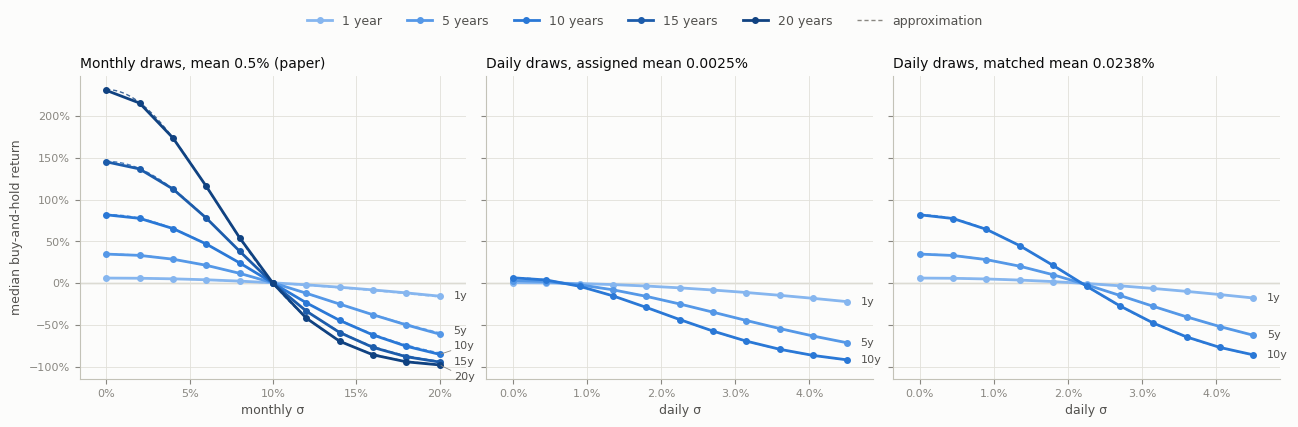

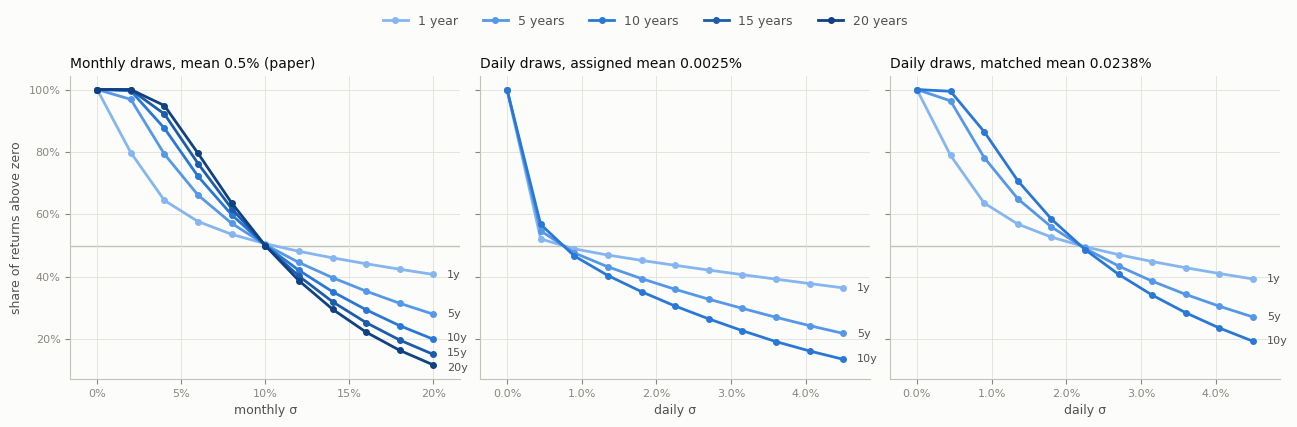

In [19]:
import matplotlib.pyplot as plt
from matplotlib.transforms import offset_copy
from matplotlib.ticker import PercentFormatter

INK, INK_2, MUTED, GRID, BASE, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
# Ordinal blue ramp (validated light to dark): one step per horizon, the same step in every panel.
HORIZON_COLORS = {1: "#86b6ef", 5: "#5598e7", 10: "#2a78d6", 15: "#1c5cab", 20: "#104281"}

experiments = [
    ("Monthly draws, mean 0.5% (paper)", combined, MONTHLY_MU, 12, "monthly σ"),
    ("Daily draws, assigned mean 0.0025%", daily[daily["seed"] == 0], ASSIGNED_MU, 252, "daily σ"),
    ("Daily draws, matched mean 0.0238%", seed0(matched), MATCHED_MU, 252, "daily σ"),
]


def spread(values, gap, iterations=500):
    # Push sorted label positions apart until neighbours are at least `gap` apart, keeping their centre.
    order = np.argsort(values)
    pos = np.asarray(values, dtype=float)[order]
    for _ in range(iterations):
        overlaps = gap - np.diff(pos)
        if (overlaps <= 1e-12).all():
            break
        for i in np.flatnonzero(overlaps > 1e-12):
            pos[i] -= overlaps[i] / 2
            pos[i + 1] += overlaps[i] / 2
    out = np.empty_like(pos)
    out[order] = pos
    return out


def label_line_ends(fig, ax, ends, gap_points=11):
    # Direct-label each line at its last point; labels that would collide are spread apart with a leader.
    height = ax.get_position().height * fig.get_figheight() * 72
    low, high = ax.get_ylim()
    gap = gap_points * (high - low) / height
    placed = spread([y for _, y, _ in ends], gap)
    text_at = offset_copy(ax.transData, fig=fig, x=10, units="points")
    for (x, y, text), label_y in zip(ends, placed):
        leader = dict(arrowstyle="-", color=MUTED, linewidth=0.6, shrinkA=0, shrinkB=1) \
            if abs(label_y - y) > gap / 4 else None
        ax.annotate(text, xy=(x, y), xytext=(x, label_y), textcoords=text_at, va="center",
                    fontsize=8, color=INK_2, arrowprops=leader)


def horizon_figure(stat, ylabel, reference, approximation, path):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True, facecolor=SURFACE)
    line_ends = []
    for ax, (title, frame, mu, per_year, xlabel) in zip(axes, experiments):
        ax.set_facecolor(SURFACE)
        ax.axhline(reference, color=BASE, linewidth=1, zorder=1)
        ends = []
        for years, group in frame.groupby("horizon_years"):
            group = group.sort_values("sigma")
            color = HORIZON_COLORS[int(round(years))]
            ax.plot(group["sigma"], group[stat], color=color, linewidth=2, marker="o", markersize=4,
                    zorder=3, label=f"{years:.0f} year" + ("" if round(years) == 1 else "s"))
            if approximation:
                grid = np.linspace(0, group["sigma"].max(), 100)
                periods = years * per_year
                ax.plot(grid, np.exp(periods * (mu - grid**2 / 2)) - 1, color=color, linewidth=1,
                        linestyle=(0, (3, 2)), alpha=0.8, zorder=2)
            last = group.iloc[-1]
            ends.append((last["sigma"], last[stat], f"{years:.0f}y"))
        line_ends.append((ax, ends))
        ax.set_title(title, fontsize=10, color=INK, loc="left")
        ax.set_xlabel(xlabel, color=INK_2, fontsize=9)
        ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=1 if per_year == 252 else 0))
        ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
        ax.grid(True, color=GRID, linewidth=0.6)
        ax.tick_params(colors=MUTED, labelsize=8)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        for side in ("left", "bottom"):
            ax.spines[side].set_color(BASE)
        ax.margins(x=0.08)
    axes[0].set_ylabel(ylabel, color=INK_2, fontsize=9)
    handles, labels = axes[0].get_legend_handles_labels()
    if approximation:
        handles.append(plt.Line2D([], [], color=MUTED, linewidth=1, linestyle=(0, (3, 2))))
        labels.append("approximation")
    fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, 1.02), labelcolor=INK_2)
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    for ax, ends in line_ends:
        label_line_ends(fig, ax, ends)
    fig.savefig(path, dpi=150, facecolor=SURFACE)
    plt.show()


horizon_figure("median", "median buy-and-hold return", 0.0, True, OUTPUT / "fig_median_vs_sigma.png")
horizon_figure("pct_positive", "share of returns above zero", 0.5, False, OUTPUT / "fig_pct_positive_vs_sigma.png")

In [20]:
monthly0 = seed0(combined)
threshold = np.sqrt(2 * ASSIGNED_MU)

by_sigma = monthly0.pivot(index="sigma", columns="horizon_years", values="median")
rising = [s for s in by_sigma.index if s > 0 and by_sigma.loc[s].is_monotonic_increasing]
falling = [s for s in by_sigma.index if s > 0 and by_sigma.loc[s].is_monotonic_decreasing]
at20 = monthly0[monthly0["horizon_years"] == 20].set_index("sigma")
boundary20 = extension[(extension["sigma"] == 0.1) & (extension["horizon_years"] == 20)]
mean20 = (1 + MONTHLY_MU) ** 240 - 1
peaks = extension.loc[extension.groupby(["seed", "horizon_years"])["p99"].idxmax()]
peak_range = peaks.groupby("horizon_years")["sigma"].agg(["min", "max"])
peak_text = " and ".join(f"{r['min']:.0%} for {years_text(h)}" if r["min"] == r["max"]
                        else f"{r['min']:.0%}–{r['max']:.0%} for {years_text(h)}" for h, r in peak_range.iterrows())
peak_agree = bool((peak_range["min"] == peak_range["max"]).all())
p99_by_horizon_20 = monthly0[monthly0["sigma"] == 0.2].sort_values("horizon_years")["p99"]
p99_grid = monthly0[monthly0["sigma"] > 0].pivot(index="sigma", columns="horizon_years", values="p99")
p99_grows = all(p99_grid.loc[s].is_monotonic_increasing for s in p99_grid.index)
ext_warn = extension_skew[extension_skew["sigma"] > 0]
n_warned = int((ext_warn["warning"] == "warning triggered").sum())
top_exact = ext_warn.loc[ext_warn["exact_skew"].idxmax()]


def pcts(sigmas, digits=0):
    return ", ".join(f"{s:.{digits}%}" for s in sigmas)


display(Markdown(rf'''
**The assigned daily mean.** With a mean of 0.0025% a day, the approximate typical log growth $\mu - \sigma^2/2$ turns negative once $\sigma$ exceeds about $\sqrt{{2\mu}}$ = {threshold:.2%} a day. This is a small-return approximation, not an exact property of the model: under the literal normal model a gross return can be negative, so $E[\log(1+r)]$ is not defined, although the approximation is good intuition where gross returns are positive with very high probability. The simulated median is negative for {crossing_text(median_cross)}, and the share of positive returns is below one half for {crossing_text(positive_cross)}, consistent with the approximation on this grid. In the paper's monthly setup the median stays positive up to about 10% monthly volatility. The difference comes from the mean, not from daily compounding: the assigned mean is about a tenth of the paper's 0.5% a month, so volatility drag pulls the typical outcome below zero at far lower volatility.

**Daily versus monthly compounding.** Sampling frequency is not what drives Table 1. At the matched mean the daily table is close to the paper's, and the gap splits into three parts (Step 3). {"The volatility-grid effect lowers the median in every cell and every seed: the daily grid implies slightly more volatility than the paper's columns. " if grid_consistent else ""}In five-seed means (percentage points), the daily/monthly model effect on the median is, at 1 year: {range_sign("model", "median", 1.0)}; at 10 years: {range_sign("model", "median", 10.0)}. On the 10-year 99th percentile it is {range_sign("model", "p99", 10.0)}. These are Monte Carlo estimates of a model difference. Agreement across five seeds indicates sign consistency in these runs, not an established population sign or a calibrated significance test. The paper replication residual is unexplained and consistent with Monte Carlo variability and rounding; undocumented implementation differences cannot be ruled out. Whatever the sampling frequency, at a fixed mean the median and the share of positive returns fall as volatility rises.

**What 15 and 20 years add.** The population expected 20-year return is {mean20:.1%} at every volatility; the simulated means differ from it, sharply so at high volatility (Step 4). Seed 0's median rises with horizon at $\sigma$ = {pcts(rising)}, where the approximate typical log growth is positive, and falls with horizon at $\sigma$ = {pcts(falling)}, where it is negative. At $\sigma$ = 10% the approximation puts typical log growth near zero, and the simulation does not resolve the sign: across the five seeds the 20-year median ranges from {boundary20["median"].min():.3%} to {boundary20["median"].max():.3%}, and the share of positive outcomes from {boundary20["pct_positive"].min():.3%} to {boundary20["pct_positive"].max():.3%}. At $\sigma$ = 20%, the 20-year median is {at20.loc[0.2, "median"]:.1%} and only {at20.loc[0.2, "pct_positive"]:.1%} of outcomes are positive, yet the population expected return is still {mean20:.1%}, so the expectation rests on a small minority of very large outcomes. The 99th percentile {"grows with horizon at every volatility" if p99_grows else "mostly grows with horizon"} (at 20%: {", ".join(f"{v:.0%}" for v in p99_by_horizon_20)} from 1 to 20 years, seed 0). Across volatilities, on this grid, it peaks at $\sigma$ = {peak_text}{", in all five seeds" if peak_agree else ""}, and falls beyond that while the population expected return stays the same. That is a feature of the specified grid, not an optimum over continuous volatility.

**Skewness.** At 15 and 20 years the population skewness reaches {top_exact["exact_skew"]:,.0f} ({years_text(top_exact["horizon_years"])}, $\sigma$ = {top_exact["sigma"]:.0%}), against a sample-skewness bound of about {top_exact["skew_bound"]:.0f}; {n_warned} of {len(ext_warn)} positive-volatility cells trigger a warning. At these horizons the simulated skewness says only that the distribution is very right-skewed; the population values are the reliable measure.

**Compared with Table 1.** The replication reproduces the paper's pattern at every horizon: the same population expected return at every volatility, a median and a share of positive returns that fall as volatility rises, and a right tail that stretches with horizon. The daily and longer-horizon extensions strengthen that pattern rather than change it.
'''))


**The assigned daily mean.** With a mean of 0.0025% a day, the approximate typical log growth $\mu - \sigma^2/2$ turns negative once $\sigma$ exceeds about $\sqrt{2\mu}$ = 0.71% a day. This is a small-return approximation, not an exact property of the model: under the literal normal model a gross return can be negative, so $E[\log(1+r)]$ is not defined, although the approximation is good intuition where gross returns are positive with very high probability. The simulated median is negative for every daily $\sigma$ from 0.90% up, at all three horizons, and the share of positive returns is below one half for every daily $\sigma$ from 0.90% up, at all three horizons, consistent with the approximation on this grid. In the paper's monthly setup the median stays positive up to about 10% monthly volatility. The difference comes from the mean, not from daily compounding: the assigned mean is about a tenth of the paper's 0.5% a month, so volatility drag pulls the typical outcome below zero at far lower volatility.

**Daily versus monthly compounding.** Sampling frequency is not what drives Table 1. At the matched mean the daily table is close to the paper's, and the gap splits into three parts (Step 3). The volatility-grid effect lowers the median in every cell and every seed: the daily grid implies slightly more volatility than the paper's columns. In five-seed means (percentage points), the daily/monthly model effect on the median is, at 1 year: −0.56 to −0.02, negative in every cell and all five seeds; at 10 years: −0.19 to +2.80, positive in all five seeds in 5 of 10 cells. On the 10-year 99th percentile it is −64.49 to +1.22, without a sign shared by all five seeds in any cell. These are Monte Carlo estimates of a model difference. Agreement across five seeds indicates sign consistency in these runs, not an established population sign or a calibrated significance test. The paper replication residual is unexplained and consistent with Monte Carlo variability and rounding; undocumented implementation differences cannot be ruled out. Whatever the sampling frequency, at a fixed mean the median and the share of positive returns fall as volatility rises.

**What 15 and 20 years add.** The population expected 20-year return is 231.0% at every volatility; the simulated means differ from it, sharply so at high volatility (Step 4). Seed 0's median rises with horizon at $\sigma$ = 2%, 4%, 6%, 8%, where the approximate typical log growth is positive, and falls with horizon at $\sigma$ = 12%, 14%, 16%, 18%, 20%, where it is negative. At $\sigma$ = 10% the approximation puts typical log growth near zero, and the simulation does not resolve the sign: across the five seeds the 20-year median ranges from -0.531% to 0.123%, and the share of positive outcomes from 49.858% to 50.032%. At $\sigma$ = 20%, the 20-year median is -97.9% and only 11.7% of outcomes are positive, yet the population expected return is still 231.0%, so the expectation rests on a small minority of very large outcomes. The 99th percentile grows with horizon at every volatility (at 20%: 305%, 1423%, 2773%, 3398%, 3613% from 1 to 20 years, seed 0). Across volatilities, on this grid, it peaks at $\sigma$ = 18% for 15 years and 16% for 20 years, in all five seeds, and falls beyond that while the population expected return stays the same. That is a feature of the specified grid, not an optimum over continuous volatility.

**Skewness.** At 15 and 20 years the population skewness reaches 425,770 (20 years, $\sigma$ = 20%), against a sample-skewness bound of about 500; 12 of 20 positive-volatility cells trigger a warning. At these horizons the simulated skewness says only that the distribution is very right-skewed; the population values are the reliable measure.

**Compared with Table 1.** The replication reproduces the paper's pattern at every horizon: the same population expected return at every volatility, a median and a share of positive returns that fall as volatility rises, and a right tail that stretches with horizon. The daily and longer-horizon extensions strengthen that pattern rather than change it.


### Step 6: Can this explain the low-volatility puzzle?

The low-volatility puzzle is the finding that stocks with low volatility or low beta have earned higher risk-adjusted returns than stocks with high volatility or beta, and in many samples no lower raw returns. The evidence uses related but different measures: Ang, Hodrick, Xing and Zhang (2006) sort stocks on idiosyncratic volatility relative to the Fama–French model; Baker, Bradley and Wurgler (2011) study total volatility and beta; Frazzini and Pedersen (2014) study beta and funding constraints. The simulation has none of that structure. Its $\sigma$ is the total volatility of a single asset, with no market factor, no beta and no correlation between assets. The numbers below come from Steps 2 and 4 (seed 0, monthly mean 0.5%).

In [21]:
low, high = 0.04, 0.16
cells = monthly0.set_index(["horizon_years", "sigma"])
rows = []
for years in (10, 20):
    for s in (low, high):
        rows.append({"horizon (years)": years, "monthly sigma": s,
                     "population expected return": (1 + MONTHLY_MU) ** (12 * years) - 1,
                     "median": cells.loc[(years, s), "median"],
                     "share positive": cells.loc[(years, s), "pct_positive"],
                     "99th percentile": cells.loc[(years, s), "p99"]})
illustration = pd.DataFrame(rows)
display(illustration.style.hide(axis="index").format({
    "monthly sigma": "{:.0%}", "population expected return": "{:.1%}", "median": "{:.1%}",
    "share positive": "{:.1%}", "99th percentile": "{:.0%}"}))
low10, high10 = illustration.iloc[0], illustration.iloc[1]
display(Markdown(rf'''
Both volatilities have the same monthly expected return, so the same population expected 10-year return ({low10["population expected return"]:.1%}). Yet the median 10-year return is {low10["median"]:.1%} at {low:.0%} monthly volatility and {high10["median"]:.1%} at {high:.0%}, and the share of positive outcomes falls from {low10["share positive"]:.1%} to {high10["share positive"]:.1%}.
'''))

horizon (years),monthly sigma,population expected return,median,share positive,99th percentile
10,4%,81.9%,65.5%,87.6%,359%
10,16%,81.9%,-62.0%,29.4%,2315%
20,4%,231.0%,174.0%,94.9%,1046%
20,16%,231.0%,-85.8%,22.2%,4887%



Both volatilities have the same monthly expected return, so the same population expected 10-year return (81.9%). Yet the median 10-year return is 65.5% at 4% monthly volatility and -62.0% at 16%, and the share of positive outcomes falls from 87.6% to 29.4%.


**What compounding does explain.** At the same arithmetic expected return, a higher-volatility asset has a lower median buy-and-hold return and a lower chance of ending above zero, and the gap widens with horizon (table above). Volatility drag, roughly $\sigma^2/2$ per period in typical log growth, pulls the median down, while a small minority of very large outcomes keeps the expected return unchanged. So when the puzzle is stated in terms of typical long-horizon outcomes of individual high-volatility assets, such as their median buy-and-hold return or how often they end with a gain, compounding produces a related difference without any difference in expected returns. The notebook compares marginal distributions only: it does not estimate how often a high-volatility asset ends behind a low-volatility one or behind a market benchmark, which would need an explicitly specified joint experiment. Likewise, cumulative-wealth charts of low- versus high-volatility portfolios measure realized compounded performance; volatility drag enters them too, so differences in such charts cannot by themselves identify differences in arithmetic expected returns.

**What it does not explain.** The anomaly in the literature is measured with average (arithmetic) returns and alphas of portfolios, usually rebalanced monthly. In this simulation arithmetic expected returns are equal by construction, so it cannot produce the lower average returns or negative alphas of high-volatility stocks, and a lower median is not a lower expected return. Having no factor structure, it also cannot speak to idiosyncratic volatility or beta as such. In rebalanced portfolios, diversification removes much of the idiosyncratic variance and with it much of the drag, although drag from common-factor volatility remains.

**Possible mechanisms, not results of the simulation.** Two explanations from the literature work through different channels. *Lottery preferences:* investors who like positively skewed payoffs may bid up high-volatility, lottery-like stocks and accept lower expected returns (Barberis and Huang 2008; Bali, Cakici and Whitelaw 2011). The simulation shows that compounding makes long-horizon returns strongly right-skewed (Panel A), the kind of skewness this channel involves, but not that investors price it. *Leverage constraints:* investors who cannot borrow tilt toward high-beta assets to raise expected returns, flattening the security market line (Frazzini and Pedersen 2014). That channel works through beta and funding constraints and does not depend on the compounded skewness shown here. The simulation cannot tell whether either mechanism operates.

**Conclusion.** Compounding explains a related difference in typical long-horizon outcomes: at equal expected returns, higher volatility means a lower median buy-and-hold return and a lower chance of a gain. This experiment does not explain the empirical arithmetic-return or risk-adjusted-return anomaly itself.

**References.** Ang, A., R. Hodrick, Y. Xing and X. Zhang (2006), "The Cross-Section of Volatility and Expected Returns," *Journal of Finance* ([NBER working paper](https://www.nber.org/papers/w10852)). Baker, M., B. Bradley and J. Wurgler (2011), "Benchmarks as Limits to Arbitrage: Understanding the Low-Volatility Anomaly," *Financial Analysts Journal*. Bali, T., N. Cakici and R. Whitelaw (2011), "Maxing Out: Stocks as Lotteries and the Cross-Section of Expected Returns," *Journal of Financial Economics*. Barberis, N. and M. Huang (2008), "Stocks as Lotteries: The Implications of Probability Weighting for Security Prices," *American Economic Review*. Frazzini, A. and L. Pedersen (2014), "Betting Against Beta," *Journal of Financial Economics* ([NBER working paper](https://www.nber.org/papers/w16601)).

## Part 2: Table 4 with industries

### Step 7: Load and audit the industry data

Part 2 replaces the paper's randomly drawn stocks with Ken French's industry portfolios: FF49 is the main universe and FF12 a robustness check. Equal-weighted returns are required and value-weighted returns are the bonus. The benchmarks come from French's factor file: the T-bill return is RF, and the value-weighted market return is (Mkt−RF) + RF. The files are the August 2026 CRSP release, cached in `data/raw/`; the exact ZIP checksums and release identifiers are in [data/vintage.json](data/vintage.json). The audit and caveats are documented below. These are revised CRSP CIZ data, so differences from the paper can reflect its earlier data vintage and construction as well as the use of industries instead of individual stocks.

The parser finds each table by its title and header, not by line number. It requires consecutive months that are identical across tables and files, converts percent returns to decimals, and treats the codes −99.99 and −999 as missing.

**Which industries can be selected (a reconstruction assumption).** French assigns stocks to industries at the end of June. We assume that a positive firm count in July means the industry had members at that June's formation, and treat it as eligible for the whole July–June year. The data are consistent with this but do not prove it. It is a reconstruction from revised data, not a record of what an investor knew at the time. Eligibility never depends on whether a return exists.

The audit checks the facts the analysis relies on for this release. Any failure stops the notebook before anything is exported.

In [22]:
# Part 2 setup: uses only OUTPUT and REFRESH from Part 1.
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

if str(Path("src").resolve()) not in sys.path:
    sys.path.insert(0, str(Path("src").resolve()))
from ff_audit import RELEASE, require_audit, snapshot_audit
from ff_data import formation_eligibility, load_all, verify_cache

FF_PATHS = verify_cache()
industries, factors = load_all(FF_PATHS)
eligible = {key: formation_eligibility(data.firms) for key, data in industries.items()}

audit = require_audit(snapshot_audit(FF_PATHS, industries, factors))
audit.to_csv(OUTPUT / "table4_data_audit.csv", index=False)
display(audit.style.hide(axis="index").set_caption("Data audit, August 2026 release")
        .format({"ok": lambda ok: "pass" if ok else "FAIL"})
        .set_properties(subset=["fact", "observed"], **{"text-align": "left"}))

file,fact,observed,ok
all,CRSP release 202608 in every file header,"202608, 202608, 202608",pass
all,"Months: Jul 1926 to Aug 2026 (1,202), identical in all files","Jul 1926 to Aug 2026 (1,202)",pass
factors,"Compounded T-bill return, Jul 1926 to Dec 2016 (1,086 months): 19.2797",19.2797,pass
factors,"Compounded VW market return, same months: 5031.7488",5031.7488,pass
ff49,"Missing-data codes: only −99.99 occurs, never −999","−99.99: 5,736; −999: 0",pass
ff49,EW and VW are missing in the same industry-months,0 mismatches,pass
ff49,Returns are missing exactly where the firm count is zero,0 mismatches,pass
ff49,"Firm counts rise only in July, and fall to zero only in July",0 rises and 0 falls to zero outside July,pass
ff49,Every eligible industry-month has EW and VW returns (formation rule),0 eligible industry-months without a return,pass
ff49,Industries with firms in Jul 1926: 40,40,pass


#### The FF49 universe by formation year

Each row is a July in which the number of eligible FF49 industries changes; the count then holds until the next row. A random selection in Step 9 draws uniformly from this set each month.

In [23]:
def month_name(period):
    return period.strftime("%b %Y")


changes = []
previous = pd.Series(False, index=eligible["ff49"].columns)
for month, current in eligible["ff49"].iterrows():
    if month.month == 7 and not current.equals(previous):
        changes.append({"formation July": month_name(month), "eligible industries": int(current.sum()),
                        "added": ", ".join(current.index[current & ~previous]),
                        "removed": ", ".join(current.index[previous & ~current])})
    previous = current
display(pd.DataFrame(changes).style.hide(axis="index").set_properties(subset=["added", "removed"],
                                                                   **{"text-align": "left"}))

formation July,eligible industries,added,removed
Jul 1926,40,"Agric, Food, Beer, Smoke, Toys, Fun, Books, Hshld, Clths, MedEq, Drugs, Chems, Txtls, BldMt, Cnstr, Steel, Mach, ElcEq, Autos, Aero, Ships, Mines, Coal, Oil, Util, Telcm, BusSv, Hardw, Chips, LabEq, Boxes, Trans, Whlsl, Rtail, Meals, Banks, Insur, RlEst, Fin, Other",
Jul 1927,41,PerSv,
Jul 1929,42,Paper,
Jul 1930,43,Rubbr,
Jul 1943,42,,Rubbr
Jul 1944,43,Rubbr,
Jul 1963,47,"Soda, FabPr, Guns, Gold",
Jul 1965,48,Softw,
Jul 1969,49,Hlth,


#### Step 7 findings

Generated from the data above.

In [24]:
ff49, ff12 = industries["ff49"], industries["ff12"]
sample = factors.loc["1926-07":"2016-12"]
tbill, market = (1 + sample["rf"]).prod() - 1, (1 + sample["mkt"]).prod() - 1

count49 = eligible["ff49"].sum(axis=1)
full_from = count49.index[np.argmax(count49.to_numpy() == ff49.firms.shape[1])]
first_year = eligible["ff49"].loc["1926-07":"1927-06"]
seen = eligible["ff49"].cumsum() > 0
dropped = seen & ~eligible["ff49"]
dropped_text = "; ".join(f"{name} from {month_name(dropped.index[dropped[name]][0])} to "
                         f"{month_name(dropped.index[dropped[name]][-1])}"
                         for name in dropped.columns[dropped.any()])

missing_ew, missing_vw = ff49.ew.isna().to_numpy(), ff49.vw.isna().to_numpy()
missing_at_zero = bool((missing_ew == (ff49.firms.to_numpy() == 0)).all())
missing_eligible = int((missing_ew & eligible["ff49"].to_numpy()).sum() + (missing_vw & eligible["ff49"].to_numpy()).sum())
missing12 = int(ff12.ew.isna().to_numpy().sum() + ff12.vw.isna().to_numpy().sum())

single = ff49.firms == 1
in_sample = single.index <= pd.Period("2016-12", "M")
single_eligible = (single & eligible["ff49"]).to_numpy()[in_sample]
share_single = single_eligible.sum() / eligible["ff49"].to_numpy()[in_sample].sum()
single_first = int((single.loc["1926-07"] & eligible["ff49"].loc["1926-07"]).sum())
last_single = single.index[np.flatnonzero(single.any(axis=1).to_numpy())[-1]]
max_gap = np.nanmax((ff49.ew - ff49.vw).abs().to_numpy()[single.to_numpy()])

if not (missing_at_zero and missing_eligible == 0 and (missing_ew == missing_vw).all()):
    raise ValueError("the missing-return pattern changed; revise the findings")

display(Markdown(rf'''
- **Coverage.** All three files come from the {RELEASE} CRSP release and cover {month_name(factors.index[0])} to {month_name(factors.index[-1])} ({len(factors):,} months). The Table 4 comparison uses Jul 1926 to Dec 2016 ({len(sample):,} months).
- **Eligible industries.** FF49 has {int(count49.iloc[0])} eligible industries in the first formation year (Jul 1926 to Jun 1927) and all {ff49.firms.shape[1]} from {month_name(full_from)}. Industries that drop out after their first appearance: {dropped_text or "none"}. FF12 has all {ff12.firms.shape[1]} industries in every month.
- **Missing returns.** FF49 has {int(missing_ew.sum()):,} industry-months without an EW return, the same months lack a VW return, and all of them have a zero firm count. None is an eligible industry-month, so under the formation rule a selected industry always has a holding-month return; the strategies still stop if one does not. FF12 has {missing12} missing returns.
- **Industries that are single firms.** {int(single.to_numpy().sum()):,} FF49 industry-months have one firm: {share_single:.1%} of eligible industry-months in the Table 4 sample, and {single_first} of the {int(count49.iloc[0])} eligible industries in Jul 1926. There a random industry is a random stock, and EW equals VW up to the files' rounding (largest gap {100 * max_gap:.2f} percentage points). The last such month is {month_name(last_single)}.
- **Benchmarks.** Over the Table 4 sample the compounded T-bill return is {tbill:,.2%}; the paper reports 1,928%. This is an aggregate consistency check at the paper's rounding, not a month-by-month match. The compounded VW market return is {market:,.2%}.
'''))


- **Coverage.** All three files come from the 202608 CRSP release and cover Jul 1926 to Aug 2026 (1,202 months). The Table 4 comparison uses Jul 1926 to Dec 2016 (1,086 months).
- **Eligible industries.** FF49 has 40 eligible industries in the first formation year (Jul 1926 to Jun 1927) and all 49 from Jul 1969. Industries that drop out after their first appearance: Rubbr from Jul 1943 to Jun 1944. FF12 has all 12 industries in every month.
- **Missing returns.** FF49 has 2,868 industry-months without an EW return, the same months lack a VW return, and all of them have a zero firm count. None is an eligible industry-month, so under the formation rule a selected industry always has a holding-month return; the strategies still stop if one does not. FF12 has 0 missing returns.
- **Industries that are single firms.** 782 FF49 industry-months have one firm: 1.6% of eligible industry-months in the Table 4 sample, and 5 of the 40 eligible industries in Jul 1926. There a random industry is a random stock, and EW equals VW up to the files' rounding (largest gap 0.01 percentage points). The last such month is Jun 1973.
- **Benchmarks.** Over the Table 4 sample the compounded T-bill return is 1,927.97%; the paper reports 1,928%. This is an aggregate consistency check at the paper's rounding, not a month-by-month match. The compounded VW market return is 503,174.88%.


### Step 8: Common evaluator and exact benchmark

Every strategy in Steps 9–11 is scored by one evaluator, [src/table4_eval.py](src/table4_eval.py). A strategy is a table of monthly returns, with one column for a deterministic rule or 20,000 columns for a random one.

- **Windows.** Calendar years 1927–2016 (the partial 1926 is dropped, an implementation choice), the paper's decades (July 1926 to December 1936, then 1937–1946, …, 2007–2016), the full period, and rolling 120-month windows as a secondary view.
- **Holding returns.** Wealth starts at 1 in each window's first month. A path's wealth is the exponential of the difference of two cumulative sums of $\log(1+r)$. The T-bill and VW market are compounded separately over the same months; monthly return differences are never compounded.
- **Statistics.** Mean, median and standardized skewness of the holding return (skewness as in Part 1: $m_3/m_2^{3/2}$ with biased central moments), and the shares of outcomes above zero, the T-bill and the market. The comparisons are strict and made on wealth, so a tie with a benchmark is not a win.
- **Two outputs.** Statistics per window, computed across paths, and a pooled summary over all path × window outcomes, each weighted equally. The pooled summary is what is compared with the paper; this is an implementation choice, since the paper says only that its statistics are "computed across the 20,000 outcomes". Every row states what it is computed across: across paths, across paths and windows, across historical windows (one path, several windows), or a single realization.

**Exact benchmark.** Conditional on the historical returns and the eligible sets $A_t$, drawing one industry uniformly from $A_t$ each month, independently across months, gives over any window

$$E\left[W^k\right]=\prod_{t}\frac{1}{\lvert A_t\rvert}\sum_{i\in A_t}\left(1+r_{i,t}\right)^k,\qquad k=1,\dots,4.$$

For $k=1$ this is the realized wealth of a portfolio rebalanced monthly to equal weights across the eligible industries. The four raw moments give the exact mean, SD and skewness per window, in the normalized form of Part 1's exact moments. Pooled moments follow from the equally weighted mixture of windows. They are population values for the random strategy on the one realized history and involve no simulation.

**Monte Carlo check (used in Step 9).** Numerical validity comes first and is never waived: every simulated mean must be finite, every path count a positive whole number, and every exact mean and SD valid. Otherwise the check stops, however heavy the row's tail. Each row then gets one test:

- **deterministic rows** (exact SD of zero): simulated and exact wealth must agree to a relative $10^{-10}$;
- **z-tested rows**: $z=(\bar W-E[W])\big/\left(\mathrm{SD}_{\text{exact}}/\sqrt{n}\right)$, per window, and for the pooled mean of each kind of non-overlapping window. The standard error is exact under the sampling model, because windows covering different months are independent. A row is z-tested when its kind does not overlap and its exact skewness is below 10, Part 1's screening heuristic;
- **diagnostic-only rows**: rolling windows and heavier-tailed windows. Their $z$ is reported but not enforced.

The $z$ limit is a normal-approximation check with a nominal 0.1% Bonferroni family-wise level per variant (one universe and weighting), with a minimum threshold of 4. The normal approximation is not exact, so the level is nominal, not calibrated error control. The check concerns the mean only; it is not a target for the median, the skewness or the win rates.

In [25]:
from table4_eval import (HORIZONS, eligible_mean_returns, evaluate, exact_random_moments, load_paper_table4,
                         paper_layout, pool_exact, standard_windows, table4_layout, window_wealth)

bench = factors.loc["1926-07":"2016-12"]
windows = standard_windows(bench.index)

SAMPLES = {"Table 4 (Step 9)": ("1926-07", "2016-12"), "Momentum comparison (Step 10)": ("1926-10", "2016-12"),
           "Bonus (Step 11)": ("1927-01", "2026-08")}
window_counts = []
for label, (start, end) in SAMPLES.items():
    sample_windows = standard_windows(factors.loc[start:end].index)
    count = sample_windows.groupby("kind").size()
    window_counts.append({
        "sample": label,
        "months": f"{month_name(pd.Period(start, 'M'))} to {month_name(pd.Period(end, 'M'))}",
        "length (months)": int(sample_windows.loc[sample_windows["kind"] == "full", "n_months"].item()),
        "calendar years": int(count["year"]),
        "decades": int(count["decade"]),
        "first decade (months)": int(sample_windows.loc[sample_windows["kind"] == "decade", "n_months"].iloc[0]),
        "rolling 120-month windows": int(count["rolling120"]),
    })
window_counts = pd.DataFrame(window_counts)
display(window_counts.style.hide(axis="index").format(thousands=",")
        .set_caption("Evaluation windows (the bonus adds its holdout windows in Step 11)"))

sample,months,length (months),calendar years,decades,first decade (months),rolling 120-month windows
Table 4 (Step 9),Jul 1926 to Dec 2016,"1,086",90,9,126,967
Momentum comparison (Step 10),Oct 1926 to Dec 2016,"1,083",90,9,123,964
Bonus (Step 11),Jan 1927 to Aug 2026,"1,196",99,9,120,"1,077"


#### Checks on the real data

Before any simulation, the evaluator is checked where the answer is known exactly:

- the VW market scored against itself must beat itself in no window, because ties are not wins, and likewise for the T-bill;
- cumulative-sum wealth must equal the direct product of gross returns in every window;
- the monthly equal-weight portfolio across eligible industries must realize exactly the exact mean, in every window, for each universe and weighting. This joins the evaluator, the eligibility table and the exact benchmark on real data.

A failure stops the notebook before anything is saved.

In [26]:
market = evaluate(bench["mkt"], bench, windows)
tbill = evaluate(bench["rf"], bench, windows)
direct = np.array([np.prod(1 + bench["mkt"].loc[w.start:w.end].to_numpy()) for w in windows.itertuples()])
cumsum_error = float(np.max(np.abs(window_wealth(bench["mkt"], windows)[:, 0] / direct - 1)))

VARIANTS = [(key, weighting) for key in ("ff49", "ff12") for weighting in ("ew", "vw")]
TOLERANCE = 1e-12
exact, portfolio_error = {}, {}
for key, weighting in VARIANTS:
    returns = getattr(industries[key], weighting).loc[bench.index]
    in_sample = eligible[key].loc[bench.index]
    exact[key, weighting] = exact_random_moments(returns, in_sample, windows)
    realized = evaluate(eligible_mean_returns(returns, in_sample), bench, windows).windows
    # Relative difference of gross wealth, which stays meaningful when a holding return is near zero.
    gap = (1 + realized["mean"]) / (1 + exact[key, weighting]["exact_mean"]) - 1
    portfolio_error[key, weighting] = float(gap.abs().max())

evaluator_checks = pd.DataFrame(
    [{"check": "VW market scored against itself: largest share above the market", "windows": len(windows),
      "observed": f"{market.windows['pct_above_vw'].max():.0%}", "ok": market.windows["pct_above_vw"].max() == 0},
     {"check": "T-bill scored against itself: largest share above the T-bill", "windows": len(windows),
      "observed": f"{tbill.windows['pct_above_tbill'].max():.0%}", "ok": tbill.windows["pct_above_tbill"].max() == 0},
     {"check": "Cumulative-sum wealth vs direct product (VW market): largest relative gap", "windows": len(windows),
      "observed": f"{cumsum_error:.1e}", "ok": cumsum_error <= TOLERANCE}]
    + [{"check": f"{key.upper()} {weighting.upper()}: equal-weight portfolio vs exact mean, largest relative gap",
        "windows": len(windows), "observed": f"{error:.1e}", "ok": error <= TOLERANCE}
       for (key, weighting), error in portfolio_error.items()])
if not evaluator_checks["ok"].all():
    raise ValueError("an evaluator check failed:\n" + evaluator_checks[~evaluator_checks["ok"]].to_string())

exact_windows = pd.concat([frame.assign(universe=key, weighting=weighting) for (key, weighting), frame in exact.items()],
                          ignore_index=True)
exact_pooled = pd.concat([pool_exact(frame).assign(universe=key, weighting=weighting)
                          for (key, weighting), frame in exact.items()], ignore_index=True)
exact_windows.to_csv(OUTPUT / "table4_exact_windows.csv", index=False)
exact_pooled.to_csv(OUTPUT / "table4_exact_pooled.csv", index=False)
display(evaluator_checks.style.hide(axis="index").format({"ok": lambda ok: "pass" if ok else "FAIL", "windows": "{:,}"})
        .set_properties(subset=["check"], **{"text-align": "left"})
        .set_caption(f"Evaluator checks (tolerance {TOLERANCE:.0e})"))

check,windows,observed,ok
VW market scored against itself: largest share above the market,"1,067",0%,pass
T-bill scored against itself: largest share above the T-bill,"1,067",0%,pass
Cumulative-sum wealth vs direct product (VW market): largest relative gap,"1,067",6.1e-15,pass
"FF49 EW: equal-weight portfolio vs exact mean, largest relative gap","1,067",2.2e-16,pass
"FF49 VW: equal-weight portfolio vs exact mean, largest relative gap","1,067",2.2e-16,pass
"FF12 EW: equal-weight portfolio vs exact mean, largest relative gap","1,067",2.2e-16,pass
"FF12 VW: equal-weight portfolio vs exact mean, largest relative gap","1,067",2.2e-16,pass


#### Exact benchmark for random industry selection

Pooled exact moments of the holding return: the average over the 90 calendar years, the 9 decades and the full period. The mean is the equal-weight portfolio's realized return, pooled the same way. SD and skewness are the population values that the Step 9 simulation estimates.

For context, two rows are not exact benchmarks:
- the VW market's statistics across historical windows (the full period is a single realization, so its skewness is unavailable);
- the paper's single-stock bootstrap, whose statistics are across its 20,000 paths.

Means and SDs are holding returns in percent.

In [27]:
rows = {}
for key, weighting in VARIANTS:
    pooled = exact_pooled[(exact_pooled["universe"] == key) & (exact_pooled["weighting"] == weighting)]
    pooled = pooled.set_index("kind").reindex(list(HORIZONS))
    label = f"Random {key.upper()} industry, {weighting.upper()} returns (exact)"
    rows[label, "mean"] = pooled["exact_mean"].to_numpy()
    rows[label, "SD"] = pooled["exact_sd"].to_numpy()
    rows[label, "skewness"] = pooled["exact_skew"].to_numpy()
market_layout = table4_layout(market.pooled)
rows["VW market (across historical windows)", "mean"] = market_layout.loc["mean"].to_numpy()
rows["VW market (across historical windows)", "skewness"] = market_layout.loc["skew"].to_numpy()
paper_single = paper_layout(load_paper_table4(), 1)
rows["Paper: random single stock (across paths)", "mean"] = paper_single.loc["mean"].to_numpy()
rows["Paper: random single stock (across paths)", "skewness"] = paper_single.loc["skew"].to_numpy()

exact_table = pd.DataFrame(rows, index=list(HORIZONS.values())).T
exact_table.index.names = ["", "statistic"]
is_skew = exact_table.index.get_level_values("statistic") == "skewness"
display(exact_table.style.format("{:,.2%}", subset=(exact_table.index[~is_skew], slice(None)), na_rep="n/a")
        .format("{:.2f}", subset=(exact_table.index[is_skew], slice(None)), na_rep="n/a")
        .set_caption("Pooled exact moments of random industry selection, Jul 1926 to Dec 2016"))

#### Step 8 findings

Generated from the results above.

In [28]:
N_PATHS_STEP9 = 20_000
skew_bound = (N_PATHS_STEP9 - 2) / np.sqrt(N_PATHS_STEP9 - 1)
table4_counts = window_counts.set_index("sample").iloc[0]
largest_gap = max(portfolio_error.values())
full = exact_pooled[exact_pooled["kind"] == "full"].set_index(["universe", "weighting"])
market_full = market.pooled.set_index("kind").loc["full", "mean"]
tbill_full = tbill.pooled.set_index("kind").loc["full", "mean"]


def variant(key, weighting):
    return f"{key.upper()} {weighting.upper()}"


def and_join(items):
    items = list(items)
    return " and ".join([", ".join(items[:-1]), items[-1]]) if len(items) > 1 else "".join(items)


ratios = {v: (1 + full.loc[v, "exact_mean"]) / (1 + market_full) for v in VARIANTS}
above = [v for v, ratio in ratios.items() if ratio > 1]
ratio_text = "; ".join(f"{variant(*v)} {full.loc[v, 'exact_mean']:,.0%} ({ratios[v]:.1f} times the market's wealth)"
                       for v in VARIANTS)
above_text = ("all four exceed" if len(above) == len(VARIANTS) else
              f"{', '.join(variant(*v) for v in above) or 'none'} exceed")

# Tested vs diagnostic windows in Step 9's mean check (exact skewness below 10 in non-overlapping windows).
heavy = exact_windows[exact_windows["kind"].isin(HORIZONS) & (exact_windows["exact_skew"] >= 10)]
n_deterministic = int((exact_windows["exact_sd"] == 0).sum())
deterministic_text = ("No window is deterministic: every exact SD is positive." if n_deterministic == 0 else
                      f"{n_deterministic} windows are deterministic (exact SD of zero) and are compared exactly.")
heavy_text = "; ".join(f"{variant(k, w)}: {', '.join(sorted(set(g['kind'])))} ({len(g)})"
                       for (k, w), g in heavy.groupby(["universe", "weighting"])) or "none"
warn = full[full["exact_skew"] >= 0.1 * skew_bound]
warn_text = and_join(f"{variant(*v)} ({full.loc[v, 'exact_skew']:.0f})" for v in warn.index) or "none"
paper_mean = paper_single.loc["mean", "full period"]
paper_above_vw = paper_single.loc["pct_above_vw", "full period"]
if not paper_mean > market_full:
    raise ValueError("the paper comparison below assumes its single-stock mean exceeds the market's return")

display(Markdown(rf'''
- **Windows.** The Table 4 sample has {table4_counts['calendar years']} calendar years, {table4_counts['decades']} decades (the first {table4_counts['first decade (months)']} months), one full period of {table4_counts['length (months)']:,} months and {table4_counts['rolling 120-month windows']:,} rolling 120-month windows. Starting in October 1926 shortens the first decade to {window_counts.loc[1, 'first decade (months)']} months, and starting in January 1927 to {window_counts.loc[2, 'first decade (months)']}.
- **Evaluator checks.** All {len(evaluator_checks)} pass. The market and the T-bill never beat themselves. Cumulative-sum wealth matches direct products to {cumsum_error:.0e}, and the equal-weight portfolio matches the exact mean to {largest_gap:.0e} in every window, universe and weighting.
- **Expected full-period return.** The exact mean of random industry selection over the full period is: {ratio_text}. The VW market returned {market_full:,.0%} and T-bills {tbill_full:,.0%}; {above_text} the market. Under uniform random selection, the expected holding return is the return of a monthly-rebalanced equal-weight portfolio, so a mean above the market reflects equal weighting across industries (and, with EW returns, within them). It does not show that a typical path beats the market. The same identity applies to the expectation of the paper's single-stock experiment. Its reported mean ({paper_mean:,.0%}) is a Monte Carlo estimate of that expectation, from the paper's own CRSP data, and it is above the VW market's return in French's current data (a comparison across data vintages). Only {paper_above_vw:.2%} of the paper's paths beat its own VW market benchmark.
- **Skewness.** Exact full-period skewness is {', '.join(f"{variant(*v)} {full.loc[v, 'exact_skew']:.1f}" for v in VARIANTS)}. With {N_PATHS_STEP9:,} paths, sample skewness cannot exceed {skew_bound:.1f}. Part 1's warning rule (exact skewness at least 10% of that bound) flags the full period for {warn_text}, so Step 9's sample skewness there should be read as a heavy-tail estimate, not a population value.
- **Step 9 mean check.** Windows with exact skewness of at least 10, which the check treats as diagnostic only: {heavy_text}. All other calendar-year and decade windows, and their pooled means, are z-tested. {deterministic_text}
'''))


- **Windows.** The Table 4 sample has 90 calendar years, 9 decades (the first 126 months), one full period of 1,086 months and 967 rolling 120-month windows. Starting in October 1926 shortens the first decade to 123 months, and starting in January 1927 to 120.
- **Evaluator checks.** All 7 pass. The market and the T-bill never beat themselves. Cumulative-sum wealth matches direct products to 6e-15, and the equal-weight portfolio matches the exact mean to 2e-16 in every window, universe and weighting.
- **Expected full-period return.** The exact mean of random industry selection over the full period is: FF49 EW 7,368,233% (14.6 times the market's wealth); FF49 VW 1,181,331% (2.3 times the market's wealth); FF12 EW 6,772,886% (13.5 times the market's wealth); FF12 VW 992,682% (2.0 times the market's wealth). The VW market returned 503,175% and T-bills 1,928%; all four exceed the market. Under uniform random selection, the expected holding return is the return of a monthly-rebalanced equal-weight portfolio, so a mean above the market reflects equal weighting across industries (and, with EW returns, within them). It does not show that a typical path beats the market. The same identity applies to the expectation of the paper's single-stock experiment. Its reported mean (949,826%) is a Monte Carlo estimate of that expectation, from the paper's own CRSP data, and it is above the VW market's return in French's current data (a comparison across data vintages). Only 3.97% of the paper's paths beat its own VW market benchmark.
- **Skewness.** Exact full-period skewness is FF49 EW 80.3, FF49 VW 78.6, FF12 EW 6.8, FF12 VW 6.5. With 20,000 paths, sample skewness cannot exceed 141.4. Part 1's warning rule (exact skewness at least 10% of that bound) flags the full period for FF49 EW (80) and FF49 VW (79), so Step 9's sample skewness there should be read as a heavy-tail estimate, not a population value.
- **Step 9 mean check.** Windows with exact skewness of at least 10, which the check treats as diagnostic only: FF49 EW: full (1); FF49 VW: full (1). All other calendar-year and decade windows, and their pooled means, are z-tested. No window is deterministic: every exact SD is positive.


### Step 9: Task 2.1, random industry selection

Each month, one industry is drawn uniformly from that month's eligible set (Step 7's formation rule), held for the month, and drawn again the next month, independently across months. This is the paper's single-stock bootstrap with an industry portfolio in place of a stock.

- **Run.** 20,000 paths, seed 0, July 1926 to December 2016, for FF49 (main) and FF12 (robustness). The draws are generated once per universe, as an explicit array of industry positions, and applied to both equal-weighted returns (Task 2.1) and value-weighted returns (the bonus). EW and VW therefore differ only in how stocks are weighted within the selected industry. Step 10 reuses these paths from October 1926.
- **Checks before export.** No ineligible industry is ever selected and no selected return is missing. Each industry is selected as often as uniform selection implies: a $z$ per industry, with a nominal 0.1% Bonferroni level and a minimum of 4. Finally, Step 8's mean check against the exact benchmark runs for each universe and weighting. Any failure stops the notebook before anything is saved.
- **Comparison with the paper.** Pooled statistics, across paths and windows, are laid out like Table 4, next to the paper's rows. The paper's portfolios are value-weighted, so FF49 VW is the closest analogue in weighting to its N-stock portfolios. FF49 EW, with equal-weighted stocks within the industry, is the assigned task.

All results are before transaction costs and conditional on the one realized history of industry returns.

In [29]:
import json

from table4_eval import (SHARES, STAT_LABELS, STATS, enforce_mean_check, full_period, mean_check,
                         share_standard_errors)
from table4_strategies import (random_selections, require_uniform_selections, selected_returns,
                               selection_fingerprint, selection_frequency_check)

N_PATHS, SEED = 20_000, 0
full_window = full_period(bench.index)

selections, selection_rows = {}, []
for key in ("ff49", "ff12"):
    in_sample = eligible[key].loc[bench.index]
    selections[key] = random_selections(in_sample, N_PATHS, SEED)
    frequencies = require_uniform_selections(selection_frequency_check(selections[key], in_sample))
    selection_rows.append({"universe": key.upper(), "draws": selections[key].size, "industries": len(frequencies),
                           "ineligible selections": int(frequencies["ineligible_selections"].sum()),
                           "largest |z|": frequencies["z"].abs().max(), "z limit": frequencies["z_limit"].iloc[0],
                           "SHA-256 (first 12)": selection_fingerprint(selections[key])[:12]})

random_eval, random_checks, full_wealth = {}, {}, {}
for key, weighting in VARIANTS:
    returns = getattr(industries[key], weighting).loc[bench.index]
    paths = selected_returns(returns, eligible[key].loc[bench.index], selections[key])
    random_eval[key, weighting] = evaluate(paths, bench, windows)
    random_checks[key, weighting] = mean_check(random_eval[key, weighting].windows, exact[key, weighting])
    enforce_mean_check(random_checks[key, weighting])  # stops before any export
    full_wealth[key, weighting] = window_wealth(paths, full_window)[0]
del paths

check_summary = []
for (key, weighting), checked in random_checks.items():
    tested, diagnostic = checked[checked["test"] == "z"], checked[checked["test"] == "none"]
    full_row = checked[checked["kind"] == "full"].iloc[0]
    check_summary.append({"variant": variant(key, weighting), "tested": len(tested),
                          "passed": int((tested["check"] == "pass").sum()), "max_z_tested": tested["z"].abs().max(),
                          "z_limit": checked["z_limit"].iloc[0], "diagnostic": len(diagnostic),
                          "max_z_diagnostic": diagnostic["z"].abs().max(), "full_z": full_row["z"],
                          "full_check": full_row["check"]})
check_summary = pd.DataFrame(check_summary)


def labelled(frame, key, weighting):
    return frame.assign(universe=key, weighting=weighting)


random_windows = pd.concat([labelled(ev.windows, *v) for v, ev in random_eval.items()], ignore_index=True)
random_pooled = pd.concat([labelled(ev.pooled.merge(share_standard_errors(ev.windows), on="kind"), *v)
                           for v, ev in random_eval.items()], ignore_index=True)
random_windows.to_csv(OUTPUT / "table4_random_windows.csv", index=False)
random_pooled.to_csv(OUTPUT / "table4_random_pooled.csv", index=False)
pd.concat([labelled(c, *v) for v, c in random_checks.items()], ignore_index=True) \
    .to_csv(OUTPUT / "table4_random_mean_check.csv", index=False)
(OUTPUT / "table4_random_run.json").write_text(json.dumps({
    "rule": "one industry drawn uniformly each month from the formation-rule eligible set",
    "generator": "numpy.random.default_rng(seed).integers(0, counts, size=(n_paths, n_months)); "
                 "the k-th eligible column in declared order",
    "seed": SEED, "n_paths": N_PATHS, "sample": [str(bench.index[0]), str(bench.index[-1])],
    "crsp_release": RELEASE, "same selections for EW and VW": True,
    "selection_sha256": {key: selection_fingerprint(s) for key, s in selections.items()},
}, indent=2) + "\n")

display(pd.DataFrame(selection_rows).style.hide(axis="index")
        .format({"draws": "{:,}", "largest |z|": "{:.2f}", "z limit": "{:.2f}"})
        .set_caption("Selection checks: every draw eligible, frequencies consistent with uniform selection"))
display(check_summary.rename(columns={
            "tested": "z-tested rows", "max_z_tested": "largest |z|, tested", "z_limit": "z limit",
            "diagnostic": "diagnostic rows", "max_z_diagnostic": "largest |z|, diagnostic",
            "full_z": "full-period z", "full_check": "full-period check"})
        .style.hide(axis="index").format(precision=2)
        .set_caption("Mean check against the exact benchmark (all z-tested rows must pass)"))

universe,draws,industries,ineligible selections,largest |z|,z limit,SHA-256 (first 12)
FF49,"21,720,000",49,0,2.23,4.26,9664ee21225a
FF12,"21,720,000",12,0,1.32,4.00,297e62b9235f


variant,z-tested rows,passed,"largest |z|, tested",z limit,diagnostic rows,"largest |z|, diagnostic",full-period z,full-period check
FF49 EW,101,101,2.87,4.42,968,3.45,1.07,diagnostic only
FF49 VW,101,101,3.25,4.42,968,2.74,-0.25,diagnostic only
FF12 EW,102,102,2.57,4.42,967,2.69,1.25,pass
FF12 VW,102,102,3.49,4.42,967,3.62,0.20,pass


#### Table 4 layout: random industries next to the paper

Our statistics are pooled across paths and windows: 90 calendar years × 20,000 paths at the 1-year horizon, 9 decades × 20,000 at the 10-year horizon, and 20,000 paths over the full 1,086 months. The paper's are across its 20,000 bootstrap outcomes. Returns and shares are in percent, and skewness is standardized. Plug-in estimates of the Monte Carlo standard errors of our pooled shares are given in the findings. A share of 100.00% means that all 20,000 sampled paths beat the benchmark. The plug-in standard error is zero there, so the findings give a Wilson lower bound instead.

In [30]:
PAPER_SIZES = [1, 5, 25, 50, 100]
paper = load_paper_table4()
blocks = {variant(*v): table4_layout(random_eval[v].pooled) for v in VARIANTS}
blocks |= {f"paper, {n} stock" + ("" if n == 1 else "s"): paper_layout(paper, n) for n in PAPER_SIZES}
row_index = pd.MultiIndex.from_product([list(HORIZONS.values()), STATS], names=["horizon", "statistic"])
comparison = pd.DataFrame({name: block.T.stack().reindex(row_index) for name, block in blocks.items()})
comparison.to_csv(OUTPUT / "table4_random_vs_paper.csv")

shown = comparison.rename(index=STAT_LABELS, level="statistic")
is_skew = shown.index.get_level_values("statistic") == STAT_LABELS["skew"]
display(shown.style.format("{:,.2%}", subset=(shown.index[~is_skew], slice(None)))
        .format("{:.2f}", subset=(shown.index[is_skew], slice(None)))
        .set_caption("Random industry (20,000 paths, seed 0) vs the paper's bootstrapped stock portfolios"))

#### Simulated moments against the exact benchmark

The simulated mean is checked against the exact mean; the pooled 1-year and 10-year rows use Step 8's pooled standard error. SD and skewness are shown next to their exact values as references, not acceptance targets. For the FF49 full period, the exact skewness (about 80) is large relative to the 141.4 ceiling on sample skewness with 20,000 paths, so there the sample value is a heavy-tail estimate, not a population value.

In [31]:
moment_rows = []
for key, weighting in VARIANTS:
    pooled = random_eval[key, weighting].pooled.set_index("kind")
    reference = exact_pooled[(exact_pooled["universe"] == key) & (exact_pooled["weighting"] == weighting)] \
        .set_index("kind")
    checked = random_checks[key, weighting].set_index("kind")
    for kind, horizon in HORIZONS.items():
        check_row = checked.loc["full" if kind == "full" else f"{kind} (pooled)"]
        moment_rows.append({"variant": variant(key, weighting), "horizon": horizon,
                            "mean": pooled.loc[kind, "mean"], "exact mean": reference.loc[kind, "exact_mean"],
                            "z": check_row["z"], "mean check": check_row["check"],
                            "SD": pooled.loc[kind, "sd"], "exact SD": reference.loc[kind, "exact_sd"],
                            "skewness": pooled.loc[kind, "skew"], "exact skewness": reference.loc[kind, "exact_skew"]})
moments = pd.DataFrame(moment_rows)
display(moments.style.hide(axis="index")
        .format({"mean": "{:,.2%}", "exact mean": "{:,.2%}", "SD": "{:,.2%}", "exact SD": "{:,.2%}",
                 "z": "{:.2f}", "skewness": "{:.2f}", "exact skewness": "{:.2f}"})
        .set_caption("Pooled simulated vs exact moments of the holding return"))

variant,horizon,mean,exact mean,z,mean check,SD,exact SD,skewness,exact skewness
FF49 EW,1-year,17.11%,17.09%,1.40,pass,37.24%,37.16%,1.75,1.71
FF49 EW,10-year,268.59%,267.70%,1.66,pass,266.85%,266.75%,3.71,4.76
FF49 EW,full period,"7,573,243.42%","7,368,233.29%",1.07,diagnostic only,"24,781,033.20%","27,101,292.76%",23.32,80.25
FF49 VW,1-year,13.25%,13.24%,0.66,pass,30.14%,30.14%,1.32,1.33
FF49 VW,10-year,196.98%,196.85%,0.32,pass,191.04%,191.52%,2.77,3.00
FF49 VW,full period,"1,173,532.39%","1,181,331.17%",-0.25,diagnostic only,"3,823,132.95%","4,467,508.74%",15.82,78.61
FF12 EW,1-year,16.76%,16.75%,1.24,pass,31.31%,31.32%,0.49,0.50
FF12 EW,10-year,262.29%,261.86%,1.42,pass,178.14%,177.80%,1.56,1.54
FF12 EW,full period,"6,854,963.26%","6,772,885.97%",1.25,pass,"9,294,565.30%","9,261,967.60%",5.75,6.75
FF12 VW,1-year,12.53%,12.52%,0.41,pass,23.00%,23.02%,0.06,0.07


#### Share of paths above the VW market, by decade

The shares are across paths, for each of the paper's decades. The market and T-bill columns are their holding returns over the decade. This shows how much the pooled 10-year figure depends on which decades are in the sample.

Each share is estimated from 20,000 paths. A decade is classified as above or below 50% only when its pointwise 95% Wilson interval lies entirely on one side. Any estimate too close to call is listed below the table. The intervals measure simulation error given this history, not uncertainty about future markets.

In [32]:
from table4_eval import classify_against, wilson_interval

decade_rows, decade_class, unresolved = None, {}, []
for key, weighting in VARIANTS:
    rows = random_eval[key, weighting].windows.query("kind == 'decade'")
    labels = [f"{month_name(a)} to {month_name(b)}" for a, b in zip(rows["start"], rows["end"])]
    if decade_rows is None:
        decade_rows = pd.DataFrame({"decade": labels, "VW market": rows["market"].to_numpy(),
                                    "T-bill": rows["tbill"].to_numpy()})
    decade_rows[f"{variant(key, weighting)}: % > VW"] = rows["pct_above_vw"].to_numpy()
    decade_class[key, weighting] = classify_against(rows["pct_above_vw"], rows["n_paths"])
    low, high = wilson_interval(rows["pct_above_vw"], rows["n_paths"])
    for label, share, n, lo, hi, status in zip(labels, rows["pct_above_vw"], rows["n_paths"], low, high,
                                               decade_class[key, weighting]):
        if status == "not resolved":
            unresolved.append({"variant": variant(key, weighting), "decade": label, "paths above": int(round(share * n)),
                               "paths": int(n), "share": share, "95% Wilson low": lo, "95% Wilson high": hi})
display(decade_rows.style.hide(axis="index").format("{:.1%}", subset=decade_rows.columns[1:])
        .set_caption("Random industry: share of paths above the VW market, per decade"))
if unresolved:
    display(pd.DataFrame(unresolved).style.hide(axis="index")
            .format({"paths above": "{:,}", "paths": "{:,}", "share": "{:.3%}", "95% Wilson low": "{:.2%}",
                     "95% Wilson high": "{:.2%}"})
            .set_caption("Decade estimates too close to 50% to classify (the pointwise 95% Wilson interval contains 50%)"))
else:
    display(Markdown("Every decade estimate lies clearly above or below 50% (pointwise 95% Wilson intervals)."))

decade,VW market,T-bill,FF49 EW: % > VW,FF49 VW: % > VW,FF12 EW: % > VW,FF12 VW: % > VW
Jul 1926 to Dec 1936,95.5%,19.7%,59.5%,38.1%,79.0%,54.9%
Jan 1937 to Dec 1946,67.7%,1.9%,78.2%,59.4%,91.3%,53.7%
Jan 1947 to Dec 1956,363.8%,14.4%,22.2%,25.9%,22.5%,28.5%
Jan 1957 to Dec 1966,148.7%,35.0%,77.2%,61.6%,93.5%,69.7%
Jan 1967 to Dec 1976,81.9%,73.2%,67.7%,41.6%,89.3%,55.8%
Jan 1977 to Dec 1986,298.4%,139.8%,92.3%,57.3%,95.8%,53.4%
Jan 1987 to Dec 1996,295.7%,70.2%,18.7%,37.3%,32.0%,44.4%
Jan 1997 to Dec 2006,128.2%,42.4%,77.0%,50.2%,80.6%,53.5%
Jan 2007 to Dec 2016,103.3%,6.9%,43.1%,46.1%,41.5%,52.5%


variant,decade,paths above,paths,share,95% Wilson low,95% Wilson high
FF49 VW,Jan 1997 to Dec 2006,"10,031","20,000",50.155%,49.46%,50.85%


#### Full-period outcomes

For each variant, the share of the 20,000 paths whose full-period wealth ends above each level. The vertical lines mark the T-bill's and the VW market's realized wealth. A curve's height at the market line is its share of paths that beat the market; the dots carry those values.

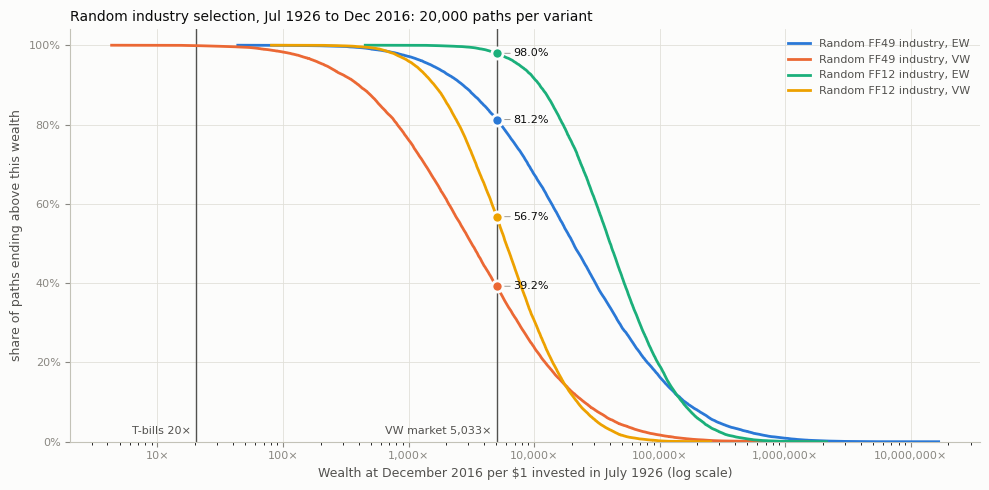

In [33]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

INK, INK_2, MUTED, GRID, BASE, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
# Categorical slots 1-4 in fixed order (validated: scripts/validate_palette.js, light mode).
VARIANT_COLORS = dict(zip(VARIANTS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))
VARIANT_NAMES = {("ff49", "ew"): "Random FF49 industry, EW", ("ff49", "vw"): "Random FF49 industry, VW",
                 ("ff12", "ew"): "Random FF12 industry, EW", ("ff12", "vw"): "Random FF12 industry, VW"}

full_rows = {v: random_eval[v].windows.query("kind == 'full'").iloc[0] for v in VARIANTS}
market_wealth = 1 + full_rows[VARIANTS[0]]["market"]
tbill_wealth = 1 + full_rows[VARIANTS[0]]["tbill"]

fig, ax = plt.subplots(figsize=(10, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for v in VARIANTS:
    wealth = np.sort(full_wealth[v])
    above = 1 - np.arange(1, len(wealth) + 1) / len(wealth)  # share of paths strictly above each sorted value
    ax.plot(wealth, above, color=VARIANT_COLORS[v], linewidth=2, label=VARIANT_NAMES[v], zorder=3)
for x, text in ((tbill_wealth, f"T-bills {tbill_wealth:,.0f}×"), (market_wealth, f"VW market {market_wealth:,.0f}×")):
    ax.axvline(x, color=INK_2, linewidth=1, zorder=2)
    # Bottom-left of each line is empty: every curve is still high to the left of both benchmarks.
    ax.annotate(text, xy=(x, 0), xytext=(-4, 4), textcoords="offset points", ha="right", va="bottom", fontsize=8,
                color=INK_2)

# Dots at the market line carry each variant's share above the market; labels are spread so they never collide.
shares_at_market = sorted(((full_rows[v]["pct_above_vw"], v) for v in VARIANTS))
label_y, last = [], -1.0
for share, _ in shares_at_market:
    last = max(share, last + 0.06)
    label_y.append(last)
for (share, v), y in zip(shares_at_market, label_y):
    ax.plot(market_wealth, share, "o", markersize=8, color=VARIANT_COLORS[v], markeredgecolor=SURFACE,
            markeredgewidth=2, zorder=4)
    ax.annotate(f"{share:.1%}", xy=(market_wealth, share), xytext=(market_wealth * 1.35, y), fontsize=8,
                color=INK, va="center",
                arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.6, shrinkA=0, shrinkB=4))

ax.set_xscale("log")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}×"))
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_ylim(0, 1.04)
ax.set_xlabel("Wealth at December 2016 per $1 invested in July 1926 (log scale)", color=INK_2, fontsize=9)
ax.set_ylabel("share of paths ending above this wealth", color=INK_2, fontsize=9)
ax.set_title("Random industry selection, Jul 1926 to Dec 2016: 20,000 paths per variant", fontsize=10,
             color=INK, loc="left")
ax.grid(True, color=GRID, linewidth=0.6)
ax.tick_params(colors=MUTED, labelsize=8)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(BASE)
ax.legend(loc="upper right", frameon=False, fontsize=8, labelcolor=INK_2)
fig.tight_layout()
fig.savefig(OUTPUT / "fig_random_industry_full_period.png", dpi=150, facecolor=SURFACE)
plt.show()

#### Step 9 findings

Generated from the results above.

In [34]:
def pct(x, digits=1):
    return f"{100 * x:.{digits}f}%"


HORIZON_NAMES = list(HORIZONS.values())
ours = {v: table4_layout(random_eval[v].pooled) for v in VARIANTS}
papers = {n: paper_layout(paper, n) for n in PAPER_SIZES}
share_se = {v: share_standard_errors(random_eval[v].windows).set_index("kind") for v in VARIANTS}
EW49, VW49, EW12, VW12 = VARIANTS


def by_horizon(v, stat="pct_above_vw"):
    return and_join(pct(ours[v].loc[stat, h]) for h in HORIZON_NAMES)


def signed(x, digits=2):
    return f"{x:.{digits}f}".replace("-", "−")


def with_boundary(v, stat):
    # A full-period share of 100% is stated as all sampled paths, with a Wilson lower bound: its plug-in SE is zero.
    full = ours[v].loc[stat, "full period"]
    if full < 1:
        return f"{by_horizon(v, stat)} of outcomes at the three horizons"
    low = float(wilson_interval(full, N_PATHS)[0])
    return (f"{pct(ours[v].loc[stat, '1-year'])} and {pct(ours[v].loc[stat, '10-year'])} of pooled 1-year and "
            f"10-year outcomes, and in all {N_PATHS:,} sampled paths over the full period (pointwise 95% Wilson lower "
            f"bound {pct(low, 3)})")


# Checks.
selection_table = pd.DataFrame(selection_rows)
diagnostic = check_summary[check_summary["full_check"] == "diagnostic only"]
diagnostic_text = and_join(f"{r['variant']} (z = {signed(r['full_z'])})" for _, r in diagnostic.iterrows())

# Task 2.1 against every paper row.
paper_best = {h: max(PAPER_SIZES, key=lambda n: papers[n].loc["pct_above_vw", h]) for h in HORIZON_NAMES}
ew_above_all = all(ours[EW49].loc["pct_above_vw", h] > papers[paper_best[h]].loc["pct_above_vw", h]
                   for h in HORIZON_NAMES)
paper_best_text = and_join(f"{pct(papers[n].loc['pct_above_vw', h], 2)} ({n} stocks)" for h, n in paper_best.items())

# The VW version against the paper's 25- to 100-stock portfolios (market-beating shares only).
LARGE = [25, 50, 100]
band = {h: (min(papers[n].loc["pct_above_vw", h] for n in LARGE), max(papers[n].loc["pct_above_vw", h] for n in LARGE))
        for h in HORIZON_NAMES}
inside = [h for h in HORIZON_NAMES if band[h][0] <= ours[VW49].loc["pct_above_vw", h] <= band[h][1]]
outside = [h for h in HORIZON_NAMES if h not in inside]
band_text = and_join(f"{pct(lo, 2)} to {pct(hi, 2)}" for lo, hi in band.values())
inside_text = ("at all three horizons" if len(inside) == 3 else
               f"at the {and_join(inside)} horizon" + ("s" if len(inside) > 1 else "") if inside else "at no horizon")

# Equal vs value weighting within industries: the same selections, so the difference is the weighting.
gap = [ours[EW49].loc["pct_above_vw", h] - ours[VW49].loc["pct_above_vw", h] for h in HORIZON_NAMES]
exact_year = exact_pooled.set_index(["universe", "weighting", "kind"])["exact_mean"]

# Typical full-period outcome relative to the market.
median_ratio = {v: (1 + ours[v].loc["median", "full period"]) / market_wealth for v in VARIANTS}

# FF12 against FF49 (descriptive: the classifications differ in more than breadth).
median_to_mean = {v: (1 + ours[v].loc["median", "full period"]) / (1 + ours[v].loc["mean", "full period"])
                  for v in VARIANTS}
closer = all(median_to_mean[("ff12", w)] > median_to_mean[("ff49", w)] for w in ("ew", "vw"))
exact_skew = exact_pooled.set_index(["universe", "weighting", "kind"])["exact_skew"]
ff12_less_skewed = all(exact_skew["ff12", w, k] < exact_skew["ff49", w, k] for w in ("ew", "vw") for k in HORIZONS)
ff12_higher = all(ours[("ff12", w)].loc["pct_above_vw", h] > ours[("ff49", w)].loc["pct_above_vw", h]
                  for h in HORIZON_NAMES for w in ("ew", "vw"))


def skew_position(v):
    s = ours[v].loc["skew", "1-year"]
    skews = {n: papers[n].loc["skew", "1-year"] for n in PAPER_SIZES}
    higher = [n for n in PAPER_SIZES if skews[n] >= s]
    lower = [n for n in PAPER_SIZES if skews[n] < s]
    if higher and lower:
        a, b = max(higher), min(lower)
        return f"between the paper's {a}-stock ({skews[a]:.2f}) and {b}-stock ({skews[b]:.2f}) values"
    return "above every paper value" if not higher else "below every paper value"


short_skew_lower = all(ours[v].loc["skew", h] < papers[1].loc["skew", h] for v in VARIANTS for h in ("1-year", "10-year"))

# Decades, classified by pointwise 95% Wilson intervals (cell 63).
n_decades = int((windows["kind"] == "decade").sum())
count = {v: {status: int((decade_class[v] == status).sum()) for status in ("above", "below", "not resolved")}
         for v in VARIANTS}
point_above = {v: int((random_eval[v].windows.query("kind == 'decade'")["pct_above_vw"] > 0.5).sum()) for v in VARIANTS}
unresolved_text = " ".join(
    f"The {u['variant']} estimate for {u['decade']} ({pct(u['share'], 2)} of paths, interval {pct(u['95% Wilson low'], 2)} "
    f"to {pct(u['95% Wilson high'], 2)}) is too close to 50% to say on which side its conditional probability lies, "
    "so it is counted in neither group." for u in unresolved) or "Every decade estimate is resolved."
max_se = {kind: max(share_se[v].loc[kind, f"se_{s}"] for v in VARIANTS for s in SHARES) for kind in HORIZONS}

display(Markdown(rf'''
- **Checks.** Each universe used {selection_table['draws'].iloc[0]:,} draws. No ineligible industry was selected and no selected return was missing. Selection frequencies are consistent with uniform selection (largest |z| {selection_table['largest |z|'].max():.2f}; limits {and_join(f"{z:.2f}" for z in selection_table['z limit'])}). In the mean check, every z-tested row passed in every variant ({and_join(f"{r['variant']} {r['passed']}/{r['tested']}" for _, r in check_summary.iterrows())}; largest |z| {check_summary['max_z_tested'].max():.2f} against a limit of {check_summary['z_limit'].iloc[0]:.2f}). The full period is diagnostic only for {diagnostic_text}.
- **Task 2.1 (FF49, equal-weighted stocks).** Pooled across paths and windows, a random FF49 industry beats the VW market in {by_horizon(EW49)} of outcomes at the 1-year, 10-year and full-period horizons. It beats T-bills in {with_boundary(EW49, 'pct_above_tbill')}. {"The market-beating share is above every paper row at every horizon" if ew_above_all else "The market-beating share is not above every paper row"}; the paper's highest shares are {paper_best_text}. The median full-period wealth is {median_ratio[EW49]:.1f} times the market's.
- **Bonus weighting (FF49, value-weighted stocks).** The shares above the market fall to {by_horizon(VW49)}. These market-beating shares lie within the range of the paper's 25- to 100-stock value-weighted portfolios ({band_text}) {inside_text}{"" if not outside else f", and outside it at the {and_join(outside)} horizon" + ("s" if len(outside) > 1 else "")}. That concerns this one statistic: it is not an equivalence of the return distributions, nor an estimate of an effective number of stocks. The median full-period wealth is {median_ratio[VW49]:.2f} times the market's.
- **Equal vs value weighting within industries.** Both use the same selected industries, so the difference in the share above the market ({and_join(f"{100 * g:.1f}" for g in gap)} percentage points at the three horizons) is attributable to the within-industry weighting of the supplied returns on this history. Over this history the exact 1-year mean is {pct(exact_year['ff49', 'ew', 'year'], 2)} with EW returns and {pct(exact_year['ff49', 'vw', 'year'], 2)} with VW returns; the economic mechanism behind the difference is not tested here. EW performance is before the costs of maintaining equal weights; this analysis does not measure those costs or establish whether the EW advantage survives them.
- **FF12 against FF49.** FF12 has {"higher simulated market-beating shares than FF49 in this sample, at every horizon for both weightings" if ff12_higher else "market-beating shares that are not uniformly higher than FF49's"}: {by_horizon(EW12)} with EW returns and {by_horizon(VW12)} with VW returns. The two classifications differ in industry composition and in the implicit weights that uniform selection gives each part of the market, so this is not a controlled change in diversification alone. FF12 also has {'lower' if ff12_less_skewed else 'not uniformly lower'} exact skewness at every horizon (Step 8), and its full-period median is {'a larger' if closer else 'not a larger'} fraction of its mean: {pct(median_to_mean[EW12], 0)} for FF12 EW against {pct(median_to_mean[EW49], 0)} for FF49 EW, and {pct(median_to_mean[VW12], 0)} against {pct(median_to_mean[VW49], 0)} with VW returns.
- **Skewness.** The industry simulations have {"lower" if short_skew_lower else "not uniformly lower"} reported 1-year and 10-year skewness than the paper's single-stock simulation. The pooled 1-year sample skewness is {ours[EW49].loc['skew', '1-year']:.2f} for FF49 EW, {skew_position(EW49)}, and {ours[VW49].loc['skew', '1-year']:.2f} for FF49 VW, {skew_position(VW49)}. The comparison spans different data and possibly different pooling. Our pooled skewness also includes differences between historical windows, not only dispersion across paths within a window. Over the full period, the FF49 sample skewness ({ours[EW49].loc['skew', 'full period']:.1f} EW, {ours[VW49].loc['skew', 'full period']:.1f} VW) is far below the exact population values for this history ({moments.query("variant == 'FF49 EW' and horizon == 'full period'")['exact skewness'].item():.1f}, {moments.query("variant == 'FF49 VW' and horizon == 'full period'")['exact skewness'].item():.1f}): the heavy-tail limitation flagged in Step 8. These full-period values are not compared with the paper's sample estimates.
- **Dependence on history.** Classified by pointwise 95% Wilson intervals, the share of paths above the market is above 50% in {count[EW49]['above']} of {n_decades} decades for FF49 EW and {count[VW49]['above']} for FF49 VW (FF12: {count[EW12]['above']} and {count[VW12]['above']}), and below 50% in {count[EW49]['below']}, {count[VW49]['below']}, {count[EW12]['below']} and {count[VW12]['below']}. {unresolved_text} The point estimates exceed 50% in {and_join(str(point_above[v]) for v in VARIANTS)} decades respectively.
- **Precision.** Plug-in estimates of the Monte Carlo standard errors of our pooled shares are at most {100 * max_se['year']:.2f}, {100 * max_se['decade']:.2f} and {100 * max_se['full']:.2f} percentage points at the three horizons. They use estimated probabilities, so they are zero for a share of exactly 0% or 100%, where a Wilson bound is given instead. They measure simulation error conditional on this history, not uncertainty about future markets. The comparison with the paper is also subject to its own Monte Carlo error, to the data-vintage difference (CIZ vs FIZ), and to our pooling choice.
- **Scope.** Industries are not stocks. They contain different numbers of correlated stocks, and FF49 industries are single firms in only {pct(share_single)} of eligible industry-months. FF12 is a broad classification, not GICS sectors. All results are conditional on the one realized history and before transaction costs.
'''))


- **Checks.** Each universe used 21,720,000 draws. No ineligible industry was selected and no selected return was missing. Selection frequencies are consistent with uniform selection (largest |z| 2.23; limits 4.26 and 4.00). In the mean check, every z-tested row passed in every variant (FF49 EW 101/101, FF49 VW 101/101, FF12 EW 102/102 and FF12 VW 102/102; largest |z| 3.49 against a limit of 4.42). The full period is diagnostic only for FF49 EW (z = 1.07) and FF49 VW (z = −0.25).
- **Task 2.1 (FF49, equal-weighted stocks).** Pooled across paths and windows, a random FF49 industry beats the VW market in 51.7%, 59.5% and 81.2% of outcomes at the 1-year, 10-year and full-period horizons. It beats T-bills in 63.6% and 90.3% of pooled 1-year and 10-year outcomes, and in all 20,000 sampled paths over the full period (pointwise 95% Wilson lower bound 99.981%). The market-beating share is above every paper row at every horizon; the paper's highest shares are 49.28% (100 stocks), 47.54% (100 stocks) and 43.29% (100 stocks). The median full-period wealth is 4.1 times the market's.
- **Bonus weighting (FF49, value-weighted stocks).** The shares above the market fall to 49.0%, 46.4% and 39.2%. These market-beating shares lie within the range of the paper's 25- to 100-stock value-weighted portfolios (48.69% to 49.28%, 45.37% to 47.54% and 36.81% to 43.29%) at all three horizons. That concerns this one statistic: it is not an equivalence of the return distributions, nor an estimate of an effective number of stocks. The median full-period wealth is 0.63 times the market's.
- **Equal vs value weighting within industries.** Both use the same selected industries, so the difference in the share above the market (2.7, 13.2 and 42.0 percentage points at the three horizons) is attributable to the within-industry weighting of the supplied returns on this history. Over this history the exact 1-year mean is 17.09% with EW returns and 13.24% with VW returns; the economic mechanism behind the difference is not tested here. EW performance is before the costs of maintaining equal weights; this analysis does not measure those costs or establish whether the EW advantage survives them.
- **FF12 against FF49.** FF12 has higher simulated market-beating shares than FF49 in this sample, at every horizon for both weightings: 54.5%, 69.5% and 98.0% with EW returns and 50.4%, 51.8% and 56.7% with VW returns. The two classifications differ in industry composition and in the implicit weights that uniform selection gives each part of the market, so this is not a controlled change in diversification alone. FF12 also has lower exact skewness at every horizon (Step 8), and its full-period median is a larger fraction of its mean: 59% for FF12 EW against 27% for FF49 EW, and 60% against 27% with VW returns.
- **Skewness.** The industry simulations have lower reported 1-year and 10-year skewness than the paper's single-stock simulation. The pooled 1-year sample skewness is 1.75 for FF49 EW, between the paper's 1-stock (6.99) and 5-stock (1.08) values, and 1.32 for FF49 VW, between the paper's 1-stock (6.99) and 5-stock (1.08) values. The comparison spans different data and possibly different pooling. Our pooled skewness also includes differences between historical windows, not only dispersion across paths within a window. Over the full period, the FF49 sample skewness (23.3 EW, 15.8 VW) is far below the exact population values for this history (80.3, 78.6): the heavy-tail limitation flagged in Step 8. These full-period values are not compared with the paper's sample estimates.
- **Dependence on history.** Classified by pointwise 95% Wilson intervals, the share of paths above the market is above 50% in 6 of 9 decades for FF49 EW and 3 for FF49 VW (FF12: 6 and 7), and below 50% in 3, 5, 3 and 2. The FF49 VW estimate for Jan 1997 to Dec 2006 (50.16% of paths, interval 49.46% to 50.85%) is too close to 50% to say on which side its conditional probability lies, so it is counted in neither group. The point estimates exceed 50% in 6, 4, 6 and 7 decades respectively.
- **Precision.** Plug-in estimates of the Monte Carlo standard errors of our pooled shares are at most 0.04, 0.12 and 0.35 percentage points at the three horizons. They use estimated probabilities, so they are zero for a share of exactly 0% or 100%, where a Wilson bound is given instead. They measure simulation error conditional on this history, not uncertainty about future markets. The comparison with the paper is also subject to its own Monte Carlo error, to the data-vintage difference (CIZ vs FIZ), and to our pooling choice.
- **Scope.** Industries are not stocks. They contain different numbers of correlated stocks, and FF49 industries are single firms in only 1.6% of eligible industry-months. FF12 is a broad classification, not GICS sectors. All results are conditional on the one realized history and before transaction costs.


### Step 10: Task 2.2, three-month industry momentum

Each month $t$, hold the industry with the highest return over the previous three months,
$$s_{i,t}=\prod_{j=1}^{3}\left(1+r_{i,t-j}\right)-1,$$
and select again the next month.

- **Candidates.** An industry is a candidate if it is formation-eligible in month $t$ (Step 7's rule) and has returns in months $t-3$ to $t-1$. Rubbr, for example, is rankable again from October 1944, after its gap. Ties go to the lowest position in the declared column order, and a month without candidates stops the run. The first holding month is October 1926.
- **Weighting.** Ranking and holding use the same returns: FF49 EW (Task 2.2), FF49 VW (the bonus weighting), and FF12 EW and VW as robustness. Unlike Step 9, the EW and VW versions rank on different returns, so they often hold different industries. Their difference combines changes in industry selection with changes in within-industry weighting, and it cannot be attributed to reweighting the same holdings.
- **Timing.** The score never uses month $t$, and unit tests confirm that a holding-month return cannot change that month's selection. These are safeguards for the reconstruction assumption. They cannot show that the revised data were available to an investor at the time.
- **Comparison.** Momentum is one deterministic path, so its Table 4 statistics are across historical windows, not across paths. It is compared window by window with Step 9's 20,000 random paths, taken from October 1926 with the same draws and wealth reset to 1 in each window. Momentum's percentile in a window is the share of random paths with lower wealth. It is a Monte Carlo estimate, reported with a pointwise 95% Wilson interval. The percentile is relative to Step 9's baseline, which draws from all formation-eligible industries. Momentum can only rank industries with three lookback returns, so in the three months after an industry enters, its candidate set is smaller than the baseline's. The table after the checks gives how often this happens, and how much restricting the random baseline to the rankable set would change its exact mean.
- **Performance.** Annualized return, volatility, Sharpe ratio over T-bills, maximum drawdown, industry switches and one-way turnover across industry portfolios. Turnover is $\tfrac12\sum_i |w_{i,t}^{\mathrm{target}}-w_{i,t}^{\mathrm{pretrade}}|$, where pretrade weights are the prior targets drifted by prior-month returns. Initial investment and final liquidation are excluded; a complete switch between industries is 100%. Trades within industry portfolios are not observed.

All results are before transaction costs and conditional on the one realized history.

In [35]:
from table4_eval import allocation_turnover, percentile_among, performance_summary
from table4_strategies import held_returns, momentum_candidates, momentum_selections, position_weights

MOM_START = pd.Period("1926-10", "M")
H4 = HORIZONS | {"rolling120": "rolling 10-year"}
bench10 = factors.loc[MOM_START:"2016-12"]
windows10 = standard_windows(bench10.index)
offset = bench.index.get_loc(MOM_START)  # Step 9's selection arrays start in July 1926
if offset != 3:
    raise ValueError("Step 9's selections must start three months before the momentum sample")

momentum, momentum_eval, random10_eval, random10_checks, exact10 = {}, {}, {}, {}, {}
percentiles, turnover, fan, ew_portfolio, ew_turnover = {}, {}, {}, {}, {}
for key, weighting in VARIANTS:
    returns = getattr(industries[key], weighting).loc[bench.index]
    in_sample = eligible[key].loc[bench.index]
    positions = momentum_selections(returns, in_sample, MOM_START)
    held = held_returns(returns, in_sample, positions)  # raises on an ineligible holding or a missing return
    momentum[key, weighting] = pd.DataFrame({"position": positions, "industry": returns.columns[positions].to_numpy(),
                                             "return": held})
    momentum_eval[key, weighting] = evaluate(held, bench10, windows10)

    # Step 9's random paths from October 1926: the same draws, with wealth reset to 1 in each window.
    returns10, eligible10 = returns.loc[MOM_START:], in_sample.loc[MOM_START:]
    paths = selected_returns(returns10, eligible10, selections[key][:, offset:])
    random10_eval[key, weighting] = evaluate(paths, bench10, windows10)
    exact10[key, weighting] = exact_random_moments(returns10, eligible10, windows10)
    random10_checks[key, weighting] = mean_check(random10_eval[key, weighting].windows, exact10[key, weighting])
    enforce_mean_check(random10_checks[key, weighting])  # stops before any export
    table = percentile_among(window_wealth(held, windows10)[:, 0], window_wealth(paths, windows10))
    table["wilson_low"], table["wilson_high"] = wilson_interval(table["percentile"], table["n_paths"])
    table["status"] = classify_against(table["percentile"], table["n_paths"])
    percentiles[key, weighting] = pd.concat([windows10.reset_index(drop=True), table], axis=1)
    if key == "ff49":  # the random band for the figure
        log_wealth = np.cumsum(np.log1p(paths.to_numpy()), axis=0)
        fan[key, weighting] = np.exp(np.percentile(log_wealth, [5, 50, 95], axis=1))
        del log_wealth
    del paths

    turnover[key, weighting] = allocation_turnover(position_weights(positions, returns.columns), returns10)
    ew_portfolio[key, weighting] = eligible_mean_returns(returns10, eligible10)
    ew_weights = eligible10.astype(float).div(eligible10.sum(axis=1), axis=0)
    ew_turnover[key, weighting] = allocation_turnover(ew_weights, returns10)

ties = sum(int(t["ties"].sum()) for t in percentiles.values())
momentum_checks = pd.DataFrame([{
    "variant": variant(*v), "first month": str(momentum[v].index[0]), "months held": len(momentum[v]),
    "industries ever held": momentum[v]["industry"].nunique(),
    "random mean check": f"{int((random10_checks[v]['check'] == 'pass').sum())}/"
                         f"{int((random10_checks[v]['test'] == 'z').sum())} z-tested rows pass",
    "largest |z|": random10_checks[v].loc[random10_checks[v]["test"] == "z", "z"].abs().max(),
    "percentile ties": int(percentiles[v]["ties"].sum())} for v in VARIANTS])

monthly_out = pd.concat([m.assign(universe=k, weighting=w) for (k, w), m in momentum.items()]).rename_axis("month")
monthly_out.to_csv(OUTPUT / "table4_momentum_monthly.csv")
window_out = []
for (k, w), ev in momentum_eval.items():
    frame = ev.windows[["kind", "start", "end", "n_months", "mean", "tbill", "market"]].rename(columns={"mean": "momentum"})
    frame = frame.merge(percentiles[k, w], on=["kind", "start", "end", "n_months"], validate="one_to_one")
    window_out.append(frame.assign(universe=k, weighting=w))
pd.concat(window_out, ignore_index=True).to_csv(OUTPUT / "table4_momentum_windows.csv", index=False)
pd.concat([ev.pooled.assign(universe=k, weighting=w) for (k, w), ev in momentum_eval.items()], ignore_index=True) \
    .to_csv(OUTPUT / "table4_momentum_pooled.csv", index=False)
(OUTPUT / "table4_momentum_run.json").write_text(json.dumps({
    "rule": "hold the candidate with the highest compounded return over months t-3 to t-1",
    "candidates": "formation-eligible in month t with returns in months t-3 to t-1",
    "ties": "lowest position in the declared column order", "first holding month": str(MOM_START),
    "sample end": str(bench10.index[-1]), "weighting": "ranking and holding use the same returns (EW or VW)",
    "random comparison": "Step 9 selections (seed 0) sliced from October 1926; wealth reset to 1 per window",
    "selection_sha256_july_start": {key: selection_fingerprint(s) for key, s in selections.items()},
    "crsp_release": RELEASE}, indent=2) + "\n")

display(momentum_checks.style.hide(axis="index").format({"largest |z|": "{:.2f}"})
        .set_caption("Momentum checks: every holding eligible with a return; random comparison paths re-checked"))

# Comparison scope: EW and VW momentum hold different industries, and momentum's rankable set is smaller than the
# random baseline's eligible set in the months right after an industry enters. The rankable-set effect is measured
# exactly, with no simulation, through the exact mean of uniform selection from the rankable set.
scope_rows, rankable10 = [], {}
for key in ("ff49", "ff12"):
    row = {"universe": key.upper(), "months": len(momentum[key, "ew"]),
           "EW and VW hold different industries":
               int((momentum[key, "ew"]["position"] != momentum[key, "vw"]["position"]).sum())}
    for weighting in ("ew", "vw"):
        returns = getattr(industries[key], weighting).loc[bench.index]
        rankable10[key, weighting] = momentum_candidates(returns, eligible[key].loc[bench.index]).loc[MOM_START:]
        full_exact = exact_random_moments(returns.loc[MOM_START:], rankable10[key, weighting], full_period(bench10.index))
        baseline = exact10[key, weighting].query("kind == 'full'")["exact_mean"].item()
        row[f"{weighting.upper()}: rankable set smaller (months)"] = int(
            (rankable10[key, weighting] != eligible[key].loc[MOM_START:"2016-12"]).any(axis=1).sum())
        row[f"{weighting.upper()}: exact mean wealth, rankable vs eligible"] = \
            (1 + full_exact["exact_mean"].item()) / (1 + baseline) - 1
    scope_rows.append(row)
scope = pd.DataFrame(scope_rows)
display(scope.style.hide(axis="index")
        .format({c: "{:+.2%}" for c in scope.columns if "exact mean" in c})
        .set_caption("Comparison scope: EW/VW holdings, and momentum's rankable set against the random baseline"))

variant,first month,months held,industries ever held,random mean check,largest |z|,percentile ties
FF49 EW,1926-10,1083,48,101/101 z-tested rows pass,2.87,0
FF49 VW,1926-10,1083,47,101/101 z-tested rows pass,3.25,0
FF12 EW,1926-10,1083,12,102/102 z-tested rows pass,2.56,0
FF12 VW,1926-10,1083,12,102/102 z-tested rows pass,3.42,0


universe,months,EW and VW hold different industries,EW: rankable set smaller (months),"EW: exact mean wealth, rankable vs eligible",VW: rankable set smaller (months),"VW: exact mean wealth, rankable vs eligible"
FF49,1083,696,21,+0.53%,21,+0.76%
FF12,1083,652,0,+0.00%,0,+0.00%


#### Full period: momentum against the benchmarks and the random paths

Wealth per \$1 from October 1926 to December 2016 (1,083 months). The random columns are Step 9's paths over the same months. The exact random mean is the realized wealth of the monthly equal-weight portfolio across eligible industries. Momentum's percentile is the share of random paths with lower wealth, with a pointwise 95% Wilson interval.

In [36]:
full10 = []
for v in VARIANTS:
    mom = momentum_eval[v].windows.query("kind == 'full'").iloc[0]
    rnd = random10_eval[v].windows.query("kind == 'full'").iloc[0]
    ex = exact10[v].query("kind == 'full'").iloc[0]
    p = percentiles[v].query("kind == 'full'").iloc[0]
    full10.append({"variant": variant(*v), "momentum": 1 + mom["mean"], "random median": 1 + rnd["median"],
                   "random mean (exact)": 1 + ex["exact_mean"], "VW market": 1 + mom["market"], "T-bills": 1 + mom["tbill"],
                   "momentum percentile": p["percentile"], "95% low": p["wilson_low"], "95% high": p["wilson_high"],
                   "random paths above market": rnd["pct_above_vw"]})
full10 = pd.DataFrame(full10)
display(full10.style.hide(axis="index")
        .format({c: "{:,.0f}×" for c in ["momentum", "random median", "random mean (exact)", "VW market", "T-bills"]}
                | {c: "{:.2%}" for c in ["momentum percentile", "95% low", "95% high", "random paths above market"]})
        .set_caption("Wealth per $1, Oct 1926 to Dec 2016"))

variant,momentum,random median,random mean (exact),VW market,T-bills,momentum percentile,95% low,95% high,random paths above market
FF49 EW,"33,320×","19,430×","69,258×","4,715×",20×,63.16%,62.49%,63.83%,81.53%
FF49 VW,113×,"2,968×","10,993×","4,715×",20×,2.22%,2.02%,2.43%,39.02%
FF12 EW,"39,337,330×","38,766×","65,110×","4,715×",20×,100.00%,99.98%,100.00%,98.09%
FF12 VW,"136,822×","5,574×","9,237×","4,715×",20×,99.94%,99.90%,99.97%,56.41%


#### Table 4 layout: momentum, random selection and the market

Momentum and the VW market are single paths, so their statistics are **across historical windows**: 90 calendar years, 9 decades (the first is October 1926 to December 1936, 123 months) and 964 rolling 10-year windows. Over the full period each is a single realization. The random columns are **across paths and windows**. The market's share above itself is not applicable.

In [37]:
market10 = evaluate(bench10["mkt"], bench10, windows10)
blocks10 = {}
for v in VARIANTS:
    blocks10[f"{variant(*v)}: momentum"] = table4_layout(momentum_eval[v].pooled, horizons=H4)
    blocks10[f"{variant(*v)}: random"] = table4_layout(random10_eval[v].pooled, horizons=H4)
blocks10["VW market"] = table4_layout(market10.pooled, horizons=H4)
blocks10["VW market"].loc["pct_above_vw"] = np.nan  # ties with itself by construction
row_index10 = pd.MultiIndex.from_product([list(H4.values()), STATS], names=["horizon", "statistic"])
layout10 = pd.DataFrame({name: block.T.stack().reindex(row_index10) for name, block in blocks10.items()})
layout10.to_csv(OUTPUT / "table4_momentum_vs_random.csv")

shown10 = layout10.rename(index=STAT_LABELS, level="statistic")
is_skew10 = shown10.index.get_level_values("statistic") == STAT_LABELS["skew"]
display(shown10.style.format("{:,.2%}", subset=(shown10.index[~is_skew10], slice(None)), na_rep="n/a")
        .format("{:.2f}", subset=(shown10.index[is_skew10], slice(None)), na_rep="n/a")
        .set_caption("Momentum (across historical windows) vs random industry (across paths and windows), Oct 1926 to Dec 2016"))

#### Momentum's percentile among the random paths, window by window

For each window, momentum's percentile among the 20,000 random paths of the same universe and weighting. A window counts as above or below the random median only when the pointwise 95% Wilson interval of the percentile lies entirely on one side of 50%. Rolling windows overlap, so their counts are not independent observations.

In [38]:
pct_summary = []
for v in VARIANTS:
    table = percentiles[v]
    for kind, label in (("year", "calendar years"), ("decade", "decades"), ("rolling120", "rolling 10-year")):
        part = table[table["kind"] == kind]
        pct_summary.append({"variant": variant(*v), "windows": label, "count": len(part),
                            "median percentile": part["percentile"].median(),
                            "above random median": int((part["status"] == "above").sum()),
                            "below": int((part["status"] == "below").sum()),
                            "not resolved": int((part["status"] == "not resolved").sum())})
pct_summary = pd.DataFrame(pct_summary)
display(pct_summary.style.hide(axis="index").format({"median percentile": "{:.1%}"})
        .set_caption("Momentum's percentile among random paths (pointwise 95% Wilson classification)"))

decade_pct = None
for v in VARIANTS:
    part = percentiles[v].query("kind == 'decade'")
    mom = momentum_eval[v].windows.query("kind == 'decade'")
    if decade_pct is None:
        decade_pct = pd.DataFrame({"decade": [f"{month_name(a)} to {month_name(b)}" for a, b in zip(part["start"], part["end"])],
                                   "VW market": mom["market"].to_numpy()})
    decade_pct[f"{variant(*v)}: momentum"] = mom["mean"].to_numpy()
    decade_pct[f"{variant(*v)}: percentile"] = part["percentile"].to_numpy()
display(decade_pct.style.hide(axis="index").format("{:.1%}", subset=decade_pct.columns[1:])
        .set_caption("Momentum's decade holding return and its percentile among the random paths"))

variant,windows,count,median percentile,above random median,below,not resolved
FF49 EW,calendar years,90,56.6%,52,37,1
FF49 EW,decades,9,78.9%,6,3,0
FF49 EW,rolling 10-year,964,77.7%,653,305,6
FF49 VW,calendar years,90,50.9%,46,44,0
FF49 VW,decades,9,22.4%,3,6,0
FF49 VW,rolling 10-year,964,45.8%,446,508,10
FF12 EW,calendar years,90,82.8%,67,23,0
FF12 EW,decades,9,99.4%,8,1,0
FF12 EW,rolling 10-year,964,100.0%,851,112,1
FF12 VW,calendar years,90,70.2%,64,26,0


decade,VW market,FF49 EW: momentum,FF49 EW: percentile,FF49 VW: momentum,FF49 VW: percentile,FF12 EW: momentum,FF12 EW: percentile,FF12 VW: momentum,FF12 VW: percentile
Oct 1926 to Dec 1936,83.2%,-94.3%,0.0%,-88.6%,0.3%,265.4%,71.8%,661.5%,99.7%
Jan 1937 to Dec 1946,67.7%,-41.9%,0.5%,41.3%,29.2%,68.5%,9.0%,116.8%,75.8%
Jan 1947 to Dec 1956,363.8%,191.4%,26.3%,172.7%,19.0%,856.7%,100.0%,424.0%,85.5%
Jan 1957 to Dec 1966,148.7%,330.5%,78.9%,198.2%,56.6%,486.5%,98.8%,347.4%,96.5%
Jan 1967 to Dec 1976,81.9%,540.5%,99.0%,107.1%,68.0%,648.4%,100.0%,132.7%,74.8%
Jan 1977 to Dec 1986,298.4%,598.0%,54.4%,195.9%,18.9%,2465.9%,100.0%,492.0%,89.9%
Jan 1987 to Dec 1996,295.7%,444.9%,95.0%,711.0%,98.2%,1910.0%,100.0%,464.9%,91.0%
Jan 1997 to Dec 2006,128.2%,2234.2%,100.0%,33.4%,17.9%,1026.0%,99.4%,63.1%,18.6%
Jan 2007 to Dec 2016,103.3%,1316.5%,100.0%,29.6%,22.4%,162.0%,82.1%,178.6%,82.0%


#### Performance and turnover

Monthly returns from October 1926 to December 2016, before costs. For reference, the table includes the monthly equal-weight portfolio across eligible industries, which is the expected outcome of random selection (Step 8), together with the VW market and T-bills. Turnover is one-way turnover across industry portfolios, excluding the initial investment, averaged over the calendar years 1927–2016. A momentum switch counts as 100%. The equal-weight portfolio trades only to restore its weights and to follow changes in the eligible set.

In [39]:
perf_rows = []
for v in VARIANTS:
    t = turnover[v]
    perf_rows.append({"strategy": f"Momentum, {variant(*v)}", **performance_summary(momentum[v]["return"], bench10["rf"]),
                      "switches": int((t == 1).sum()),
                      "annual turnover": t.groupby(t.index.year).sum().loc[1927:2016].mean()})
for v in VARIANTS:
    t = ew_turnover[v]
    perf_rows.append({"strategy": f"Equal weight across industries, {variant(*v)}",
                      **performance_summary(ew_portfolio[v], bench10["rf"]), "switches": np.nan,
                      "annual turnover": t.groupby(t.index.year).sum().loc[1927:2016].mean()})
perf_rows.append({"strategy": "VW market", **performance_summary(bench10["mkt"], bench10["rf"]),
                  "switches": np.nan, "annual turnover": np.nan})
perf_rows.append({"strategy": "T-bills", **performance_summary(bench10["rf"], bench10["rf"]),
                  "switches": np.nan, "annual turnover": np.nan})
performance = pd.DataFrame(perf_rows)
performance.to_csv(OUTPUT / "table4_momentum_performance.csv", index=False)
display(performance.drop(columns="months").style.hide(axis="index")
        .format({"terminal wealth": "{:,.0f}×", "annualized return": "{:.2%}", "annualized volatility": "{:.2%}",
                 "Sharpe ratio": "{:.2f}", "max drawdown": "{:.1%}", "switches": "{:,.0f}",
                 "annual turnover": "{:.0%}"}, na_rep="n/a")
        .set_caption("Performance, Oct 1926 to Dec 2016 (before costs)"))

strategy,terminal wealth,annualized return,annualized volatility,Sharpe ratio,max drawdown,drawdown peak,drawdown trough,switches,annual turnover
"Momentum, FF49 EW","33,320×",12.23%,35.93%,0.40,-99.7%,1929-07,1942-03,686,761%
"Momentum, FF49 VW",113×,5.38%,32.88%,0.23,-99.2%,1929-08,1941-04,731,811%
"Momentum, FF12 EW","39,337,330×",21.38%,26.39%,0.74,-83.7%,1929-09,1932-05,517,574%
"Momentum, FF12 VW","136,822×",14.00%,20.62%,0.58,-71.1%,1929-09,1932-05,610,677%
"Equal weight across industries, FF49 EW","69,258×",13.14%,24.94%,0.48,-85.0%,1929-08,1932-05,n/a,19%
"Equal weight across industries, FF49 VW","10,993×",10.86%,20.65%,0.44,-85.3%,1929-08,1932-06,n/a,20%
"Equal weight across industries, FF12 EW","65,110×",13.07%,24.00%,0.49,-84.7%,1929-08,1932-05,n/a,13%
"Equal weight across industries, FF12 VW","9,237×",10.65%,18.54%,0.46,-83.4%,1929-08,1932-05,n/a,13%
VW market,"4,715×",9.83%,18.58%,0.42,-83.7%,1929-08,1932-06,n/a,n/a
T-bills,20×,3.38%,0.88%,n/a,-0.1%,1938-10,1941-04,n/a,n/a


#### What momentum holds

Descriptive only. The table shows how often momentum holds a very small industry, measured by its firm count that month. It compares this with the exact expected share under uniform selection, from two sets: all formation-eligible industries (Step 9's baseline) and momentum's rankable set. It also lists the industries held most often.

In [40]:
def uniform_share(eligible_mask, mask):
    # Expected share of months under uniform selection from the eligible set.
    return np.mean((eligible_mask & mask).sum(axis=1) / eligible_mask.sum(axis=1))


holding_rows = []
for key, weighting in VARIANTS:
    firms10 = industries[key].firms.loc[MOM_START:"2016-12"].to_numpy()
    eligible10 = eligible[key].loc[MOM_START:"2016-12"].to_numpy()
    held_firms = firms10[np.arange(len(firms10)), momentum[key, weighting]["position"].to_numpy()]
    top = momentum[key, weighting]["industry"].value_counts(normalize=True).head(3)
    holding_rows.append({"variant": variant(key, weighting),
                         "held: 1 firm": np.mean(held_firms == 1), "uniform: 1 firm": uniform_share(eligible10, firms10 == 1),
                         "held: ≤ 5 firms": np.mean(held_firms <= 5), "uniform: ≤ 5 firms": uniform_share(eligible10, firms10 <= 5),
                         "uniform over rankable: ≤ 5 firms": uniform_share(rankable10[key, weighting].to_numpy(), firms10 <= 5),
                         "median firms, held industry": np.median(held_firms),
                         "most held (share of months)": ", ".join(f"{name} {share:.0%}" for name, share in top.items())})
holdings = pd.DataFrame(holding_rows)
display(holdings.style.hide(axis="index")
        .format({c: "{:.1%}" for c in ["held: 1 firm", "uniform: 1 firm", "held: ≤ 5 firms", "uniform: ≤ 5 firms",
                                       "uniform over rankable: ≤ 5 firms"]}
                | {"median firms, held industry": "{:.0f}"})
        .set_caption("Firm counts of the industries momentum holds, against uniform selection"))

variant,held: 1 firm,uniform: 1 firm,held: ≤ 5 firms,uniform: ≤ 5 firms,uniform over rankable: ≤ 5 firms,"median firms, held industry",most held (share of months)
FF49 EW,5.4%,1.6%,33.7%,14.5%,14.5%,9,"Gold 8%, Coal 7%, Smoke 5%"
FF49 VW,5.4%,1.6%,33.8%,14.5%,14.5%,10,"Gold 9%, Coal 8%, Smoke 5%"
FF12 EW,0.0%,0.0%,2.5%,1.3%,1.3%,109,"Enrgy 20%, Utils 18%, Hlth 13%"
FF12 VW,0.0%,0.0%,1.9%,1.3%,1.3%,112,"Enrgy 15%, Durbl 15%, BusEq 11%"


#### Wealth over time, FF49

Momentum's wealth against the VW market, with the band from the 5th to the 95th percentile of the 20,000 random paths and their median, on a log scale. Percentiles are taken month by month, so the band is not a single path.

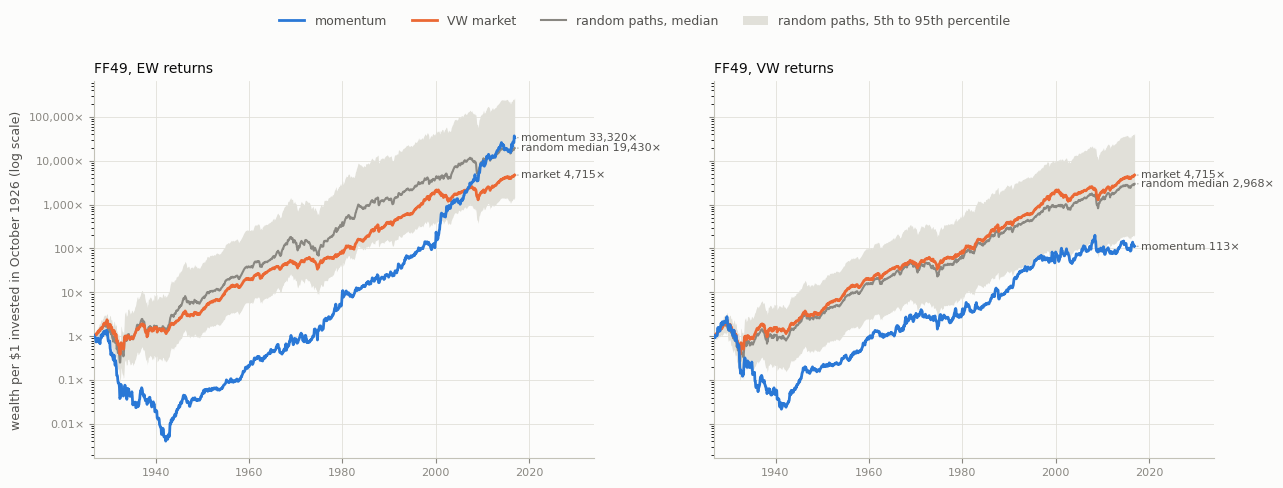

In [41]:
import matplotlib.dates as mdates

MOMENTUM_COLOR, MARKET_COLOR = "#2a78d6", "#eb6834"  # categorical slots 1 and 2 (validated with slots 1-4 in Step 9)
dates = bench10.index.to_timestamp()
market_path = np.cumprod(1 + bench10["mkt"].to_numpy())


def spread_log(values, gap):
    # Push label heights (log10) apart until neighbours are at least `gap` apart.
    order = np.argsort(values)
    pos = np.log10(np.asarray(values, dtype=float))[order]
    for _ in range(200):
        overlap = gap - np.diff(pos)
        if (overlap <= 1e-12).all():
            break
        for i in np.flatnonzero(overlap > 1e-12):
            pos[i] -= overlap[i] / 2
            pos[i + 1] += overlap[i] / 2
    out = np.empty_like(pos)
    out[order] = pos
    return 10**out


fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True, facecolor=SURFACE)
for ax, v in zip(axes, [("ff49", "ew"), ("ff49", "vw")]):
    ax.set_facecolor(SURFACE)
    low, mid, high = fan[v]
    ax.fill_between(dates, low, high, color=GRID, linewidth=0, zorder=1, label="random paths, 5th to 95th percentile")
    ax.plot(dates, mid, color=MUTED, linewidth=1.5, zorder=2, label="random paths, median")
    ax.plot(dates, market_path, color=MARKET_COLOR, linewidth=2, zorder=3, label="VW market")
    mom_path = np.cumprod(1 + momentum[v]["return"].to_numpy())
    ax.plot(dates, mom_path, color=MOMENTUM_COLOR, linewidth=2, zorder=4, label="momentum")
    ends = [mom_path[-1], market_path[-1], mid[-1]]
    names = ["momentum", "market", "random median"]
    for y, label_y, name in zip(ends, spread_log(ends, 0.18), names):
        ax.annotate(f"{name} {y:,.0f}×", xy=(dates[-1], y), xytext=(dates[-1] + pd.Timedelta(days=500), label_y),
                    fontsize=8, color=INK_2, va="center",
                    arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.6, shrinkA=0, shrinkB=2))
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}×" if x >= 1 else f"{x:g}×"))
    ax.set_title(f"FF49, {v[1].upper()} returns", fontsize=10, color=INK, loc="left")
    ax.xaxis.set_major_locator(mdates.YearLocator(20))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_xlim(dates[0], dates[-1] + pd.Timedelta(days=6200))
    ax.grid(True, color=GRID, linewidth=0.6)
    ax.tick_params(colors=MUTED, labelsize=8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(BASE)
axes[0].set_ylabel("wealth per $1 invested in October 1926 (log scale)", color=INK_2, fontsize=9)
handles, labels = axes[0].get_legend_handles_labels()
order = [labels.index(name) for name in ("momentum", "VW market", "random paths, median", "random paths, 5th to 95th percentile")]
fig.legend([handles[i] for i in order], [labels[i] for i in order], loc="upper center", ncol=4, frameon=False,
           fontsize=9, bbox_to_anchor=(0.5, 1.02), labelcolor=INK_2)
fig.tight_layout(rect=(0, 0, 1, 0.93), w_pad=3)
fig.savefig(OUTPUT / "fig_momentum_wealth.png", dpi=150, facecolor=SURFACE)
plt.show()

#### Step 10 findings

Generated from the results above.

In [42]:
perf = performance.set_index("strategy")
n_decades = int((windows10["kind"] == "decade").sum())
mom_layout = {v: table4_layout(momentum_eval[v].pooled, horizons=H4) for v in VARIANTS}
full_by = full10.set_index("variant")


def percentile_text(v, kind="full"):
    row = percentiles[v].query("kind == @kind").iloc[0]
    if row["percentile"] == 1:
        return (f"above all {N_PATHS:,} random paths (pointwise 95% Wilson lower bound for its percentile "
                f"{pct(row['wilson_low'], 3)})")
    if row["percentile"] == 0:
        return f"below all {N_PATHS:,} random paths (pointwise 95% Wilson upper bound {pct(row['wilson_high'], 3)})"
    return (f"at the {pct(row['percentile'], 2)} percentile of the random paths (95% interval "
            f"{pct(row['wilson_low'], 2)} to {pct(row['wilson_high'], 2)})")


def full_text(v):
    row = full_by.loc[variant(*v)]
    market = "above" if row["momentum"] > row["VW market"] else "below"
    equal = "above" if row["momentum"] > row["random mean (exact)"] else "below"
    return (f"{row['momentum']:,.0f}× against {row['VW market']:,.0f}× for the VW market ({market} it) and "
            f"{row['random mean (exact)']:,.0f}× for the equal-weight portfolio across industries ({equal} it), "
            f"{percentile_text(v)}")


def history_text(v):
    lay = mom_layout[v]
    decades_won = int(momentum_eval[v].windows.query("kind == 'decade'")["pct_above_vw"].sum())
    return (f"it beat the market in {pct(lay.loc['pct_above_vw', '1-year'])} of calendar years, {decades_won} of "
            f"{n_decades} decades and {pct(lay.loc['pct_above_vw', 'rolling 10-year'])} of rolling 10-year windows")


def rank_text(v):
    rows = pct_summary[(pct_summary["variant"] == variant(*v)) & (pct_summary["windows"] == "calendar years")].iloc[0]
    return (f"its median percentile across calendar years is {pct(rows['median percentile'])}; it is above the random "
            f"median in {rows['above random median']} years, below in {rows['below']} and not resolved in "
            f"{rows['not resolved']}")


def perf_text(name):
    row = perf.loc[name]
    return (f"{pct(row['annualized return'], 2)} a year, volatility {pct(row['annualized volatility'])}, Sharpe ratio "
            f"{row['Sharpe ratio']:.2f}, maximum drawdown {signed(100 * row['max drawdown'], 1)}% ({row['drawdown peak']} to "
            f"{row['drawdown trough']})")


worst_decade = {v: percentiles[v].query("kind == 'decade'").sort_values("percentile").iloc[0] for v in VARIANTS}
small = holdings.set_index("variant")
EW49, VW49, EW12, VW12 = VARIANTS
scope_by = scope.set_index("universe")
rankable_effect = {w: scope_by.loc['FF49', f'{w}: exact mean wealth, rankable vs eligible'] for w in ('EW', 'VW')}
direction = 'raise' if all(x > 0 for x in rankable_effect.values()) else 'lower' if all(x < 0 for x in rankable_effect.values()) else 'change'
gap12 = scope_by.loc['FF12', 'EW: rankable set smaller (months)']
gap12_text = 'in no FF12 month' if gap12 == 0 else f'in {gap12} FF12 months'
mom_name = {v: f"Momentum, {variant(*v)}" for v in VARIANTS}
ewp_name = {v: f"Equal weight across industries, {variant(*v)}" for v in VARIANTS}

display(Markdown(rf'''
- **Checks.** Every momentum holding was an eligible industry with a return. The first holding month is {momentum_checks['first month'].iloc[0]}, and Rubbr is rankable again only from {str(momentum_candidates(getattr(industries['ff49'], 'ew').loc[bench.index], eligible['ff49'].loc[bench.index])['Rubbr'].loc['1944-07':].idxmax())} after its gap. Step 9's random paths, re-evaluated from October 1926, pass the mean check against the exact benchmark in every variant (largest |z| {momentum_checks['largest |z|'].max():.2f}). No random path tied momentum's wealth in any window ({ties} ties).
- **Task 2.2 (FF49, equal-weighted stocks).** Over the full period, momentum ends at {full_text(EW49)}. Across historical windows, {history_text(EW49)}; {rank_text(EW49)}. Its annualized figures: {perf_text(mom_name[EW49])}. For comparison, the equal-weight portfolio across industries (the expected outcome of random selection) returned {perf_text(ewp_name[EW49])}, and the VW market {perf_text('VW market')}.
- **Bonus weighting (FF49, value-weighted stocks).** Momentum ends at {full_text(VW49)}. Across historical windows, {history_text(VW49)}; {rank_text(VW49)}. Annualized: {perf_text(mom_name[VW49])}.
- **FF12 robustness.** With EW returns, momentum ends at {full_text(EW12)}; with VW returns, at {full_text(VW12)}. The FF12 rules beat the market in {pct(mom_layout[EW12].loc['pct_above_vw', '1-year'])} (EW) and {pct(mom_layout[VW12].loc['pct_above_vw', '1-year'])} (VW) of calendar years.
- **Comparison scope.** Unlike Step 9's paired comparison, EW and VW momentum rank on different returns. They hold different industries in {scope_by.loc['FF49', 'EW and VW hold different industries']:,} of {scope_by.loc['FF49', 'months']:,} months for FF49 and {scope_by.loc['FF12', 'EW and VW hold different industries']:,} for FF12. The EW–VW difference in momentum's results therefore combines changes in industry selection with changes in within-industry weighting, and cannot be attributed to reweighting the same holdings. Momentum's percentiles are relative to Step 9's random baseline, which draws from all formation-eligible industries. Momentum's rankable set is smaller in {scope_by.loc['FF49', 'EW: rankable set smaller (months)']} FF49 months (the three months after each entry, and after Rubbr's gap) and {gap12_text}. Restricting random selection to the rankable set would {direction} its exact full-period mean wealth by {abs(100 * rankable_effect['EW']):.2f}% (EW) and {abs(100 * rankable_effect['VW']):.2f}% (VW) for FF49.
- **History matters.** Each variant's weakest decade relative to the random paths is: {and_join(f"{variant(*v)} {month_name(worst_decade[v]['start'])} to {month_name(worst_decade[v]['end'])} (percentile {pct(worst_decade[v]['percentile'])})" for v in VARIANTS)}. The full decade table is above.
- **Turnover (before costs).** Momentum switches industry in {and_join(f"{int(perf.loc[mom_name[v], 'switches']):,}" for v in VARIANTS)} of its {len(momentum[EW49]) - 1:,} rebalancing months (FF49 EW, FF49 VW, FF12 EW, FF12 VW). That is an average one-way turnover across industry portfolios of {and_join(f"{perf.loc[mom_name[v], 'annual turnover']:.0%}" for v in VARIANTS)} a year, against {and_join(f"{perf.loc[ewp_name[v], 'annual turnover']:.0%}" for v in VARIANTS)} for the equal-weight portfolios. These figures count trades between industry portfolios only. Trades within them are not observed, and no costs are deducted.
- **What FF49 momentum holds (descriptive).** FF49 momentum holds an industry with at most 5 firms in {pct(small.loc['FF49 EW', 'held: ≤ 5 firms'])} (EW) and {pct(small.loc['FF49 VW', 'held: ≤ 5 firms'])} (VW) of months. Uniform selection would give {pct(small.loc['FF49 EW', 'uniform: ≤ 5 firms'], 2)} from the eligible set, and {pct(small.loc['FF49 EW', 'uniform over rankable: ≤ 5 firms'], 2)} (EW) or {pct(small.loc['FF49 VW', 'uniform over rankable: ≤ 5 firms'], 2)} (VW) from momentum's rankable set. It holds a single-firm industry in {pct(small.loc['FF49 EW', 'held: 1 firm'])} (EW) and {pct(small.loc['FF49 VW', 'held: 1 firm'])} (VW) of months, against {pct(small.loc['FF49 EW', 'uniform: 1 firm'])}. FF12 momentum holds an industry with at most 5 firms in {pct(small.loc['FF12 EW', 'held: ≤ 5 firms'])} and {pct(small.loc['FF12 VW', 'held: ≤ 5 firms'])} of months. A plausible reason, not tested here: selecting the maximum of noisy three-month returns favours the most volatile industries, which in FF49 are often those with few firms.
- **Scope.** Momentum is one path, so its window statistics are historical frequencies on one realized history, not probabilities. The rule was fixed in advance by the assignment, but it is evaluated in-sample on revised data under the reconstruction assumption. All results are before transaction costs.
'''))


- **Checks.** Every momentum holding was an eligible industry with a return. The first holding month is 1926-10, and Rubbr is rankable again only from 1944-10 after its gap. Step 9's random paths, re-evaluated from October 1926, pass the mean check against the exact benchmark in every variant (largest |z| 3.42). No random path tied momentum's wealth in any window (0 ties).
- **Task 2.2 (FF49, equal-weighted stocks).** Over the full period, momentum ends at 33,320× against 4,715× for the VW market (above it) and 69,258× for the equal-weight portfolio across industries (below it), at the 63.16% percentile of the random paths (95% interval 62.49% to 63.83%). Across historical windows, it beat the market in 54.4% of calendar years, 6 of 9 decades and 69.6% of rolling 10-year windows; its median percentile across calendar years is 56.6%; it is above the random median in 52 years, below in 37 and not resolved in 1. Its annualized figures: 12.23% a year, volatility 35.9%, Sharpe ratio 0.40, maximum drawdown −99.7% (1929-07 to 1942-03). For comparison, the equal-weight portfolio across industries (the expected outcome of random selection) returned 13.14% a year, volatility 24.9%, Sharpe ratio 0.48, maximum drawdown −85.0% (1929-08 to 1932-05), and the VW market 9.83% a year, volatility 18.6%, Sharpe ratio 0.42, maximum drawdown −83.7% (1929-08 to 1932-06).
- **Bonus weighting (FF49, value-weighted stocks).** Momentum ends at 113× against 4,715× for the VW market (below it) and 10,993× for the equal-weight portfolio across industries (below it), at the 2.22% percentile of the random paths (95% interval 2.02% to 2.43%). Across historical windows, it beat the market in 47.8% of calendar years, 3 of 9 decades and 46.5% of rolling 10-year windows; its median percentile across calendar years is 50.9%; it is above the random median in 46 years, below in 44 and not resolved in 0. Annualized: 5.38% a year, volatility 32.9%, Sharpe ratio 0.23, maximum drawdown −99.2% (1929-08 to 1941-04).
- **FF12 robustness.** With EW returns, momentum ends at 39,337,330× against 4,715× for the VW market (above it) and 65,110× for the equal-weight portfolio across industries (above it), above all 20,000 random paths (pointwise 95% Wilson lower bound for its percentile 99.981%); with VW returns, at 136,822× against 4,715× for the VW market (above it) and 9,237× for the equal-weight portfolio across industries (above it), at the 99.94% percentile of the random paths (95% interval 99.90% to 99.97%). The FF12 rules beat the market in 71.1% (EW) and 66.7% (VW) of calendar years.
- **Comparison scope.** Unlike Step 9's paired comparison, EW and VW momentum rank on different returns. They hold different industries in 696 of 1,083 months for FF49 and 652 for FF12. The EW–VW difference in momentum's results therefore combines changes in industry selection with changes in within-industry weighting, and cannot be attributed to reweighting the same holdings. Momentum's percentiles are relative to Step 9's random baseline, which draws from all formation-eligible industries. Momentum's rankable set is smaller in 21 FF49 months (the three months after each entry, and after Rubbr's gap) and in no FF12 month. Restricting random selection to the rankable set would raise its exact full-period mean wealth by 0.53% (EW) and 0.76% (VW) for FF49.
- **History matters.** Each variant's weakest decade relative to the random paths is: FF49 EW Oct 1926 to Dec 1936 (percentile 0.0%), FF49 VW Oct 1926 to Dec 1936 (percentile 0.3%), FF12 EW Jan 1937 to Dec 1946 (percentile 9.0%) and FF12 VW Jan 1997 to Dec 2006 (percentile 18.6%). The full decade table is above.
- **Turnover (before costs).** Momentum switches industry in 686, 731, 517 and 610 of its 1,082 rebalancing months (FF49 EW, FF49 VW, FF12 EW, FF12 VW). That is an average one-way turnover across industry portfolios of 761%, 811%, 574% and 677% a year, against 19%, 20%, 13% and 13% for the equal-weight portfolios. These figures count trades between industry portfolios only. Trades within them are not observed, and no costs are deducted.
- **What FF49 momentum holds (descriptive).** FF49 momentum holds an industry with at most 5 firms in 33.7% (EW) and 33.8% (VW) of months. Uniform selection would give 14.51% from the eligible set, and 14.48% (EW) or 14.48% (VW) from momentum's rankable set. It holds a single-firm industry in 5.4% (EW) and 5.4% (VW) of months, against 1.6%. FF12 momentum holds an industry with at most 5 firms in 2.5% and 1.9% of months. A plausible reason, not tested here: selecting the maximum of noisy three-month returns favours the most volatile industries, which in FF49 are often those with few firms.
- **Scope.** Momentum is one path, so its window statistics are historical frequencies on one realized history, not probabilities. The rule was fixed in advance by the assignment, but it is evaluated in-sample on revised data under the reconstruction assumption. All results are before transaction costs.


### Step 11: Task 2.3 (bonus), candidate strategies and historical 10-year win rates

The task asks for a strategy with at least a 50% chance of beating the VW market over 10 years, before transaction costs. We compare two candidate rules and assess their historical win rates. We treat this comparison as exploratory and the screening criterion as a retrospective assessment:

- **(a) Equal weight across industries:** hold every formation-eligible FF49 industry with equal weight, value-weighted within each industry, rebalanced monthly. This is exactly the expected outcome of random FF49 VW selection (Step 8).
- **(b) Top 5 by six-month return:** each month, hold the 5 FF49 industries with the highest return over months $t-6$ to $t-1$ (Moskowitz and Grinblatt's main ranking period), with equal weights, value-weighted within each industry, rebalanced monthly. The candidates and tie rule are Step 10's.

**Conventions.** Value weighting within industries puts less weight on small firms than equal weighting, which suits a VW benchmark. It does not guarantee that small firms cannot drive results. Each rule's monthly returns are computed once over the whole history, with signals starting in July 1926, so every month's signal (including after the 1996 split) uses all earlier data. Evaluation windows reset wealth to 1 but never reset the signal. The six-month rule's first holding month is January 1927, so both rules and the market are evaluated from January 1927 to August 2026 (1,196 months). The first paper-style decade is therefore 120 months rather than 126.

**Historical screen.** A rule passes this descriptive screen when its historical win rate against the VW market is at least 50% on both:
- the paper's 9 decades to 2016;
- the 249 rolling 10-year windows that lie entirely within January 1996 to August 2026.

A win is a strictly higher holding return than the market over the same window.

**How to read it.**
- Win rates are historical frequencies on one realized history, not established future probabilities.
- Adjacent rolling windows share 119 months, and the holdout contains only three non-overlapping decades.
- The two parts of the screen are not independent confirmations: the paper's decades 1987–1996, 1997–2006 and 2007–2016 overlap the holdout. Results before 1996 and in the holdout are reported separately.
- The period labeled "holdout" is the January 1996 onward evaluation split. It is a retrospective comparison, not independent validation: the earlier analysis covers data through 2016, and the same evaluation results are used to compare the two candidates. January 2017 to August 2026 is also shown separately, but those months enter this screen and the final choice. The 116-month post-2016 period contains no complete 10-year window.
- Everything is before transaction costs.

In [43]:
from table4_eval import calendar_decades, custom_windows, paper_decades, rolling_windows
from table4_strategies import equal_industry_weights, portfolio_returns, top_k_weights

BONUS_START, HOLDOUT_START, POST2016_START = pd.Period("1927-01", "M"), pd.Period("1996-01", "M"), pd.Period("2017-01", "M")
PRE_DECADE_END, PRE_ROLLING_END = pd.Period("1986-12", "M"), pd.Period("1995-12", "M")
LAST = factors.index[-1]
bench27 = factors.loc[BONUS_START:]
vw49, eligible49 = industries["ff49"].vw, eligible["ff49"]  # the full history: signals start in July 1926
RULES = {"a": "(a) equal weight across industries", "b": "(b) top 5 by six-month return"}

bonus_weights = {"a": equal_industry_weights(eligible49, BONUS_START),
                 "b": top_k_weights(vw49, eligible49, BONUS_START, lookback=6, k=5)}
bonus_returns = {r: portfolio_returns(w, vw49, eligible49) for r, w in bonus_weights.items()}  # raises on a gap

paper_dec27 = paper_decades(bench27.index)
holdout_dec = custom_windows("holdout decade", [("1996-01", "2005-12"), ("2006-01", "2015-12"), ("2016-01", "2025-12")])
rolling27 = rolling_windows(bench27.index)
offset_dec = pd.concat([calendar_decades(bench27.index, 1927 + k, kind=f"offset {k}") for k in range(10)],
                       ignore_index=True)
bonus_windows = pd.concat([paper_dec27, holdout_dec, rolling27, offset_dec], ignore_index=True)
bonus_eval = {r: evaluate(ret, bench27, bonus_windows).windows for r, ret in bonus_returns.items()}

# Checks. Rule (a) must realize the exact mean of random FF49 VW selection in every window (Step 8's identity).
exact_windows_a = pd.concat([paper_dec27, holdout_dec, rolling27], ignore_index=True)
exact_a = exact_random_moments(vw49.loc[BONUS_START:], eligible49.loc[BONUS_START:], exact_windows_a)
gap_a = float(np.max(np.abs(window_wealth(bonus_returns["a"], exact_windows_a)[:, 0] / (1 + exact_a["exact_mean"]) - 1)))
holdings_b = (bonus_weights["b"] > 0).sum(axis=1)
rubbr6 = momentum_candidates(vw49, eligible49, lookback=6)["Rubbr"].loc["1944-07":].idxmax()
n_rolling_holdout = int((rolling27["start"] >= HOLDOUT_START).sum())
n_rolling_pre = int((rolling27["end"] <= PRE_ROLLING_END).sum())
bonus_checks = pd.DataFrame([
    {"check": "Rule (a) realizes the exact mean of random FF49 VW selection in every window (largest relative gap)",
     "observed": f"{gap_a:.1e}", "ok": gap_a <= 1e-12},
    {"check": "Rule (b) holds exactly 5 eligible industries with returns every month",
     "observed": f"{holdings_b.min()} to {holdings_b.max()}", "ok": bool((holdings_b == 5).all())},
    {"check": "First holding month of both rules (signals use data from July 1926)",
     "observed": f"{bonus_returns['a'].index[0]}, {bonus_returns['b'].index[0]}",
     "ok": all(r.index[0] == BONUS_START for r in bonus_returns.values())},
    {"check": "Rubbr rankable on six months again from", "observed": str(rubbr6), "ok": str(rubbr6) == "1945-01"},
    {"check": "Windows: paper decades (first length), holdout decades, rolling (holdout, pre-1996), offsets",
     "observed": f"{len(paper_dec27)} ({paper_dec27['n_months'].iloc[0]}), {len(holdout_dec)}, {len(rolling27):,} "
                 f"({n_rolling_holdout}, {n_rolling_pre}), {offset_dec['kind'].nunique()} × "
                 f"{offset_dec.groupby('kind').size().min()}",
     "ok": (len(paper_dec27), paper_dec27["n_months"].iloc[0], n_rolling_holdout, n_rolling_pre) == (9, 120, 249, 709)},
])
if not bonus_checks["ok"].all():
    raise ValueError("a Step 11 check failed:\n" + bonus_checks[~bonus_checks["ok"]].to_string())

# The screen and the separate pre-1996 and holdout results.
MEASURES = [
    ("Paper decades to 2016 (screen)", lambda e: e[e["kind"] == "decade"]),
    ("Holdout rolling 10-year windows (screen)", lambda e: e[(e["kind"] == "rolling120") & (e["start"] >= HOLDOUT_START)]),
    ("Pre-1996: paper decades ending by Dec 1986", lambda e: e[(e["kind"] == "decade") & (e["end"] <= PRE_DECADE_END)]),
    ("Pre-1996: rolling windows ending by Dec 1995", lambda e: e[(e["kind"] == "rolling120") & (e["end"] <= PRE_ROLLING_END)]),
    ("Holdout decades 1996-2005, 2006-2015, 2016-2025", lambda e: e[e["kind"] == "holdout decade"]),
    ("All rolling 10-year windows", lambda e: e[e["kind"] == "rolling120"]),
]
screen_rows = []
for label, select in MEASURES:
    row = {"measure": label}
    for r in RULES:
        part = select(bonus_eval[r])
        row["windows"] = len(part)
        row[f"{r}: wins"] = int(part["pct_above_vw"].sum())
        row[f"{r}: win rate"] = part["pct_above_vw"].mean()
    screen_rows.append(row)
screen = pd.DataFrame(screen_rows)
passes = {r: bool((screen.loc[:1, f"{r}: win rate"] >= 0.5).all()) for r in RULES}

monthly_bonus = pd.DataFrame({"a_return": bonus_returns["a"], "b_return": bonus_returns["b"],
                              "b_holdings": [", ".join(vw49.columns[row > 0]) for row in bonus_weights["b"].to_numpy()]},
                             index=bench27.index)
monthly_bonus.to_csv(OUTPUT / "table4_bonus_monthly.csv")
pd.concat([e.assign(rule=r) for r, e in bonus_eval.items()], ignore_index=True) \
    .to_csv(OUTPUT / "table4_bonus_windows.csv", index=False)
screen.to_csv(OUTPUT / "table4_bonus_screen.csv", index=False)
(OUTPUT / "table4_bonus_run.json").write_text(json.dumps({
    "rules": RULES, "universe": "FF49, value-weighted within industries, formation-eligible industries",
    "rule_b": {"lookback_months": 6, "k": 5, "candidates": "formation-eligible with all six lookback returns",
               "ties": "declared column order"},
    "evaluation": [str(BONUS_START), str(LAST)], "signal history from": str(factors.index[0]),
    "screen": "win rate >= 50% on the paper decades to 2016 and on rolling 10-year windows within the holdout",
    "holdout from": str(HOLDOUT_START), "post-2016 evaluation from": str(POST2016_START),
    "interpretation": "retrospective historical frequencies; candidates and screen are not independently preregistered",
    "passes": passes, "crsp_release": RELEASE}, indent=2) + "\n")

display(bonus_checks.style.hide(axis="index").format({"ok": lambda ok: "pass" if ok else "FAIL"})
        .set_properties(subset=["check"], **{"text-align": "left"}).set_caption("Step 11 checks"))

check,observed,ok
Rule (a) realizes the exact mean of random FF49 VW selection in every window (largest relative gap),9.1e-15,pass
Rule (b) holds exactly 5 eligible industries with returns every month,5 to 5,pass
First holding month of both rules (signals use data from July 1926),"1927-01, 1927-01",pass
Rubbr rankable on six months again from,1945-01,pass
"Windows: paper decades (first length), holdout decades, rolling (holdout, pre-1996), offsets","9 (120), 3, 1,077 (249, 709), 10 × 9",pass


#### The screen

The first two rows are the descriptive historical screen. The other rows split the evidence into before 1996 and the holdout, and show every rolling window. A win is a strictly higher holding return than the VW market over the window.

In [44]:
display(screen.style.hide(axis="index")
        .format({f"{r}: win rate": "{:.1%}" for r in RULES} | {"windows": "{:,}"})
        .set_properties(subset=["measure"], **{"text-align": "left"})
        .set_caption("Win rates against the VW market; a: " + RULES["a"] + ", b: " + RULES["b"]))
display(Markdown("**Screen result:** " + "; ".join(
    f"{RULES[r]} **{'passes' if passes[r] else 'does not pass'}**" for r in RULES) + "."))

measure,windows,a: wins,a: win rate,b: wins,b: win rate
Paper decades to 2016 (screen),9,7,77.8%,8,88.9%
Holdout rolling 10-year windows (screen),249,154,61.8%,206,82.7%
Pre-1996: paper decades ending by Dec 1986,6,5,83.3%,6,100.0%
Pre-1996: rolling windows ending by Dec 1995,709,549,77.4%,569,80.3%
"Holdout decades 1996-2005, 2006-2015, 2016-2025",3,2,66.7%,3,100.0%
All rolling 10-year windows,"1,077",748,69.5%,845,78.5%


**Screen result:** (a) equal weight across industries **passes**; (b) top 5 by six-month return **passes**.

#### Decade by decade

Holding returns over each of the paper's decades (the first starts in January 1927) and each holdout decade, and whether each rule beat the market.

In [45]:
decade_frames = []
for kind, group in (("decade", "paper"), ("holdout decade", "holdout")):
    a = bonus_eval["a"].query("kind == @kind").reset_index(drop=True)
    b = bonus_eval["b"].query("kind == @kind").reset_index(drop=True)
    decade_frames.append(pd.DataFrame({
        "set": group, "decade": [f"{month_name(s)} to {month_name(e)}" for s, e in zip(a["start"], a["end"])],
        "VW market": a["market"], "(a)": a["mean"], "(a) beats market": a["pct_above_vw"] == 1,
        "(b)": b["mean"], "(b) beats market": b["pct_above_vw"] == 1}))
bonus_decades = pd.concat(decade_frames, ignore_index=True)
display(bonus_decades.style.hide(axis="index")
        .format({"VW market": "{:.1%}", "(a)": "{:.1%}", "(b)": "{:.1%}",
                 "(a) beats market": lambda x: "yes" if x else "no", "(b) beats market": lambda x: "yes" if x else "no"})
        .set_caption("Decade holding returns (Jan 1927 start)"))

set,decade,VW market,(a),(a) beats market,(b),(b) beats market
paper,Jan 1927 to Dec 1936,78.4%,105.4%,yes,100.0%,yes
paper,Jan 1937 to Dec 1946,67.7%,119.8%,yes,111.3%,yes
paper,Jan 1947 to Dec 1956,363.8%,295.3%,no,558.7%,yes
paper,Jan 1957 to Dec 1966,148.7%,204.0%,yes,351.1%,yes
paper,Jan 1967 to Dec 1976,81.9%,84.6%,yes,251.6%,yes
paper,Jan 1977 to Dec 1986,298.4%,368.3%,yes,559.0%,yes
paper,Jan 1987 to Dec 1996,295.7%,277.9%,no,273.7%,no
paper,Jan 1997 to Dec 2006,128.2%,177.6%,yes,494.9%,yes
paper,Jan 2007 to Dec 2016,103.3%,119.4%,yes,122.2%,yes
holdout,Jan 1996 to Dec 2005,139.7%,188.8%,yes,501.8%,yes


#### Sensitivity to where the decades start

Non-overlapping decades starting in January of each year from 1927 to 1936, which gives 10 placements of 9 decades each within January 1927 to August 2026. Offset 0 is the paper's decades.

In [46]:
offset_rows = []
for k in range(10):
    kind = f"offset {k}"
    row = {"first decade starts": 1927 + k,
           "decades": int((bonus_windows["kind"] == kind).sum())}
    for r in RULES:
        part = bonus_eval[r][bonus_eval[r]["kind"] == kind]
        row[f"{r}: wins"] = int(part["pct_above_vw"].sum())
        row[f"{r}: win rate"] = part["pct_above_vw"].mean()
    offset_rows.append(row)
offsets = pd.DataFrame(offset_rows)
display(offsets.style.hide(axis="index").format({f"{r}: win rate": "{:.0%}" for r in RULES})
        .set_caption("Decade win rates at each yearly placement"))

first decade starts,decades,a: wins,a: win rate,b: wins,b: win rate
1927,9,7,78%,8,89%
1928,9,6,67%,6,67%
1929,9,6,67%,6,67%
1930,9,6,67%,6,67%
1931,9,6,67%,7,78%
1932,9,6,67%,8,89%
1933,9,7,78%,7,78%
1934,9,7,78%,7,78%
1935,9,6,67%,8,89%
1936,9,6,67%,8,89%


#### Performance by period, including the post-2016 evaluation

Annualized figures before costs, for the full evaluation period, before 1996, the holdout, and January 2017 to August 2026. That last stretch lies outside the earlier Table 4 sample, but is part of the bonus screen and the comparison between candidates; it is not an independent test of the selected strategy. It is only 116 months, so it holds no complete 10-year window. Turnover is one-way turnover across industry portfolios, averaged over the complete calendar years in each period, excluding the initial investment. The T-bill series changes source in June 2024. That changes the risk-free input used for the Sharpe ratios in the last two periods, and its effect has not been isolated. The VW market return, (Mkt−RF) + RF, adds back the RF that was subtracted, so it does not depend on the RF source.

In [47]:
PERIODS = {"full: Jan 1927 to Aug 2026": (BONUS_START, LAST), "pre-1996: Jan 1927 to Dec 1995": (BONUS_START, PRE_ROLLING_END),
           "holdout: Jan 1996 to Aug 2026": (HOLDOUT_START, LAST), "post-2016: Jan 2017 to Aug 2026": (POST2016_START, LAST)}
bonus_turnover = {r: allocation_turnover(w, vw49.loc[BONUS_START:]) for r, w in bonus_weights.items()}
perf_rows = []
for period, (s, e) in PERIODS.items():
    series = {RULES["a"]: bonus_returns["a"], RULES["b"]: bonus_returns["b"], "VW market": bench27["mkt"]}
    for name, returns in series.items():
        summary = performance_summary(returns.loc[s:e], bench27["rf"].loc[s:e])
        turnover_rate = np.nan
        for r in RULES:
            if name == RULES[r]:
                t = bonus_turnover[r].loc[s:e]
                years = t.groupby(t.index.year).agg(["sum", "size"])
                turnover_rate = years.loc[years["size"] == 12, "sum"].mean()
        perf_rows.append({"period": period, "strategy": name, **summary, "annual turnover": turnover_rate})
bonus_performance = pd.DataFrame(perf_rows)
bonus_performance.to_csv(OUTPUT / "table4_bonus_performance.csv", index=False)
display(bonus_performance.drop(columns="months").style.hide(axis="index")
        .format({"terminal wealth": "{:,.2f}×", "annualized return": "{:.2%}", "annualized volatility": "{:.2%}",
                 "Sharpe ratio": "{:.2f}", "max drawdown": "{:.1%}", "annual turnover": "{:.0%}"}, na_rep="n/a")
        .set_caption("Performance by period (before costs)"))

period,strategy,terminal wealth,annualized return,annualized volatility,Sharpe ratio,max drawdown,drawdown peak,drawdown trough,annual turnover
full: Jan 1927 to Aug 2026,(a) equal weight across industries,"35,773.91×",11.09%,20.34%,0.46,-85.3%,1929-08,1932-06,20%
full: Jan 1927 to Aug 2026,(b) top 5 by six-month return,"662,986.46×",14.40%,21.98%,0.58,-82.6%,1929-09,1933-02,455%
full: Jan 1927 to Aug 2026,VW market,"17,985.05×",10.33%,18.37%,0.45,-83.7%,1929-08,1932-06,n/a
pre-1996: Jan 1927 to Dec 1995,(a) equal weight across industries,"1,458.19×",11.14%,21.87%,0.42,-85.3%,1929-08,1932-06,20%
pre-1996: Jan 1927 to Dec 1995,(b) top 5 by six-month return,"9,547.88×",14.20%,22.61%,0.54,-82.6%,1929-09,1933-02,446%
pre-1996: Jan 1927 to Dec 1995,VW market,816.18×,10.20%,19.43%,0.41,-83.7%,1929-08,1932-06,n/a
holdout: Jan 1996 to Aug 2026,(a) equal weight across industries,24.53×,11.00%,16.44%,0.58,-52.6%,2007-10,2009-02,21%
holdout: Jan 1996 to Aug 2026,(b) top 5 by six-month return,69.44×,14.83%,20.53%,0.67,-50.4%,2008-06,2009-02,476%
holdout: Jan 1996 to Aug 2026,VW market,22.04×,10.61%,15.73%,0.58,-50.3%,2007-10,2009-02,n/a
post-2016: Jan 2017 to Aug 2026,(a) equal weight across industries,3.32×,13.20%,17.05%,0.68,-25.9%,2019-12,2020-03,21%


#### Rolling 10-year wealth relative to the market

For each rolling 10-year window, plotted at the window's last month: the rule's wealth divided by the market's wealth over the same window. Above 1 means the rule beat the market. The shaded span holds the windows that lie entirely within the holdout.

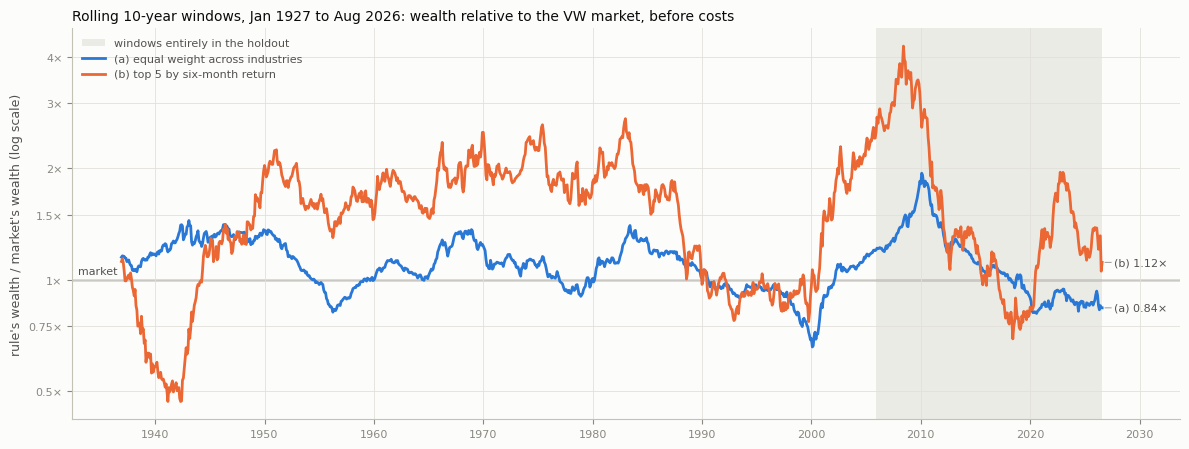

In [48]:
BONUS_COLORS = {"a": "#2a78d6", "b": "#eb6834"}  # categorical slots 1 and 2 (validated in Step 9)
fig, ax = plt.subplots(figsize=(12, 4.6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
first_holdout_end = (HOLDOUT_START + 119).to_timestamp()
ax.axvspan(first_holdout_end, LAST.to_timestamp(), color=GRID, alpha=0.6, linewidth=0, zorder=0,
           label="windows entirely in the holdout")
ax.axhline(1.0, color=INK_2, linewidth=1, zorder=1)
ends = []
for r in RULES:
    part = bonus_eval[r][bonus_eval[r]["kind"] == "rolling120"]
    ratio = (1 + part["mean"].to_numpy()) / (1 + part["market"].to_numpy())
    x = pd.PeriodIndex(part["end"], freq="M").to_timestamp()
    ax.plot(x, ratio, color=BONUS_COLORS[r], linewidth=2, zorder=3, label=RULES[r])
    ends.append((x[-1], ratio[-1], f"({r}) {ratio[-1]:.2f}×"))
for (x, y, text), label_y in zip(ends, spread_log([e[1] for e in ends], 0.05)):
    ax.annotate(text, xy=(x, y), xytext=(x + pd.Timedelta(days=400), label_y), fontsize=8, color=INK_2, va="center",
                arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.6, shrinkA=0, shrinkB=2))
ax.annotate("market", xy=(ax.get_xlim()[0], 1.0), xytext=(4, 4), textcoords="offset points", fontsize=8, color=INK_2)
ax.set_yscale("log")
ax.set_yticks([0.5, 0.75, 1, 1.5, 2, 3, 4])
ax.yaxis.set_minor_locator(plt.NullLocator())
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}×"))
ax.set_ylabel("rule's wealth / market's wealth (log scale)", color=INK_2, fontsize=9)
ax.set_title("Rolling 10-year windows, Jan 1927 to Aug 2026: wealth relative to the VW market, before costs",
             fontsize=10, color=INK, loc="left")
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlim(right=LAST.to_timestamp() + pd.Timedelta(days=2600))
ax.grid(True, color=GRID, linewidth=0.6)
ax.tick_params(colors=MUTED, labelsize=8)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(BASE)
ax.legend(loc="upper left", frameon=False, fontsize=8, labelcolor=INK_2)
fig.tight_layout()
fig.savefig(OUTPUT / "fig_bonus_rolling.png", dpi=150, facecolor=SURFACE)
plt.show()

#### Step 11 findings

Generated from the results above.

In [49]:
scr = screen.set_index("measure")
perf11 = bonus_performance.set_index(["period", "strategy"])
FULL, PRE, HOLD, POST2016 = PERIODS


def rate(measure, r):
    row = scr.loc[measure]
    return f"{int(row[f'{r}: wins'])} of {int(row['windows']):,} ({pct(row[f'{r}: win rate'])})"


def losses(r):
    lost = bonus_decades[~bonus_decades[f"({r}) beats market"]]
    return and_join(f"{d} ({pct(a)} against {pct(m)})" for d, a, m in zip(lost["decade"], lost[f"({r})"], lost["VW market"])) or "none"


def closest_win(r):
    won = bonus_decades[bonus_decades[f"({r}) beats market"]]
    ratio = (1 + won[f"({r})"]) / (1 + won["VW market"])
    k = int(np.argmin(ratio.to_numpy()))
    return f"{won['decade'].iloc[k]} ({pct(won[f'({r})'].iloc[k])} against {pct(won['VW market'].iloc[k])})"


def post2016_text(r):
    rule = perf11.loc[(POST2016, RULES[r])]
    market_w = perf11.loc[(POST2016, "VW market"), "terminal wealth"]
    relation = "above" if rule["terminal wealth"] > market_w else "below"
    market_sharpe = perf11.loc[(POST2016, "VW market"), "Sharpe ratio"]
    return (f"{rule['terminal wealth']:.2f}× ({relation} the market's {market_w:.2f}×; Sharpe ratio "
            f"{rule['Sharpe ratio']:.2f} against {market_sharpe:.2f})")


def perf_line(r, period=FULL):
    row = perf11.loc[(period, RULES[r])]
    return (f"{pct(row['annualized return'], 2)} a year, volatility {pct(row['annualized volatility'])}, Sharpe ratio "
            f"{row['Sharpe ratio']:.2f}, maximum drawdown {signed(100 * row['max drawdown'], 1)}%, turnover "
            f"{row['annual turnover']:.0%} a year")


market_full = perf11.loc[(FULL, "VW market")]
offset_range = {r: (offsets[f"{r}: win rate"].min(), offsets[f"{r}: win rate"].max()) for r in RULES}
rolling_ratio = {}
for r in RULES:
    part = bonus_eval[r][bonus_eval[r]["kind"] == "rolling120"]
    rolling_ratio[r] = np.median((1 + part["mean"]) / (1 + part["market"]))
def recent_streak(r):
    # The most recent rolling window this rule won, and how many windows it has lost since.
    part = bonus_eval[r][bonus_eval[r]["kind"] == "rolling120"].sort_values("end")
    won = part["pct_above_vw"].to_numpy() == 1
    if won[-1]:
        run = len(won) - (np.flatnonzero(~won)[-1] + 1 if (~won).any() else 0)
        return f"has won the last {run} rolling windows, through the one ending {month_name(part['end'].iloc[-1])}"
    last_win = np.flatnonzero(won)[-1] if won.any() else None
    lost = len(won) - (last_win + 1 if last_win is not None else 0)
    since = f"since the window ending {month_name(part['end'].iloc[last_win])}" if last_win is not None else "throughout"
    return f"has lost all {lost} rolling windows {since}"


losing_now = [r for r in RULES if bonus_eval[r].query("kind == 'rolling120'").sort_values("end")["pct_above_vw"].iloc[-1] == 0]
recent_note = (f"So {and_join(f'rule ({r})' for r in losing_now)}'s holdout win rate comes from windows ending before its "
               "current losing streak" if losing_now else "Both rules won the most recent rolling window")
both = all(passes.values())
verdict = ("Both rules pass" if both else
           "Neither rule passes" if not any(passes.values()) else
           f"Only {and_join(RULES[r] for r in RULES if passes[r])} passes")

display(Markdown(rf'''
- **Checks.** Rule (a) realizes the exact mean of random FF49 VW selection in every window (largest relative gap {gap_a:.0e}). Rule (b) holds five eligible industries with returns in every month. Both rules start in {BONUS_START} with signals built from July 1926, and Rubbr is rankable on six months again from {rubbr6}.
- **Historical screen.** {verdict} the screen. On the paper's decades to 2016, (a) beats the market in {rate('Paper decades to 2016 (screen)', 'a')} and (b) in {rate('Paper decades to 2016 (screen)', 'b')}. On the 249 rolling 10-year windows entirely within the holdout, (a) wins {rate('Holdout rolling 10-year windows (screen)', 'a')} and (b) {rate('Holdout rolling 10-year windows (screen)', 'b')}.
- **Before 1996 and in the holdout, separately.** Before 1996, (a) wins {rate('Pre-1996: paper decades ending by Dec 1986', 'a')} of the paper's decades ending by 1986 and {rate('Pre-1996: rolling windows ending by Dec 1995', 'a')} of rolling windows; (b) wins {rate('Pre-1996: paper decades ending by Dec 1986', 'b')} and {rate('Pre-1996: rolling windows ending by Dec 1995', 'b')}. In the holdout decades 1996–2005, 2006–2015 and 2016–2025, (a) wins {rate('Holdout decades 1996-2005, 2006-2015, 2016-2025', 'a')} and (b) {rate('Holdout decades 1996-2005, 2006-2015, 2016-2025', 'b')}.
- **Where they lose, and the closest wins.** (a) loses to the market in {losses('a')}; its narrowest decade win is {closest_win('a')}. (b) loses in {losses('b')}; its narrowest win is {closest_win('b')}.
- **Window placement.** Across the 10 yearly placements of non-overlapping decades, (a)'s win rate ranges from {pct(offset_range['a'][0], 0)} to {pct(offset_range['a'][1], 0)} and (b)'s from {pct(offset_range['b'][0], 0)} to {pct(offset_range['b'][1], 0)}. Over all {len(rolling27):,} rolling windows, the median ratio of rule wealth to market wealth is {rolling_ratio['a']:.2f} for (a) and {rolling_ratio['b']:.2f} for (b).
- **Performance, January 1927 to August 2026 (before costs).** (a): {perf_line('a')}. (b): {perf_line('b')}. VW market: {pct(market_full['annualized return'], 2)} a year, volatility {pct(market_full['annualized volatility'])}, Sharpe ratio {market_full['Sharpe ratio']:.2f}, maximum drawdown {signed(100 * market_full['max drawdown'], 1)}%.
- **Recent windows.** Rule (a) {recent_streak('a')}; rule (b) {recent_streak('b')}. {recent_note} (see the figure).
- **Post-2016 evaluation (January 2017 to August 2026, 116 months).** A dollar grew to {post2016_text('a')} with (a) and {post2016_text('b')} with (b). This period is shorter than 10 years and has no complete 10-year window. Its returns also enter the screen and candidate comparison, so it is not an independent test of the selected rule.
- **What this answers.** {verdict} the descriptive historical screen. So, on this revised history and before costs, each passing rule reached a historical win rate of at least 50% on each of the two screened sets of 10-year windows. That is a historical frequency on overlapping windows and a single history. It is not an established probability of at least 50% for a future decade, and the holdout is a retrospective validation, not an unseen test. Rule (b) trades far more than rule (a), and no trading costs, stock-level turnover or taxes are measured here. Whether either advantage survives costs is not established.
'''))


- **Checks.** Rule (a) realizes the exact mean of random FF49 VW selection in every window (largest relative gap 9e-15). Rule (b) holds five eligible industries with returns in every month. Both rules start in 1927-01 with signals built from July 1926, and Rubbr is rankable on six months again from 1945-01.
- **Historical screen.** Both rules pass the screen. On the paper's decades to 2016, (a) beats the market in 7 of 9 (77.8%) and (b) in 8 of 9 (88.9%). On the 249 rolling 10-year windows entirely within the holdout, (a) wins 154 of 249 (61.8%) and (b) 206 of 249 (82.7%).
- **Before 1996 and in the holdout, separately.** Before 1996, (a) wins 5 of 6 (83.3%) of the paper's decades ending by 1986 and 549 of 709 (77.4%) of rolling windows; (b) wins 6 of 6 (100.0%) and 569 of 709 (80.3%). In the holdout decades 1996–2005, 2006–2015 and 2016–2025, (a) wins 2 of 3 (66.7%) and (b) 3 of 3 (100.0%).
- **Where they lose, and the closest wins.** (a) loses to the market in Jan 1947 to Dec 1956 (295.3% against 363.8%), Jan 1987 to Dec 1996 (277.9% against 295.7%) and Jan 2016 to Dec 2025 (247.7% against 294.7%); its narrowest decade win is Jan 1967 to Dec 1976 (84.6% against 81.9%). (b) loses in Jan 1987 to Dec 1996 (273.7% against 295.7%); its narrowest win is Jan 2006 to Dec 2015 (108.6% against 106.6%).
- **Window placement.** Across the 10 yearly placements of non-overlapping decades, (a)'s win rate ranges from 67% to 78% and (b)'s from 67% to 89%. Over all 1,077 rolling windows, the median ratio of rule wealth to market wealth is 1.10 for (a) and 1.59 for (b).
- **Performance, January 1927 to August 2026 (before costs).** (a): 11.09% a year, volatility 20.3%, Sharpe ratio 0.46, maximum drawdown −85.3%, turnover 20% a year. (b): 14.40% a year, volatility 22.0%, Sharpe ratio 0.58, maximum drawdown −82.6%, turnover 455% a year. VW market: 10.33% a year, volatility 18.4%, Sharpe ratio 0.45, maximum drawdown −83.7%.
- **Recent windows.** Rule (a) has lost all 89 rolling windows since the window ending Mar 2019; rule (b) has won the last 74 rolling windows, through the one ending Aug 2026. So rule (a)'s holdout win rate comes from windows ending before its current losing streak (see the figure).
- **Post-2016 evaluation (January 2017 to August 2026, 116 months).** A dollar grew to 3.32× (below the market's 3.92×; Sharpe ratio 0.68 against 0.81) with (a) and 4.61× (above the market's 3.92×; Sharpe ratio 0.72 against 0.81) with (b). This period is shorter than 10 years and has no complete 10-year window. Its returns also enter the screen and candidate comparison, so it is not an independent test of the selected rule.
- **What this answers.** Both rules pass the descriptive historical screen. So, on this revised history and before costs, each passing rule reached a historical win rate of at least 50% on each of the two screened sets of 10-year windows. That is a historical frequency on overlapping windows and a single history. It is not an established probability of at least 50% for a future decade, and the holdout is a retrospective validation, not an unseen test. Rule (b) trades far more than rule (a), and no trading costs, stock-level turnover or taxes are measured here. Whether either advantage survives costs is not established.


## Conclusions

The answers to the assignment, generated from the results above. Details, tables and caveats are in the sections above; the concise submission is [report/report.pdf](report/report.pdf).

In [50]:
# Part 1 values come from the Step 3, 5 and 6 cells; Part 2 values from the Step 9, 10 and 11 findings cells.
# Part 1's `low`/`high` were reused by Step 10's figure, so the volatilities are read from Part 1's table rows.
def s_range(sigmas):
    return f"{min(sigmas):.0%} to {max(sigmas):.0%}"


RULE_TEXT = {"a": "hold every formation-eligible FF49 industry with equal weight, value-weighted within industries, "
                  "rebalanced monthly",
             "b": "hold the five FF49 industries with the highest return over the previous six months, equally "
                  "weighted and value-weighted within industries, rebalanced monthly"}
ff49_ew = full10.set_index("variant").loc["FF49 EW"]
mom_ew = performance.set_index("strategy").loc["Momentum, FF49 EW"]
mom_pct = percentiles[EW49].query("kind == 'full'").iloc[0]

# Retrospective bonus selection: compare these candidates on the same historical measures and decade placements.
at_least = {r: all((screen[f"{r}: win rate"] >= screen[f"{o}: win rate"]).tolist()
                   + (offsets[f"{r}: win rate"] >= offsets[f"{o}: win rate"]).tolist())
            for r, o in (("a", "b"), ("b", "a"))}
chosen = [r for r in RULES if passes[r] and at_least[r]]
if len(chosen) != 1:
    raise ValueError("the recommendation below assumes exactly one passing rule dominates the other")
best, other = chosen[0], "a" if chosen[0] == "b" else "b"
row = screen.set_index("measure")


def wins(r, measure):
    return f"{int(row.loc[measure, f'{r}: wins'])} of {int(row.loc[measure, 'windows']):,}"


display(Markdown(rf'''
**Part 1, Table 1 with normal returns.**
- *Daily draws (Task 1.1).* At the assigned mean of 0.0025% a day, the median buy-and-hold return is negative for {crossing_text(median_cross)}, and fewer than half of outcomes are positive for {crossing_text(positive_cross)}. What drives this is the mean, about a tenth of the paper's 0.5% a month, not daily compounding: at a daily mean matched to 0.5% a month the daily table is close to the paper's.
- *15 and 20 years (Task 1.2).* With the paper's monthly parameters, the median rises with horizon for monthly volatility from {s_range(rising)} and falls for volatility from {s_range(falling)}. The population expected return is the same at every volatility.
- *Low-volatility puzzle.* At the same expected 10-year return ({low10['population expected return']:.1%}), the median 10-year return is {low10['median']:.1%} at {low10['monthly sigma']:.0%} monthly volatility and {signed(100 * high10['median'], 1)}% at {high10['monthly sigma']:.0%}. Compounding explains why volatile assets have worse typical long-horizon outcomes at equal expected returns. It does not explain the anomaly itself, which concerns average returns and alphas.

**Part 2, Table 4 with industries (July 1926 to December 2016 unless stated; before costs).**
- *Random industry (Task 2.1).* A random FF49 industry with equal-weighted stocks beats the VW market in {by_horizon(EW49)} of outcomes at the 1-year, 10-year and full-period horizons. {"That is more often than any of the paper's bootstrapped stock portfolios." if ew_above_all else "That is not above every paper row."} With value-weighted stocks, its market-beating shares ({by_horizon(VW49)}) lie within the paper's 25- to 100-stock range {inside_text}.
- *Three-month momentum (Task 2.2).* FF49 EW momentum grew \$1 to {ff49_ew['momentum']:,.0f}× from October 1926, against {ff49_ew['VW market']:,.0f}× for the market. That was below the {ff49_ew['random mean (exact)']:,.0f}× expected from a random industry, at the {pct(mom_pct['percentile'])} percentile of the random paths. It had a maximum drawdown of {signed(100 * mom_ew['max drawdown'], 1)}% and a Sharpe ratio of {mom_ew['Sharpe ratio']:.2f}, against the market's {perf.loc['VW market', 'Sharpe ratio']:.2f}.
- *Bonus (Task 2.3).* Suggested strategy: **{RULES[best]}**: {RULE_TEXT[best]}.
  - It beat the VW market in {wins(best, 'Paper decades to 2016 (screen)')} of the paper's decades and {wins(best, 'Holdout rolling 10-year windows (screen)')} rolling 10-year windows after 1995. That passes the descriptive historical screen, and its win rate is at least rule ({other})'s on every measure and decade placement.
  - Rule ({other}) {'also passes' if passes[other] else 'does not pass'}, but it {recent_streak(other)}.
  - These are historical frequencies on overlapping windows of one revised history, before costs: {row.loc['All rolling 10-year windows', f'{best}: win rate']:.1%} of all rolling 10-year windows since 1927. The same history was used to compare these candidates, so this is not independent validation or an established probability of at least 50% for a future decade. The rule turns over about {perf11.loc[(FULL, RULES[best]), 'annual turnover']:.0%} a year across industry portfolios, and whether its advantage survives trading costs is not measured here.
'''))


**Part 1, Table 1 with normal returns.**
- *Daily draws (Task 1.1).* At the assigned mean of 0.0025% a day, the median buy-and-hold return is negative for every daily $\sigma$ from 0.90% up, at all three horizons, and fewer than half of outcomes are positive for every daily $\sigma$ from 0.90% up, at all three horizons. What drives this is the mean, about a tenth of the paper's 0.5% a month, not daily compounding: at a daily mean matched to 0.5% a month the daily table is close to the paper's.
- *15 and 20 years (Task 1.2).* With the paper's monthly parameters, the median rises with horizon for monthly volatility from 2% to 8% and falls for volatility from 12% to 20%. The population expected return is the same at every volatility.
- *Low-volatility puzzle.* At the same expected 10-year return (81.9%), the median 10-year return is 65.5% at 4% monthly volatility and −62.0% at 16%. Compounding explains why volatile assets have worse typical long-horizon outcomes at equal expected returns. It does not explain the anomaly itself, which concerns average returns and alphas.

**Part 2, Table 4 with industries (July 1926 to December 2016 unless stated; before costs).**
- *Random industry (Task 2.1).* A random FF49 industry with equal-weighted stocks beats the VW market in 51.7%, 59.5% and 81.2% of outcomes at the 1-year, 10-year and full-period horizons. That is more often than any of the paper's bootstrapped stock portfolios. With value-weighted stocks, its market-beating shares (49.0%, 46.4% and 39.2%) lie within the paper's 25- to 100-stock range at all three horizons.
- *Three-month momentum (Task 2.2).* FF49 EW momentum grew \$1 to 33,320× from October 1926, against 4,715× for the market. That was below the 69,258× expected from a random industry, at the 63.2% percentile of the random paths. It had a maximum drawdown of −99.7% and a Sharpe ratio of 0.40, against the market's 0.42.
- *Bonus (Task 2.3).* Suggested strategy: **(b) top 5 by six-month return**: hold the five FF49 industries with the highest return over the previous six months, equally weighted and value-weighted within industries, rebalanced monthly.
  - It beat the VW market in 8 of 9 of the paper's decades and 206 of 249 rolling 10-year windows after 1995. That passes the descriptive historical screen, and its win rate is at least rule (a)'s on every measure and decade placement.
  - Rule (a) also passes, but it has lost all 89 rolling windows since the window ending Mar 2019.
  - These are historical frequencies on overlapping windows of one revised history, before costs: 78.5% of all rolling 10-year windows since 1927. The same history was used to compare these candidates, so this is not independent validation or an established probability of at least 50% for a future decade. The rule turns over about 455% a year across industry portfolios, and whether its advantage survives trading costs is not measured here.
